In [1]:
1+8


9

### Description

March 27, 2025

I will use this notebook to make plots that will be used for making my request to access the near sideband.

Plan:

With MC, apply all cuts EXCEPT cuts I flip for s.b. and track length cut. Show that with this choice of near s.b., signal in sideband is small, even when scaled to best model benchmark. Include the CV weights and the uncertainties on signal and background MC.


Need: 

CV weights and uncertainties on both signal and bg MC. I have so many samples now, so for this exercise I should strategically choose a subset of the samples to do the study on (less processing time to get full uncertainties).

Note: I have already processed these for the nu background, and they are stored at /exp/icarus/data/users/jdyer/muon_datamc/samples_240909/allMC_ie_no_restriction_to_sideband_wConcreteFix_240909/

- the mc_coh file was made from just one of the cohlike samples (cohlike_nu_file = gray_df_dir + "F-CohLike_nom_evt.df").
- the mc_incoh never explicitly had the cohlike events masked out of it by me. But that was taken care of within the make_dataset() function. 

Here, I need to also process the CV weights and uncertainties for some signal benchmarks.



In [2]:
import uproot
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np 
import matplotlib as mpl
import pickle
import h5py
import math
import re
from IPython.display import display
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from scipy.integrate import quad
from scipy.stats import poisson,norm, chi2 
from scipy.optimize import brentq


from util import *
import var
import cut
import data
import hist

import importlib

import pid
from pyanalib import panda_helpers
import os
import multiprocessing

from unc_funcs import *
from unc_samples import *
#from unc_MCdata_overhead import *
from unc_cuts import *
from alp_flux_weights import *


#import warnings
#warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

#import subprocess

## Samples I'll use here (subset of all the samples)
(This content would normally be in unc_MCdata_overhead.py, but since I'm doing just a subset of the samples for this exercise, I'm going to contain it to this notebook.)

- Nominal nu sample: nu_file
- Cohlike nus: cohlike_nu_file
- Cohlike detector variations: cohlike_nu_detVar_files

In [3]:
onbeamR1_pot = 4.651603646822754e+19
print('onbeamR1_pot: ', onbeamR1_pot)
onbeamR1_livetime = 9712335.74

onbeamR2_pot = 1.9447555727369336e+20
print('onbeamR2_pot: ', onbeamR2_pot)
onbeamR2_livetime = 40955958.70833331

onbeam_pot = onbeamR1_pot + onbeamR2_pot
print('Combined onbeam POT: ', onbeam_pot)
GOAL_POT = onbeam_pot

print(GOAL_POT)

onbeamR1_pot:  4.651603646822754e+19
onbeamR2_pot:  1.9447555727369336e+20
Combined onbeam POT:  2.409915937419209e+20
2.409915937419209e+20


In [4]:
savedir = '/exp/icarus/data/users/jdyer/muon_CVwgts_y_systs_2503/'
savedir = '/exp/icarus/data/users/jdyer/muon_CVwgts_y_systs_2510/' # These have corrected CV weights for the flux updates I included over the summer.
savedir = '/exp/icarus/data/users/jdyer/muon_CVwgts_y_systs_2511/' # The systematics included in these are calculated with the work that is described in slides titled 211114_asymmetricFluxUnc.pptx
savedir = '/exp/icarus/data/users/jdyer/muon_CVwgts_y_systs_2512/' # same as above, but referring to parent particle pdg for the flux weights for the bsm samples, and including the alp flux cv reweights.



## Stuff to Run Once:

In [15]:
filedir = savedir
mc_incoh_evt = pd.read_hdf(filedir + "mc_incoh", "evt")
mccoh_evt = pd.read_hdf(filedir + "mc_coh", "evt")

print('All cohlike: ', mccoh_evt.shape)
#print('Cohlike from cohlike: ', evt_test2.df.shape)
print('Cohlike_JD from cohlike: ', mccoh_evt[is_coh_like_JD(mccoh_evt)].shape)
print('Not-Cohlike_JD from Cohlike: ', mccoh_evt[~is_coh_like_JD(mccoh_evt)].shape)
print('')
print('All Not-cohlike: ', mc_incoh_evt.shape)
print('Cohlike from Not-cohlike: ', mc_incoh_evt[is_coh_like_JD(mc_incoh_evt)].shape)
print('Not-Cohlike_JD from All Not-cohlike: ', mc_incoh_evt[~is_coh_like_JD(mc_incoh_evt)].shape)
print('')

#print(evt_test2.df.shape[0] + evt_test3.df.shape[0])
#print('')
#print(evt_test1.df[~is_coh_like_JD(evt_test1.df)].shape[0] + evt_test1.df[is_coh_like_JD(evt_test1.df)].shape[0])

All cohlike:  (103855, 788)
Cohlike_JD from cohlike:  (103855, 788)
Not-Cohlike_JD from Cohlike:  (0, 788)

All Not-cohlike:  (220197, 788)
Cohlike from Not-cohlike:  (0, 788)
Not-Cohlike_JD from All Not-cohlike:  (220197, 788)



In [ ]:
# end of study.

In [5]:
nmu = var.DF.iscc & ((var.DF.pdg == 14) | (var.DF.pdg == -14))
npi = var.DF.npi
ns = var.DF.nsm + var.DF.nsp
is_coh_like = (nmu + npi + ns >= 2) & (var.DF.max_proton_ke < 0.05)

def resave_datasets(df_names, df_list, output):
    with pd.HDFStore(output) as hdf:
        for k,df in zip(df_names, df_list):
            try:
                hdf.put(key=k, value=df, format="fixed")
            except Exception as e:
                print("Table %s failed to save, skipping. Exception: %s" % (k, str(e)))
                
                

In [6]:
# 4/3/25: make a function to do this so I don't have to copy/paste this block for every sample.

def JD_make_cvDF_w_cvWgt_and_systs(file, label, savedir=savedir, mccut=None,
                                   mc=True, mc_incoh=False, mccoh=False,
                                   bsm=False, hps=False, alp=False,
                                   onbeam=False, offbeam=False, Run1=False, Run2=False,
                                  ):
    print('file: ', file)
    if mc:
        evt = data.mc_dataset(file, "evt", mcnukey="mcnuwgt", isscalar=bsm, alp=alp)#, mccut=mccut)
        evt_df = evt.df
        if mccut is not None:
                print('recognized mccut')
                print('shape of evt_df before applying mccut: ', evt_df.shape)
                evt_df = evt_df[mccut(evt_df)]
                print('shape of evt_df after applying mccut: ', evt_df.shape)
        evt_df["mc"] = mc
        evt_df["mc_incoh"] = mc_incoh
        evt_df["mccoh"] = mccoh
        evt_df["bsm"] = bsm
        ## WIP (and may not follow through)
        #if hps=True:
        #    mchdf = pd.read_hdf(file, key="mch")
        #    evt_df["mass"] = int(round(mchdf.iloc[(0)].M*1000.))
        #    evt_df["theta"] = float(mchdf.iloc[(0)].C1)
        #    evt_df["sample"] = "$M_S$ = %a, $\\theta_S$ = %a" % (int(round(mchdf.iloc[(0)].M*1000.)), float(mchdf.iloc[(0)].C1))
        #else:
        #    evt_df["mass"] = -1
        #    evt_df["theta"] = -1
        #    evt_df["sample"] = 'na'
        evt_df["hps"] = hps
        evt_df["alp"] = alp
        evt_df["onbeam"] = evt_df["offbeam"] = evt_df["Run1"] = evt_df["Run2"] = False
    evt_df['livetime'] = evt.livetime
    evt_df['POT'] = evt.POT
    #print('livetime: ', evt.livetime)
    #print('POT: ', evt.POT)
    evt_df = evt_df[satisfies_new_FV(evt_df)] # Make sure FV definition is up to date (so that we don't accept any too-short non-fiducial events)
    when_uncontained = ~TrkInFV(evt_df.trunk.trk.end) | ~TrkInFV(evt_df.branch.trk.end) # Require exiting
    evt_df = evt_df[when_uncontained]
    evt_df = add_calculated_evtdf_cols(evt_df)#, newcol_name=None, newcol_val=None)
    # resave dataset with lightened evt dataframe:
    df_names = ['evt', 'hdr', 'mch', 'mcnu']
    resave_datasets(df_names, 
                    [evt_df,
                     pd.read_hdf(file, "hdr"),
                     pd.read_hdf(file, "mch"),
                     pd.read_hdf(file, "mcnu")
                    ], 
                    savedir+label
                   )
    del evt
    del evt_df


In [29]:
#mcdf = pd.read_hdf(nu_file, key="mcnuwgt")


In [7]:
print(savedir)
# Nus:
JD_make_cvDF_w_cvWgt_and_systs(nu_file, 'mc_incoh', mc=True, mccut=is_NOT_coh_like_JD, mc_incoh=True)
JD_make_cvDF_w_cvWgt_and_systs(cohlike_1, 'mc_coh_1', mc=True, mccut=is_coh_like_JD, mccoh=True)
JD_make_cvDF_w_cvWgt_and_systs(cohlike_2, 'mc_coh_2', mc=True, mccut=is_coh_like_JD, mccoh=True)

/exp/icarus/data/users/jdyer/muon_CVwgts_y_systs_2512/
file:  /exp/icarus/data/users/jdyer/dimuon-data/2507_remake/nomNus.df


/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:55: PerformanceWarning: indexing past lexsort depth may impact performance.
  cv = math.prod([mcdf[w] for w in weights.cv])
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:32: PerformanceWarning: indexing past lexsort depth may impact performance.
  return multicol_merge(df, 

Generating Coh-weights!


/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)


Generated
GENIEReWeight_ICARUS_v2_multisigma_VecFFCCQEshape
GENIEReWeight_ICARUS_v2_multisigma_RPA_CCQE
GENIEReWeight_ICARUS_v2_multisigma_CoulombCCQE
GENIEReWeight_ICARUS_v2_multisim_ZExpAVariationResponse
GENIEReWeight_ICARUS_v2_multisigma_NormCCMEC
GENIEReWeight_ICARUS_v2_multisigma_NormNCMEC
GENIEReWeight_ICARUS_v2_multisigma_DecayAngMEC
GENIEReWeight_ICARUS_v2_multisim_CCRESVariationResponse
GENIEReWeight_ICARUS_v2_multisim_NCRESVariationResponse
GENIEReWeight_ICARUS_v2_multisigma_RDecBR1gamma
GENIEReWeight_ICARUS_v2_multisigma_RDecBR1eta
GENIEReWeight_ICARUS_v2_multisigma_Theta_Delta2Npi
GENIEReWeight_ICARUS_v2_multisigma_ThetaDelta2NRad
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpCC1pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpCC2pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpNC1pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpNC2pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvnCC1pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvnCC2pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESB

...

/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:32: PerformanceWarning: indexing past lexsort depth may impact performance.
  return multicol_merge(df, wgtdf, how="left", left_on=wgtdf.index.names[:2] + [tmatch_col], right_index=True).fillna(na_set)


reinteractions_piminus_Geant4
reinteractions_piplus_Geant4
reinteractions_proton_Geant4


/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:32: PerformanceWarning: indexing past lexsort depth may impact performance.
  return multicol_merge(df, wgtdf, how="left", left_on=wgtdf.index.names[:2] + [tmatch_col], right_index=True).fillna(na_set)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:164: PerformanceWarning: D

recognized mccut
shape of evt_df before applying mccut:  (131189, 798)
shape of evt_df after applying mccut:  (98471, 798)


/tmp/ipykernel_3899887/1637923528.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  evt_df["mc"] = mc
/tmp/ipykernel_3899887/1637923528.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  evt_df["mc_incoh"] = mc_incoh
/tmp/ipykernel_3899887/1637923528.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexi

In [9]:
# CV signal samples: (fast cell)

# Nus:
JD_make_cvDF_w_cvWgt_and_systs(nu_file, 'mc_incoh', mc=True, mccut=is_NOT_coh_like_JD, mc_incoh=True)
JD_make_cvDF_w_cvWgt_and_systs(cohlike_1, 'mc_coh_1', mc=True, mccut=is_coh_like_JD, mccoh=True)
JD_make_cvDF_w_cvWgt_and_systs(cohlike_2, 'mc_coh_2', mc=True, mccut=is_coh_like_JD, mccoh=True)

# HPS:
#JD_make_cvDF_w_cvWgt_and_systs(gray_df_dir + "F2-Higgs_M220_nom_evt.df", 'mS_220', mc=True, bsm=True, hps=True)
#JD_make_cvDF_w_cvWgt_and_systs(gray_df_dir + "F2-Higgs_M260_nom_evt.df", 'mS_260', mc=True, bsm=True, hps=True)
#JD_make_cvDF_w_cvWgt_and_systs(gray_df_dir + "F2-Higgs_M300_nom_evt.df", 'mS_300', mc=True, bsm=True, hps=True)
#JD_make_cvDF_w_cvWgt_and_systs(gray_df_dir + "F2-Higgs_M340_nom_evt.df", 'mS_340', mc=True, bsm=True, hps=True)

JD_make_cvDF_w_cvWgt_and_systs(higgs_files[0], 'mS_220', mc=True, bsm=True, hps=True)
JD_make_cvDF_w_cvWgt_and_systs(higgs_files[1], 'mS_240', mc=True, bsm=True, hps=True)
JD_make_cvDF_w_cvWgt_and_systs(higgs_files[2], 'mS_260', mc=True, bsm=True, hps=True)
JD_make_cvDF_w_cvWgt_and_systs(higgs_files[3], 'mS_280', mc=True, bsm=True, hps=True)
JD_make_cvDF_w_cvWgt_and_systs(higgs_files[4], 'mS_300', mc=True, bsm=True, hps=True)
JD_make_cvDF_w_cvWgt_and_systs(higgs_files[5], 'mS_320', mc=True, bsm=True, hps=True)
JD_make_cvDF_w_cvWgt_and_systs(higgs_files[6], 'mS_340', mc=True, bsm=True, hps=True)

# ALPs:
#JD_make_cvDF_w_cvWgt_and_systs("/exp/icarus/data/users/jdyer/dimuon-data/2411_moreAlps/histats/ma300_faE6.df", 'ma_300', mc=True, bsm=True, alp=True)
#JD_make_cvDF_w_cvWgt_and_systs("/exp/icarus/data/users/jdyer/dimuon-data/2411_moreAlps/histats/ma350_faE6.df", 'ma_350', mc=True, bsm=True, alp=True)
#JD_make_cvDF_w_cvWgt_and_systs("/exp/icarus/data/users/jdyer/dimuon-data/2411_moreAlps/histats/ma400_faE6.df", 'ma_400', mc=True, bsm=True, alp=True)
#JD_make_cvDF_w_cvWgt_and_systs("/exp/icarus/data/users/jdyer/dimuon-data/2411_moreAlps/histats/ma450_faE6.df", 'ma_450', mc=True, bsm=True, alp=True)

JD_make_cvDF_w_cvWgt_and_systs(alp_nosup_files[0], 'ma_300', mc=True, bsm=True, alp=True)
JD_make_cvDF_w_cvWgt_and_systs(alp_nosup_files[1], 'ma_350', mc=True, bsm=True, alp=True)
JD_make_cvDF_w_cvWgt_and_systs(alp_nosup_files[2], 'ma_400', mc=True, bsm=True, alp=True)
JD_make_cvDF_w_cvWgt_and_systs(alp_nosup_files[3], 'ma_450', mc=True, bsm=True, alp=True)
JD_make_cvDF_w_cvWgt_and_systs(alp_nosup_files[4], 'ma_500', mc=True, bsm=True, alp=True)
JD_make_cvDF_w_cvWgt_and_systs(alp_nosup_files[5], 'ma_540', mc=True, bsm=True, alp=True)
JD_make_cvDF_w_cvWgt_and_systs(alp_nosup_files[6], 'ma_600', mc=True, bsm=True, alp=True)
JD_make_cvDF_w_cvWgt_and_systs(alp_nosup_files[7], 'ma_650', mc=True, bsm=True, alp=True)
JD_make_cvDF_w_cvWgt_and_systs(alp_nosup_files[8], 'ma_700', mc=True, bsm=True, alp=True)



file:  /exp/icarus/data/users/jdyer/dimuon-data/2507_remake/nomNus.df


/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:55: PerformanceWarning: indexing past lexsort depth may impact performance.
  cv = math.prod([mcdf[w] for w in weights.cv])
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:32: PerformanceWarning: indexing past lexsort depth may impact performance.
  return multicol_merge(df, 

Generating Coh-weights!


/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)


Generated
GENIEReWeight_ICARUS_v2_multisigma_VecFFCCQEshape
GENIEReWeight_ICARUS_v2_multisigma_RPA_CCQE
GENIEReWeight_ICARUS_v2_multisigma_CoulombCCQE
GENIEReWeight_ICARUS_v2_multisim_ZExpAVariationResponse
GENIEReWeight_ICARUS_v2_multisigma_NormCCMEC
GENIEReWeight_ICARUS_v2_multisigma_NormNCMEC
GENIEReWeight_ICARUS_v2_multisigma_DecayAngMEC
GENIEReWeight_ICARUS_v2_multisim_CCRESVariationResponse
GENIEReWeight_ICARUS_v2_multisim_NCRESVariationResponse
GENIEReWeight_ICARUS_v2_multisigma_RDecBR1gamma
GENIEReWeight_ICARUS_v2_multisigma_RDecBR1eta
GENIEReWeight_ICARUS_v2_multisigma_Theta_Delta2Npi
GENIEReWeight_ICARUS_v2_multisigma_ThetaDelta2NRad
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpCC1pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpCC2pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpNC1pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpNC2pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvnCC1pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvnCC2pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESB

...

Beam_shift_x
Beam_shift_y
Beam_spot
Horn1_x
Horn1_y
Horn2_x
Horn2_y
Horn_current
Horn_water
Target_z
pca0
pca1
pca2
pca3
pca4
pca5
pca6
pca7
pca8
pca9
pca10
pca11
pca12
pca13
pca14
pca15
pca16
pca17
pca18
pca19


/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:32: PerformanceWarning: indexing past lexsort depth may impact performance.
  return multicol_merge(df, wgtdf, how="left", left_on=wgtdf.index.names[:2] + [tmatch_col], right_index=True).fillna(na_set)


reinteractions_piminus_Geant4
Cant find systematic called 'reinteractions_piminus_Geant4' in df. Fix this!!
reinteractions_piplus_Geant4
Cant find systematic called 'reinteractions_piplus_Geant4' in df. Fix this!!
reinteractions_proton_Geant4
Cant find systematic called 'reinteractions_proton_Geant4' in df. Fix this!!


/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:32: PerformanceWarning: indexing past lexsort depth may impact performance.
  return multicol_merge(df, wgtdf, how="left", left_on=wgtdf.index.names[:2] + [tmatch_col], right_index=True).fillna(na_set)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:164: PerformanceWarning: D

/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/unc_funcs.py:636: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  ppdf = scalar_mom - scalar_mom.dot(BEAMDIR)[:,np.newaxis]*np.repeat([BEAMDIR], repeats=scalar_mom.shape[0], axis=0)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/env/lib64/python3.9/site-packages/tables/attributeset.py:459: NaturalNameWarning: object name is not a valid Python identifier: 'axis1_namerec.slc..index'; it does not match the pattern ``^[a-zA-Z_][a-zA-Z0-9_]*$``; you will not be able to use natural naming to access this object; using ``getattr()`` will still work, though
  check_attribute_name(name)
/tmp/ipykernel_3122547/2654351296.py:10: PerformanceWarning: 
your performance

In [18]:
def combine_two_df_of_same_sample(f1, f2, mccut=None):
    # Note 12/3/25: Due to their being two dfs per detector variation, since there were too many CAFs to run a single makedf command, 
    #               I need to make sure they don't have any redundant indices. I think that the way I am doing it here will ruin the 
    #               ability to track down the correct "ntuple" (i.e. CAF file) for events from evt_2, in case I need to investigate stuff
    #               upstream. If I end up needing to, I'll need to backwards-logic it out based on how I handle the indices here, and
    #               using the original list of caf files used to make the dataframe.
    x = data.mc_dataset(f1, "evt", mcnukey="mcnuwgt")
    evt_1 = x.df
    evt_1['livetime'] = x.livetime
    evt_1['POT'] = x.POT
    print(evt_1.POT.unique())
    
    y = data.mc_dataset(f2, "evt", mcnukey="mcnuwgt")
    evt_2 = y.df
    evt_2['livetime'] = y.livetime
    evt_2['POT'] = y.POT
    print(evt_2.POT.unique())
    
    hdr_1 = pd.read_hdf(f1, "hdr")
    mch_1 = pd.read_hdf(f1, "mch")
    mcnu_1 = pd.read_hdf(f1, "mcnu")
    df1list = [evt_1, hdr_1, mch_1, mcnu_1]
    
    hdr_2 = pd.read_hdf(f2, "hdr")
    mch_2 = pd.read_hdf(f2, "mch")
    mcnu_2 = pd.read_hdf(f2, "mcnu")
    
    level_to_modify = '__ntuple' # or 1 for integer position
    number_to_add = max([df.index.levels[0].max() for df in df1list]) # just in case the number differs across the dataframes.
    dfs = []
    for d, df2 in enumerate([evt_2, hdr_2, mch_2, mcnu_2]):
        modified_level_values = df2.index.get_level_values(level_to_modify).map(lambda x: str(int(x) + number_to_add))
        new_arrays = [] # Create a list of arrays for the new MultiIndex
        for i, name in enumerate(df2.index.names):
            if i == 0: 
                print(d, ', ', name)
            if name==level_to_modify:
                new_arrays.append(modified_level_values)
            else:
                new_arrays.append(df2.index.get_level_values(name))
        new_multi_index = pd.MultiIndex.from_arrays(new_arrays, names=df2.index.names)
        df2.index = new_multi_index # Assign the new MultiIndex to the DataFrame
                
        common_indices = df1list[d].index.intersection(df2.index)
        assert len(common_indices)==0
        combined_df = pd.concat([df1list[d], df2])
        if d==0:
            if mccut is not None:
                print('recognized mccut')
                print('shape of combined_df before applying mccut: ', combined_df.shape)
                combined_df = combined_df[mccut(combined_df)]
                print('shape of combined_df after applying mccut: ', combined_df.shape)
        dfs.append(combined_df)
    del x 
    del y
    return dfs 
        
        
    

In [40]:
#combined_dfs = combine_two_df_of_same_sample(cohlike_nu_detVar_files[0], cohlike_nu_detVar_files[1])
#test = combined_dfs[0]
#print(test.POT.unique())


[2.9708161e+21 1.8516344e+21]


In [19]:
# Detector Variation Samples:

def JD_make_dvDF_w_cvWgt_and_systs(detVar_files, label, savedir=savedir, mccut=None,
                                   mc=True, mc_incoh=False, mccoh=False, 
                                   bsm=False, hps=False, alp=False,
                                   onbeam=False, offbeam=False, Run1=False, Run2=False,
                                  ):
    label_counter = 0
    for i, file in enumerate(detVar_files):
        if (mccoh) & (i%2 != 0): 
            continue
        print(file, detVar_labels[label_counter], sep=' ')
        print(file)
        print(detVar_files[i+1])
        if mc:
            if bsm:
                evt = data.mc_dataset(file, "evt", mcnukey="mcnuwgt", isscalar=bsm, alp=alp)#, mccut=mccut)
                evt_df = evt.df
                evt_df['livetime'] = evt.livetime
                evt_df['POT'] = evt.POT #print('\n')
                hdr_df = pd.read_hdf(file, "hdr")
                mch_df = pd.read_hdf(file, "mch")
                mcnu_df = pd.read_hdf(file, "mcnu")
            if mccoh:
                all_types_dfs = combine_two_df_of_same_sample(file, detVar_files[i+1], mccut=mccut)
                evt_df = all_types_dfs[0]
                hdr_df = all_types_dfs[1]
                mch_df = all_types_dfs[2]
                mcnu_df = all_types_dfs[3]
                
            if mccut is not None:
                print('recognized mccut')
                print('shape of evt_df before applying mccut: ', evt_df.shape)
                evt_df = evt_df[mccut(evt_df)]
                print('shape of evt_df after applying mccut: ', evt_df.shape)
            evt_df["mc"] = mc
            evt_df["mc_incoh"] = mc_incoh
            evt_df["mccoh"] = mccoh
            evt_df["bsm"] = bsm
            evt_df["hps"] = hps
            evt_df["alp"] = alp
            evt_df["onbeam"] = evt_df["offbeam"] = evt_df["Run1"] = evt_df["Run2"] = False

        evt_df = evt_df[satisfies_new_FV(evt_df)] # Make sure FV definition is up to date (so that we don't accept any too-short non-fiducial events):
        when_uncontained = ~TrkInFV(evt_df.trunk.trk.end) | ~TrkInFV(evt_df.branch.trk.end)
        evt_df = evt_df[when_uncontained] # Require exiting
        evt_df = add_calculated_evtdf_cols(evt_df)
    
        # resave:
        output = savedir + label + '_' + detVar_labels[label_counter].replace(' ', '_')
        label_counter = label_counter + 1
        try: 
            subprocess.run(['rm', output])
        except:
            print("Did not delete a pre-existing file.")
        with pd.HDFStore(output) as hdf:
            # save the evt key to the dataset:
            try:
                hdf.put(key='evt', value=evt_df, format="fixed")
            except Exception as e:
                print("Table %s failed to save, skipping. Exception: %s" % ('evt', str(e)))
            # save the hdr key to the dataset:    
            try:
                hdf.put(key='hdr', value=hdr_df, format="fixed")
                hdf.put(key='mch', value=mch_df, format="fixed")
                hdf.put(key='mcnu', value=mcnu_df, format="fixed")
            except Exception as e:
                print("Table %s failed to save, skipping. Exception: %s" % ('hdr', str(e)))



In [12]:
for l in detVar_labels:
    print(l)
for f in cohlike_nu_detVar_files:
    print(f)

Middle Ind. Opacity
Noise 1.2x
Space Charge 2x
Ind0 Nom
/exp/icarus/data/users/jdyer/dimuon-data/2507_remake/cohlike_ind1bin0-1.df
/exp/icarus/data/users/jdyer/dimuon-data/2507_remake/cohlike_ind1bin0-2.df
/exp/icarus/data/users/jdyer/dimuon-data/2507_remake/cohlike_noiselhi-1.df
/exp/icarus/data/users/jdyer/dimuon-data/2507_remake/cohlike_noiselhi-2.df
/exp/icarus/data/users/jdyer/dimuon-data/2507_remake/cohlike_sce2x-1.df
/exp/icarus/data/users/jdyer/dimuon-data/2507_remake/cohlike_sce2x-2.df
/exp/icarus/data/users/jdyer/dimuon-data/2507_remake/cohlike_ind0nom-1.df
/exp/icarus/data/users/jdyer/dimuon-data/2507_remake/cohlike_ind0nom-2.df


In [20]:
%%time
# Nus:
JD_make_dvDF_w_cvWgt_and_systs(cohlike_nu_detVar_files, 'mc_coh', mccut=is_coh_like_JD, mccoh=True) # 


/exp/icarus/data/users/jdyer/dimuon-data/2507_remake/cohlike_ind1bin0-1.df Middle Ind. Opacity
/exp/icarus/data/users/jdyer/dimuon-data/2507_remake/cohlike_ind1bin0-1.df
/exp/icarus/data/users/jdyer/dimuon-data/2507_remake/cohlike_ind1bin0-2.df


/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:55: PerformanceWarning: indexing past lexsort depth may impact performance.
  cv = math.prod([mcdf[w] for w in weights.cv])
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:32: PerformanceWarning: indexing past lexsort depth may impact performance.
  return multicol_merge(df, 

Generating Coh-weights!


/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)


Generated
GENIEReWeight_ICARUS_v2_multisigma_VecFFCCQEshape
GENIEReWeight_ICARUS_v2_multisigma_RPA_CCQE
GENIEReWeight_ICARUS_v2_multisigma_CoulombCCQE
GENIEReWeight_ICARUS_v2_multisim_ZExpAVariationResponse
GENIEReWeight_ICARUS_v2_multisigma_NormCCMEC
GENIEReWeight_ICARUS_v2_multisigma_NormNCMEC
GENIEReWeight_ICARUS_v2_multisigma_DecayAngMEC
GENIEReWeight_ICARUS_v2_multisim_CCRESVariationResponse
GENIEReWeight_ICARUS_v2_multisim_NCRESVariationResponse
GENIEReWeight_ICARUS_v2_multisigma_RDecBR1gamma
GENIEReWeight_ICARUS_v2_multisigma_RDecBR1eta
GENIEReWeight_ICARUS_v2_multisigma_Theta_Delta2Npi
GENIEReWeight_ICARUS_v2_multisigma_ThetaDelta2NRad
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpCC1pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpCC2pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpNC1pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpNC2pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvnCC1pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvnCC2pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESB

...

[2.3627575e+21]
0 ,  __ntuple
recognized mccut
shape of combined_df before applying mccut:  (245145, 800)
shape of combined_df after applying mccut:  (184877, 800)
1 ,  __ntuple
2 ,  __ntuple
3 ,  __ntuple
recognized mccut
shape of evt_df before applying mccut:  (184877, 800)
shape of evt_df after applying mccut:  (184877, 800)


/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/unc_funcs.py:636: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  ppdf = scalar_mom - scalar_mom.dot(BEAMDIR)[:,np.newaxis]*np.repeat([BEAMDIR], repeats=scalar_mom.shape[0], axis=0)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/unc_funcs.py:636: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  ppdf = scalar_mom - scalar_mom.dot(BEAMDIR)[:,np.newaxis]*np.repeat([BEAMDIR], repeats=scalar_mom.shape[0], axis=0)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/di

Did not delete a pre-existing file.


/tmp/ipykernel_3795480/2037865038.py:59: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->axis1_level0] [items->None]

  hdf.put(key='evt', value=evt_df, format="fixed")
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/env/lib64/python3.9/site-packages/tables/attributeset.py:459: NaturalNameWarning: object name is not a valid Python identifier: 'axis1_namerec.slc..index'; it does not match the pattern ``^[a-zA-Z_][a-zA-Z0-9_]*$``; you will not be able to use natural naming to access this object; using ``getattr()`` will still work, though
  check_attribute_name(name)
/tmp/ipykernel_3795480/2037865038.py:59: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block7_values] [items->MultiIndex([('third_trk_c

CPU times: user 13min 32s, sys: 5min 17s, total: 18min 49s
Wall time: 17min 41s


In [ ]:
# Signal Detector Variations:

# Nus:
#JD_make_dvDF_w_cvWgt_and_systs(cohlike_nu_detVar_files, 'mc_coh', mccut=is_coh_like_JD, mccoh=True)

# HPS
JD_make_dvDF_w_cvWgt_and_systs(higgs_220_detVar_files, 'mS_220', bsm=True, hps=True)
JD_make_dvDF_w_cvWgt_and_systs(higgs_260_detVar_files, 'mS_260', bsm=True, hps=True)
JD_make_dvDF_w_cvWgt_and_systs(higgs_300_detVar_files, 'mS_300', bsm=True, hps=True)
JD_make_dvDF_w_cvWgt_and_systs(higgs_340_detVar_files, 'mS_340', bsm=True, hps=True)




/exp/icarus/data/users/gputnam/thesis-work/DMCP2023G/mc-F/F-CohLike_ind1bin0_evt.df Middle Ind. Opaque


/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:53: PerformanceWarning: indexing past lexsort depth may impact performance.
  cv = math.prod([mcdf[w] for w in weights.cv])
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  return multicol_merge(df, 

Generating Coh-weights!


/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)


Generated
GENIEReWeight_ICARUS_v2_multisigma_VecFFCCQEshape
GENIEReWeight_ICARUS_v2_multisigma_RPA_CCQE
GENIEReWeight_ICARUS_v2_multisigma_CoulombCCQE
GENIEReWeight_ICARUS_v2_multisim_ZExpAVariationResponse
GENIEReWeight_ICARUS_v2_multisigma_NormCCMEC
GENIEReWeight_ICARUS_v2_multisigma_NormNCMEC
GENIEReWeight_ICARUS_v2_multisigma_DecayAngMEC
GENIEReWeight_ICARUS_v2_multisim_CCRESVariationResponse
GENIEReWeight_ICARUS_v2_multisim_NCRESVariationResponse
GENIEReWeight_ICARUS_v2_multisigma_RDecBR1gamma
GENIEReWeight_ICARUS_v2_multisigma_RDecBR1eta
GENIEReWeight_ICARUS_v2_multisigma_Theta_Delta2Npi
GENIEReWeight_ICARUS_v2_multisigma_ThetaDelta2NRad
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpCC1pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpCC2pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpNC1pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpNC2pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvnCC1pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvnCC2pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESB

...

/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)


Generated
GENIEReWeight_ICARUS_v2_multisigma_VecFFCCQEshape
GENIEReWeight_ICARUS_v2_multisigma_RPA_CCQE
GENIEReWeight_ICARUS_v2_multisigma_CoulombCCQE
GENIEReWeight_ICARUS_v2_multisim_ZExpAVariationResponse
GENIEReWeight_ICARUS_v2_multisigma_NormCCMEC
GENIEReWeight_ICARUS_v2_multisigma_NormNCMEC
GENIEReWeight_ICARUS_v2_multisigma_DecayAngMEC
GENIEReWeight_ICARUS_v2_multisim_CCRESVariationResponse
GENIEReWeight_ICARUS_v2_multisim_NCRESVariationResponse
GENIEReWeight_ICARUS_v2_multisigma_RDecBR1gamma
GENIEReWeight_ICARUS_v2_multisigma_RDecBR1eta
GENIEReWeight_ICARUS_v2_multisigma_Theta_Delta2Npi
GENIEReWeight_ICARUS_v2_multisigma_ThetaDelta2NRad
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpCC1pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpCC2pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpNC1pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpNC2pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvnCC1pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvnCC2pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESB

/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  return multicol_merge(df, wgtdf, how="left", left_on=wgtdf.index.names[:2] + [tmatch_col], right_index=True).fillna(na_set)


beam_div
beam_shift_x
beam_spot
horn1_x
horn1_y
horn_current_plus
water_layer
pca0
pca1
pca2
pca3
pca4
pca5
pca6
pca7
pca8
pca9
pca10
pca11
pca12
pca13
pca14
pca15
pca16
pca17
pca18
pca19


/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  return multicol_merge(df, wgtdf, how="left", left_on=wgtdf.index.names[:2] + [tmatch_col], right_index=True).fillna(na_set)


In [10]:
# ALPs
JD_make_dvDF_w_cvWgt_and_systs(alp_300_detVar_files, 'ma_300', bsm=True, alp=True)


/exp/icarus/data/users/jdyer/dimuon-data/2504_AlpDetectorVariations/Alp_M300_ind1bin0.df Middle Ind. Opaque


/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:53: PerformanceWarning: indexing past lexsort depth may impact performance.
  cv = math.prod([mcdf[w] for w in weights.cv])
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  return multicol_merge(df, 

Generating Coh-weights!


/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_

Generated
GENIEReWeight_ICARUS_v2_multisigma_VecFFCCQEshape
GENIEReWeight_ICARUS_v2_multisigma_RPA_CCQE
GENIEReWeight_ICARUS_v2_multisigma_CoulombCCQE
GENIEReWeight_ICARUS_v2_multisim_ZExpAVariationResponse
GENIEReWeight_ICARUS_v2_multisigma_NormCCMEC
GENIEReWeight_ICARUS_v2_multisigma_NormNCMEC
GENIEReWeight_ICARUS_v2_multisigma_DecayAngMEC
GENIEReWeight_ICARUS_v2_multisim_CCRESVariationResponse
GENIEReWeight_ICARUS_v2_multisim_NCRESVariationResponse
GENIEReWeight_ICARUS_v2_multisigma_RDecBR1gamma
GENIEReWeight_ICARUS_v2_multisigma_RDecBR1eta
GENIEReWeight_ICARUS_v2_multisigma_Theta_Delta2Npi
GENIEReWeight_ICARUS_v2_multisigma_ThetaDelta2NRad
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpCC1pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpCC2pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpNC1pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpNC2pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvnCC1pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvnCC2pi
GENIEReWeight_ICARUS_v2_multisigma_NonRESB

...

/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  return multicol_merge(df, wgtdf, how="left", left_on=wgtdf.index.names[:2] + [tmatch_col], right_index=True).fillna(na_set)


reinteractions_piminus_Geant4
reinteractions_piplus_Geant4
reinteractions_proton_Geant4


/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  return multicol_merge(df, wgtdf, how="left", left_on=wgtdf.index.names[:2] + [tmatch_col], right_index=True).fillna(na_set)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:131: PerformanceWarning: D

Did not delete a pre-existing file.


/tmp/ipykernel_458135/3973249541.py:40: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block7_values] [items->MultiIndex([('third_trk_contained', '', '', '', '', '')],
           )]

  hdf.put(key='evt', value=evt_df, format="fixed")
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/env/lib64/python3.9/site-packages/tables/attributeset.py:459: NaturalNameWarning: object name is not a valid Python identifier: 'axis1_namerec.mc.prtl..index'; it does not match the pattern ``^[a-zA-Z_][a-zA-Z0-9_]*$``; you will not be able to use natural naming to access this object; using ``getattr()`` will still work, though
  check_attribute_name(name)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/env/lib64/python3.9/site-packages/tables/attributeset.py

## Every other time, start here


In [5]:
filedir = savedir
print(savedir)


/exp/icarus/data/users/jdyer/muon_CVwgts_y_systs_2512/


### Load CV dataframes: 

In [6]:
## mc_incoh
#print(h5py.File(filedir + "mc_incoh", 'r').keys())
mc_incoh_evt = pd.read_hdf(filedir + "mc_incoh", "evt") # old_251223/
mc_incoh_evt["scale"] = GOAL_POT/mc_incoh_evt.POT
mc_incoh_hdr = pd.read_hdf(filedir + "mc_incoh", "hdr") # old_251223/
#mc_incoh_evt = simpler_add_hdr_info(mc_incoh_evt, mc_incoh_hdr)

## mc_coh

mccoh_evt_1 = pd.read_hdf(filedir + "mc_coh_1", "evt") # old_251223/
mccoh_hdr_1 = pd.read_hdf(filedir + "mc_coh_1", "hdr") # old_251223/

mccoh_evt_2 = pd.read_hdf(filedir + "mc_coh_2", "evt") # old_251223/
mccoh_hdr_2 = pd.read_hdf(filedir + "mc_coh_2", "hdr") # old_251223/

total_cohlike_POT = mccoh_evt_1.POT.unique()[0] + mccoh_evt_2.POT.unique()[0]
mccoh_evt_1["scale"] = GOAL_POT/total_cohlike_POT
mccoh_evt_2["scale"] = GOAL_POT/total_cohlike_POT

# HPS

mS_220_evt = pd.read_hdf(filedir + "mS_220", "evt")
mS_220_evt["scale"] = GOAL_POT/mS_220_evt.POT
mS_220_hdr = pd.read_hdf(filedir + "mS_220", "hdr")

mS_240_evt = pd.read_hdf(filedir + "mS_240", "evt")
mS_240_evt["scale"] = GOAL_POT/mS_240_evt.POT
mS_240_hdr = pd.read_hdf(filedir + "mS_240", "hdr")

mS_260_evt = pd.read_hdf(filedir + "mS_260", "evt")
mS_260_evt["scale"] = GOAL_POT/mS_260_evt.POT
mS_260_hdr = pd.read_hdf(filedir + "mS_260", "hdr")

mS_280_evt = pd.read_hdf(filedir + "mS_280", "evt")
mS_280_evt["scale"] = GOAL_POT/mS_280_evt.POT
mS_280_hdr = pd.read_hdf(filedir + "mS_280", "hdr")

mS_300_evt = pd.read_hdf(filedir + "mS_300", "evt")
mS_300_evt["scale"] = GOAL_POT/mS_300_evt.POT
mS_300_hdr = pd.read_hdf(filedir + "mS_300", "hdr")

mS_320_evt = pd.read_hdf(filedir + "mS_320", "evt")
mS_320_evt["scale"] = GOAL_POT/mS_320_evt.POT
mS_320_hdr = pd.read_hdf(filedir + "mS_320", "hdr")

mS_340_evt = pd.read_hdf(filedir + "mS_340", "evt")
mS_340_evt["scale"] = GOAL_POT/mS_340_evt.POT
mS_340_hdr = pd.read_hdf(filedir + "mS_340", "hdr")

# Alps

ma_300_evt = pd.read_hdf(filedir + "ma_300", "evt")
ma_300_evt["scale"] = GOAL_POT/ma_300_evt.POT
ma_300_hdr = pd.read_hdf(filedir + "ma_300", "hdr")

ma_350_evt = pd.read_hdf(filedir + "ma_350", "evt")
ma_350_evt["scale"] = GOAL_POT/ma_350_evt.POT
ma_350_hdr = pd.read_hdf(filedir + "ma_350", "hdr")

ma_400_evt = pd.read_hdf(filedir + "ma_400", "evt")
ma_400_evt["scale"] = GOAL_POT/ma_400_evt.POT
ma_400_hdr = pd.read_hdf(filedir + "ma_400", "hdr")

ma_450_evt = pd.read_hdf(filedir + "ma_450", "evt")
ma_450_evt["scale"] = GOAL_POT/ma_450_evt.POT
ma_450_hdr = pd.read_hdf(filedir + "ma_450", "hdr")

ma_500_evt = pd.read_hdf(filedir + "ma_500", "evt")
ma_500_evt["scale"] = GOAL_POT/ma_500_evt.POT
ma_500_hdr = pd.read_hdf(filedir + "ma_500", "hdr")

ma_540_evt = pd.read_hdf(filedir + "ma_540", "evt")
ma_540_evt["scale"] = GOAL_POT/ma_540_evt.POT
ma_540_hdr = pd.read_hdf(filedir + "ma_540", "hdr")

ma_600_evt = pd.read_hdf(filedir + "ma_600", "evt")
ma_600_evt["scale"] = GOAL_POT/ma_600_evt.POT
ma_600_hdr = pd.read_hdf(filedir + "ma_600", "hdr")

ma_650_evt = pd.read_hdf(filedir + "ma_650", "evt")
ma_650_evt["scale"] = GOAL_POT/ma_650_evt.POT
ma_650_hdr = pd.read_hdf(filedir + "ma_650", "hdr")

ma_700_evt = pd.read_hdf(filedir + "ma_700", "evt")
ma_700_evt["scale"] = GOAL_POT/ma_700_evt.POT
ma_700_hdr = pd.read_hdf(filedir + "ma_700", "hdr")



In [7]:
# Double check that nom nu sample is only incoh, and cohlike samples is only cohlikes:

print('All mccoh_evt_1: ', mccoh_evt_1.shape)
print('Cohlike_JD from mccoh_evt_1: ', mccoh_evt_1[is_coh_like_JD(mccoh_evt_1)].shape)
print('Not-Cohlike_JD from mccoh_evt_1: ', mccoh_evt_1[~is_coh_like_JD(mccoh_evt_1)].shape)
print('')
print('All mccoh_evt_2: ', mccoh_evt_2.shape)
print('Cohlike_JD from mccoh_evt_2: ', mccoh_evt_2[is_coh_like_JD(mccoh_evt_2)].shape)
print('Not-Cohlike_JD from mccoh_evt_2: ', mccoh_evt_2[~is_coh_like_JD(mccoh_evt_2)].shape)
print('')
print('All Not-cohlike: ', mc_incoh_evt.shape)
print('Cohlike from Not-cohlike: ', mc_incoh_evt[is_coh_like_JD(mc_incoh_evt)].shape)
print('Not-Cohlike_JD from All Not-cohlike: ', mc_incoh_evt[~is_coh_like_JD(mc_incoh_evt)].shape)
print('')

All mccoh_evt_1:  (56002, 831)
Cohlike_JD from mccoh_evt_1:  (56002, 831)
Not-Cohlike_JD from mccoh_evt_1:  (0, 831)

All mccoh_evt_2:  (52591, 831)
Cohlike_JD from mccoh_evt_2:  (52591, 831)
Not-Cohlike_JD from mccoh_evt_2:  (0, 831)

All Not-cohlike:  (120105, 831)
Cohlike from Not-cohlike:  (0, 831)
Not-Cohlike_JD from All Not-cohlike:  (120105, 831)



In [8]:
higgs_mcdfs = [pd.read_hdf(f, key="mch") for f in higgs_files]
higgs_mcnudfs = [pd.read_hdf(f, key="mcnu") for f in higgs_files]

higgs_masses = [int(round(df.iloc[(0)].M*1000.)) for df in higgs_mcdfs]
higgs_thetas = [float(df.iloc[(0)].C1) for df in higgs_mcdfs]
higgs_mass_labels = []

higgs_th_labels = []
higgs_labels = []
for i in range(len(higgs_files)):
    higgs_mass_labels.append("$M_S$ = %a" % higgs_masses[i])
    higgs_th_labels.append("$\\theta_S$ = %a" % higgs_thetas[i])
    higgs_labels.append(higgs_mass_labels[i] + ", " + higgs_th_labels[i])

for l in higgs_labels:
    print(l)
    
alp_nosup_mcdfs = [pd.read_hdf(f, key="mch") for f in alp_nosup_files]

alp_nosup_masses = [int(round(df.iloc[(0)].M*1000.)) for df in alp_nosup_mcdfs]
alp_nosup_fa = [float(df.iloc[(0)].C1) for df in alp_nosup_mcdfs] #play with this one!
alp_nosup_cAl = [float(df.iloc[(0)].C2) for df in alp_nosup_mcdfs]
#print(alp_nosup_masses, alp_nosup_fa, alp_nosup_cAl, sep='\n')
alp_nosup_mass_labels = []
alp_nosup_fa_labels = []
alp_nosup_cAl_labels = []
alp_nosup_labels = []
for i in range(len(alp_nosup_files)):
    alp_nosup_mass_labels.append("$M_{ALP}$ = %a" % alp_nosup_masses[i])
    alp_nosup_fa_labels.append("$fa$ = %a" % "{:.1e}".format(alp_nosup_fa[i]))
    if len(str(alp_nosup_fa[i]))-str(alp_nosup_fa[i]).count('0') > 2:
        print('WARNING: Your fa labels might be misleading. You should double check them, and fix if needed.')
    alp_nosup_cAl_labels.append("$c$ = %a" % alp_nosup_cAl[i])
    alp_nosup_labels.append(alp_nosup_mass_labels[i] + ", " + alp_nosup_cAl_labels[i] + ", " + alp_nosup_fa_labels[i])
    print(alp_nosup_labels[i])
mass_to_alp_mcdf_SampleIndex = dict(zip(np.array(alp_nosup_masses)/1000., range(len(alp_nosup_masses)))) # mchdf


nu_mcdfs = [pd.read_hdf(f, key="mch") for f in [nu_file, cohlike_1, cohlike_2]]   
nu_labels = ["$\\nu$",
             "Coh-like $\\nu$ (F1)", 
             "Coh-like $\\nu$ (F2)"
             ]

labels = higgs_labels + alp_nosup_labels + nu_labels

# REFORMAT THE LABELS:
test_labels = []
for i, l in enumerate(labels):
    #print(l)
    new_label = l
    new_label = new_label.replace("$c$","$c_{\mu}$")
    new_label = new_label.replace("$fa$","$f_a$")
    new_label = new_label.replace("'","")
    new_label = new_label.replace("1.0","1")
    new_label = new_label.replace("'","")
    
    new_label_split = new_label.split(',')
    #print(new_label_split)
    for s, sp in enumerate(new_label_split):
        if 'M_' in sp:
            new_label_split[s] = sp+' MeV'
        if 'f_a' in sp:
            new_label_split[s] = sp+' GeV'
    new_label=", ".join(new_label_split)
    
    match = re.search("e[\+\-]\d+", new_label) 
    if match:
        etothe = match.group()
        exponent = re.search("0\d+", etothe)
        if exponent:
            exponent = exponent.group()[1:]
        new_scinot = re.sub("0\d+", exponent, etothe, count=0, flags=0)
        new_scinot = 'e{'+new_scinot[1:]+'}'
        new_scinot = new_scinot.replace('e','*10^')
        new_scinot = new_scinot.replace('+','')
        new_scinot = "$"+new_scinot+"$"
        #print(new_scinot)
        #print(new_label, ', ', etothe, ', ', new_scinot)
        new_label = new_label.replace(etothe,new_scinot)
        new_label = new_label.replace('1$*10','$10')
        new_label = new_label.replace('*','\\times')
    test_labels.append(new_label)
labels = test_labels

$M_S$ = 220, $\theta_S$ = 1e-05
$M_S$ = 240, $\theta_S$ = 1e-05
$M_S$ = 260, $\theta_S$ = 1e-05
$M_S$ = 280, $\theta_S$ = 1e-05
$M_S$ = 300, $\theta_S$ = 1e-05
$M_S$ = 320, $\theta_S$ = 1e-05
$M_S$ = 340, $\theta_S$ = 1e-05
$M_{ALP}$ = 300, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 350, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 400, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 450, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 500, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 540, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 600, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 650, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 700, $c$ = 0.01, $fa$ = '1.0e+06'


### Load detector variation dataframes

In [9]:
for i, j in enumerate(detVar_labels):
    print(cohlike_nu_detVar_files[i], detVar_labels[i], sep=': ')

/exp/icarus/data/users/jdyer/dimuon-data/2507_remake/cohlike_ind1bin0-1.df: Middle Ind. Opacity
/exp/icarus/data/users/jdyer/dimuon-data/2507_remake/cohlike_ind1bin0-2.df: Noise 1.2x
/exp/icarus/data/users/jdyer/dimuon-data/2507_remake/cohlike_noiselhi-1.df: Space Charge 2x
/exp/icarus/data/users/jdyer/dimuon-data/2507_remake/cohlike_noiselhi-2.df: Ind0 Nom


In [9]:
def extract_detVar_dfs(sample):
    syst_evtdfs = []
    syst_hdrs = []
    for syst in detVar_labels:
        syst = syst.replace(' ', '_')
        evtdf = pd.read_hdf(filedir + sample + '_' + syst, "evt")
        evtdf['scale']=GOAL_POT/np.sum(evtdf.POT.unique())
        syst_evtdfs.append(evtdf)
        syst_hdrs.append(pd.read_hdf(filedir + sample + '_' + syst, "hdr"))
    return syst_evtdfs, syst_hdrs


In [10]:
mccoh_detVar_evtdfs, mccoh_detVar_hdrs = extract_detVar_dfs("mc_coh")


In [12]:
mS_220_syst_evtdfs, mS_220_syst_hdrs = extract_detVar_dfs("mS_220")
mS_260_syst_evtdfs, mS_260_syst_hdrs = extract_detVar_dfs("mS_260")
mS_300_syst_evtdfs, mS_300_syst_hdrs = extract_detVar_dfs("mS_300")
mS_340_syst_evtdfs, mS_340_syst_hdrs = extract_detVar_dfs("mS_340")

ma_300_syst_evtdfs, ma_300_syst_hdrs = extract_detVar_dfs("ma_300")


FileNotFoundError: File /exp/icarus/data/users/jdyer/muon_CVwgts_y_systs_2512/mS_220_Middle_Ind._Opacity does not exist

In [ ]:
[print(l) for l in detVar_labels]

### Combine dataframes as needed

In [11]:
evtdfs = [
    
    mS_220_evt,
    mS_240_evt,
    mS_260_evt,
    mS_280_evt,
    mS_300_evt,
    mS_320_evt ,
    mS_340_evt,
    
    ma_300_evt,
    ma_350_evt,
    ma_400_evt,
    ma_450_evt,
    ma_500_evt,
    ma_540_evt,
    ma_600_evt,
    ma_650_evt,
    ma_700_evt,
    
    mc_incoh_evt,

    mccoh_evt_1,
    mccoh_evt_2
]

hdrs = [

    mS_220_hdr,
    mS_240_hdr,
    mS_260_hdr,
    mS_280_hdr,
    mS_300_hdr,
    mS_320_hdr ,
    mS_340_hdr,
    
    ma_300_hdr,
    ma_350_hdr,
    ma_400_hdr,
    ma_450_hdr,
    ma_500_hdr,
    ma_540_hdr,
    ma_600_hdr,
    ma_650_hdr,
    ma_700_hdr,
    
    mc_incoh_hdr,

    mccoh_hdr_1,
    mccoh_hdr_2
]

evtdf = pd.concat(evtdfs, keys=np.arange(len(evtdfs)), names=['sample'])#, join='inner')

mcdfs = higgs_mcdfs + alp_nosup_mcdfs + nu_mcdfs
mcdf = pd.concat(mcdfs, keys=np.arange(len(mcdfs)), names=['sample'])

#print(evtdf.shape)
merged_df_left = pd.merge(evtdf, mcdf.E, on=['sample', '__ntuple', 'entry'], how='left')
evtdf['bsm_E']=np.array(merged_df_left.E)
#print(evtdf.bsm_E)

print(len(labels))
print(len(evtdfs))

/tmp/ipykernel_3648118/1255023149.py:59: FutureWarning: merging between different levels is deprecated and will be removed in a future version. (6 levels on the left, 1 on the right)
  merged_df_left = pd.merge(evtdf, mcdf.E, on=['sample', '__ntuple', 'entry'], how='left')


19
19


/tmp/ipykernel_3648118/1255023149.py:59: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged_df_left = pd.merge(evtdf, mcdf.E, on=['sample', '__ntuple', 'entry'], how='left')
/tmp/ipykernel_3648118/1255023149.py:59: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged_df_left = pd.merge(evtdf, mcdf.E, on=['sample', '__ntuple', 'entry'], how='left')
/tmp/ipykernel_3648118/1255023149.py:59: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performa

In [12]:
mass_to_alpSampleIndex = dict(zip(
    np.array(alp_nosup_masses)/1000.,
    np.array(range(len(alp_nosup_masses)))+np.array([len(higgs_masses)]*len(alp_nosup_masses)) 
))
mass_to_alp_mcdf_SampleIndex = dict(zip(np.array(alp_nosup_masses)/1000., range(len(alp_nosup_masses)))) # mchdf


In [ ]:
# Detector variations (just for bsm; already got the cohlikes above.)

#bsm_detector_varis_dfs = [
#    #mccoh_syst_evtdfs,
#    mS_220_syst_evtdfs,
#    mS_260_syst_evtdfs,
#    mS_300_syst_evtdfs,
#    mS_340_syst_evtdfs
#]
#bsm_detector_varis_hdrs = [
#    #mccoh_syst_hdrs,
#    mS_220_syst_hdrs,
#    mS_260_syst_hdrs,
#    mS_300_syst_hdrs,
#    mS_340_syst_hdrs
#]


### Do interesting things

In [27]:
#evtdf.index.get_level_values('sample') == 0


In [13]:
# I need my own version of the "make categories" function, but for the different samples here.
    
# detailed_nu option will further classify the MC samples by types of neutrino interactions.

cat_colors = soladero_lime

def make_categories(df, detailed_bsm = False, detailed_nu = 'int_type'):
# Use this function to categorize the MC samples (signal and bg) that are used in designing the event selection.
# options for 'detailed_nu' are: 'int_type', 'final_state', 'none'. Use 'int_type!' On 4/8/25, I verfied that int_type categories are same as what's used unc_funcs (make_categories func for MC studies)
    
    # DATA
    
    #onbeam = (df.loc[[2]])
    onbeam = (df.onbeam == True)
    onbeam.name = 'Onbeam Data'
    onbeam.color = 'black' #"#E6378F"
    
    #offbeam = (df.loc[[3]])
    offbeam = (df.offbeam == True)
    offbeam.name = 'Offbeam Data'
    offbeam.color = "#EC1C0E"

    # COSMICS
    #is_cosmic = (df.slc.tmatch.idx < 0)
    is_cosmic = ((df.slc.tmatch.idx < 0) & (df.bsm==False) ) 
        # Note 5/2/25: this is different from other instances of make_categories function I have, and it's because since I am POT-normalizing to get background estimates, I shouldn't include model-dependent cosmics. (They are very few anyways.) 
    is_cosmic.name = "Cosmic"
    is_cosmic.color = soladero_lime[6] #"C3"
    
    # SIGNAL
    
    if detailed_bsm:
        
        is_higgs = ( (df.slc.tmatch.idx >= 0) & (df.hps) & (df.slc.truth.npi == 0) & (df.slc.truth.npi0 == 0) )
            # Only consider muon channel, exclude any Higgs that decayed to pions.
        higgs_benchmarks = []
        cat_hdrs = []
        for s, sample in enumerate(df[is_higgs].index.get_level_values('sample').unique()):
            bm = (is_higgs) & (df.index.get_level_values('sample') == sample)
            bm.name = higgs_labels[s]
            bm.color = blues[s]
            higgs_benchmarks.append(bm)   
        
        is_alp = (df.slc.tmatch.idx >= 0) & df.alp & (df.slc.truth.npi == 0) & (df.slc.truth.npi0 == 0)
        ##is_alp.name = "ALP"
        alp_benchmarks = []
        alp_labels = alp_nosup_labels
        for s, sample in enumerate(df[is_alp].index.get_level_values('sample').unique()):
            bm = (is_alp) & (df.index.get_level_values('sample') == sample)
            bm.name = alp_labels[s]
            bm.color = greens[s]
            alp_benchmarks.append(bm)
        
        bsm_cats = higgs_benchmarks + alp_benchmarks
            
    else:
        is_bsm = (df.slc.tmatch.idx >= 0) & (df.slc.truth.npi == 0) & (df.slc.truth.npi0 == 0) & (df.hps | df.alp ) # ( df.higgs | df.hps | df.alp_withsup | df.alp_nosup )
        is_bsm.name = "BSM"
        is_bsm.color = "#191970" #, "#00FF7F" #"#000000"
        bsm_cats = [is_bsm]
    
    # NEUTRINOS
    
    is_nu = (df.slc.tmatch.idx >= 0) & ( df.mc_incoh | df.mccoh )
    
    if detailed_nu == 'int_type':
        
        nu_NC = (is_nu & df.mc & (df.slc.truth.iscc == 0))
        nu_NC.name = "$\\nu$ NC"
        nu_NC.color = cat_colors[0] #"#caa834" #"#EAC387"
        
        numu_CC_QE_MEC = is_nu & df.mc & ((df.slc.truth.pdg == 14) | (df.slc.truth.pdg == -14)) & (df.slc.truth.iscc==1) & ((df.slc.truth.genie_mode == 0) | (df.slc.truth.genie_mode == 10)) # CC QE+MEC
        numu_CC_QE_MEC.name = "$\\nu_\\mu$ CC QE+MEC"
        numu_CC_QE_MEC.color = cat_colors[1] 
        
        numu_CC_RES = is_nu & df.mc & ((df.slc.truth.pdg == 14) | (df.slc.truth.pdg == -14)) & (df.slc.truth.iscc==1) & (df.slc.truth.genie_mode == 1) # CC RES
        numu_CC_RES.name = "$\\nu_\\mu$ CC RES"
        numu_CC_RES.color = cat_colors[2]
        
        numu_CC_DIS = is_nu & df.mc & ((df.slc.truth.pdg == 14) | (df.slc.truth.pdg == -14)) & (df.slc.truth.iscc==1) & (df.slc.truth.genie_mode == 2) # CC DIS
        numu_CC_DIS.name = "$\\nu_\\mu$ CC DIS"
        numu_CC_DIS.color = cat_colors[3] 
        
        numu_CC_COH = is_nu & df.mc & ((df.slc.truth.pdg == 14) | (df.slc.truth.pdg == -14)) & (df.slc.truth.iscc==1) & (df.slc.truth.genie_mode == 3) # CC COH
        numu_CC_COH.name = "$\\nu_\\mu$ CC COH"
        numu_CC_COH.color = cat_colors[4]
        
        #
        nu_other = is_nu & df.mc & ~nu_NC & ~numu_CC_QE_MEC & ~numu_CC_RES & ~numu_CC_DIS & ~numu_CC_COH
        nu_other.name = "$\\nu$ Other"
        nu_other.color = cat_colors[5]  
        
        nu_cats = [nu_NC] + [numu_CC_QE_MEC] + [numu_CC_RES] + [numu_CC_DIS] + [numu_CC_COH] + [nu_other]
    
    if detailed_nu == 'final_state':
        numu_cc_coh = df.mc & (df.slc.truth.genie_mode == 3) & (np.abs(df.slc.truth.pdg) == 14) & (df.slc.truth.iscc.astype('bool'))
        numu_cc_coh.name = '$\\nu_\\mu$ CC COH'
        numu_cc_coh.color = '#FADD28' #oranges[0]
        
        numu_cc_npizp = (df.mc & 
                         (df.slc.truth.genie_mode != 3) & (np.abs(df.slc.truth.pdg) == 14) & 
                         (df.slc.truth.iscc.astype('bool')) & (df.slc.truth.npi >= 1) & (df.slc.truth.npi0==0) &
                         (df.slc.truth.max_proton_ke < 0.02) )
        numu_cc_npizp.name = "$\\nu_\\mu$ CC n$\\pi$0p"
        numu_cc_npizp.color = oranges[1]
        
        numu_cc_npinp = (df.mc & 
                         (df.slc.truth.genie_mode != 3) & (np.abs(df.slc.truth.pdg) == 14) & 
                         (df.slc.truth.iscc.astype('bool')) & (df.slc.truth.npi >= 1) & (df.slc.truth.npi0==0) & 
                         (df.slc.truth.max_proton_ke >= 0.02))
        numu_cc_npinp.name = '$\\nu_\\mu$ CC n$\\pi$np'
        numu_cc_npinp.color = oranges[2]
        
        numu_cc_other = (df.mc & 
                         (df.slc.truth.genie_mode != 3) & 
                         (np.abs(df.slc.truth.pdg) == 14) & (df.slc.truth.iscc.astype('bool')) & 
                         ( (df.slc.truth.npi<1) | (df.slc.truth.npi0!=0) )
                        )
        numu_cc_other.name = '$\\nu_\\mu$ CC Other'
        numu_cc_other.color = oranges[3]
        
        not_numu_cc = (df.mc & ( (np.abs(df.slc.truth.pdg) != 14) | ~df.slc.truth.iscc.astype('bool') ))
        not_numu_cc.name = 'not $\\nu_\\mu$ CC'
        not_numu_cc.color = oranges[4]
        
        nu_cats = [numu_cc_coh] + [numu_cc_npizp] + [numu_cc_npinp] + [numu_cc_other] + [not_numu_cc]
    
    elif detailed_nu == 'none':
        
        nu_all = is_nu
        nu_all.name = 'MC $\nu$'
        nu_all.color = 'C2' 
        
        nu_cats = [nu_all] 
    
    # PUT THEM ALL TOGETHER
    
    for m in bsm_cats:
        m.mc_signal = True
        m.mc_bg = False
    for m in nu_cats:
        m.mc_signal = False
        m.mc_bg = True
    is_cosmic.mc_signal = False
    is_cosmic.mc_bg = True
    
    categories = bsm_cats + nu_cats + [is_cosmic]
    return categories

def filter_out_cosmics(df):
    is_cosmic = df.slc.tmatch.idx < 0
    return ~is_cosmic




In [14]:
def apply_cuts(df, cuts, thresholds=None, detailed_bsm=False, detailed_nu='none', 
               flip_last_cut=False, make_pretty_dfs=True, print_cuts=False):
    
    if make_pretty_dfs:
        #new_df = df.copy()
        categories = make_categories(df, detailed_bsm=detailed_bsm, detailed_nu=detailed_nu)
    
        # initialze data frames
        cut_results_df = pd.DataFrame(
            np.zeros((0,len(categories)), dtype=int), # start w/ zero rows (cuts), fill later
            columns = [c.name for c in categories]
        )
        cut_results_df_mc = cut_results_df.copy() #deep=True
        cut_results_df_pot = cut_results_df.copy() #deep=True
        cut_results_df_percent = cut_results_df.copy() #deep=True
    
        # fill in first row of data frame for "no cuts"
        row_mc = []
        row_pot = []
        for c in categories:
            row_mc.append(df[c].shape[0])
            row_pot.append(round(100*sum(df[c].scale*df[c].wgt.cv.tot))/100.)
        cut_results_df_mc.loc["preselection"] = row_mc 
        first_row_mc = row_mc
        cut_results_df_pot.loc["preselection"] = row_pot
        cut_results_df_percent.loc["preselection"] = [1.] * len(row_pot)
    
    # Loop through cuts to make rows for data frame and to make master_mask
    master_mask = None
    for i in range(len(cuts)):
        if thresholds is None:
            func_output = cuts[i](*[df])
        else: 
            func_output = cuts[i](*[df], thresh=thresholds[i])
        if flip_last_cut: #overwrite with the flip
            if i == len(cuts)-1:
                func_output = cuts[i](*[df], flip=True)
        if i==0: 
            master_mask = func_output[0]
        else:
            master_mask = master_mask & func_output[0]
        new_df = df[master_mask]
        if print_cuts:
            print(func_output[1])
        
        if make_pretty_dfs:
            new_categories = make_categories(new_df, detailed_bsm=detailed_bsm, detailed_nu=detailed_nu)
        
            row_mc = []
            row_pot = []
            for c in new_categories:
                row_mc.append(new_df[c].shape[0])
                row_pot.append(round(100*sum(new_df[c].scale*new_df[c].wgt.cv.tot))/100.)
            cut_results_df_mc.loc[func_output[1]] = row_mc
            cut_results_df_pot.loc[func_output[1]] = row_pot
            cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
        else:
            cut_results_df_mc, cut_results_df_pot, cut_results_df_percent = -1, -1, -1
            
    
    return cut_results_df_mc, cut_results_df_pot, cut_results_df_percent, master_mask 


### Calculate ALP flux uncertainties

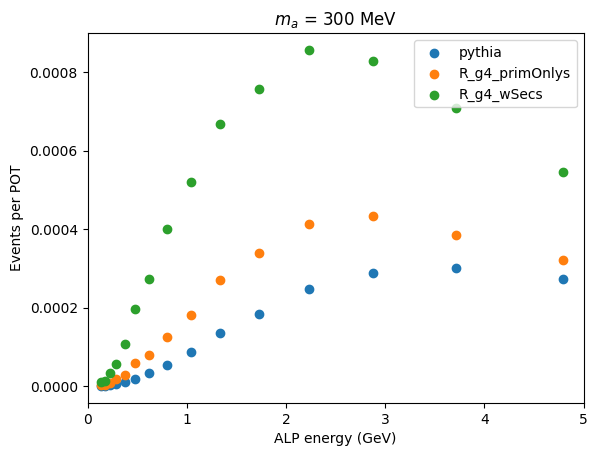

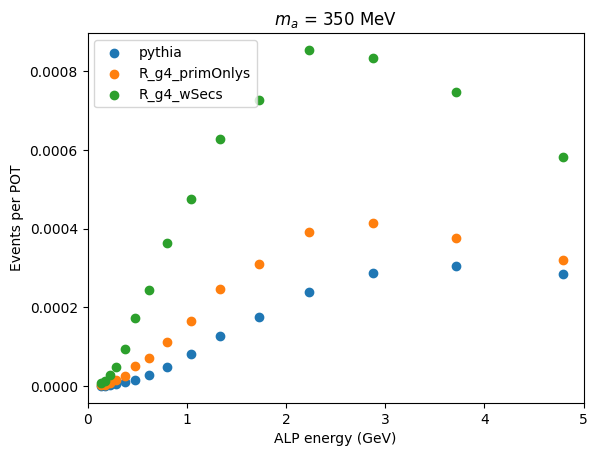

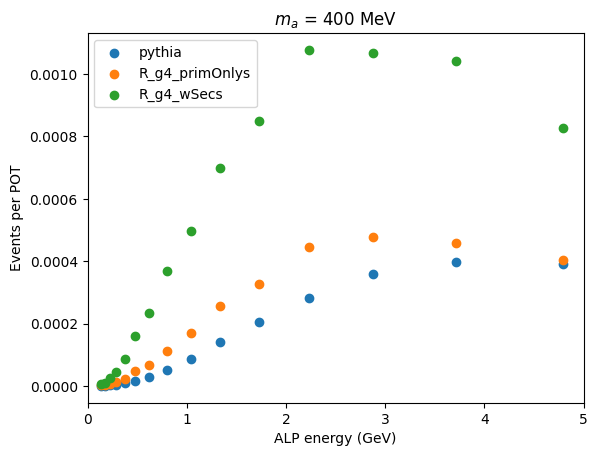

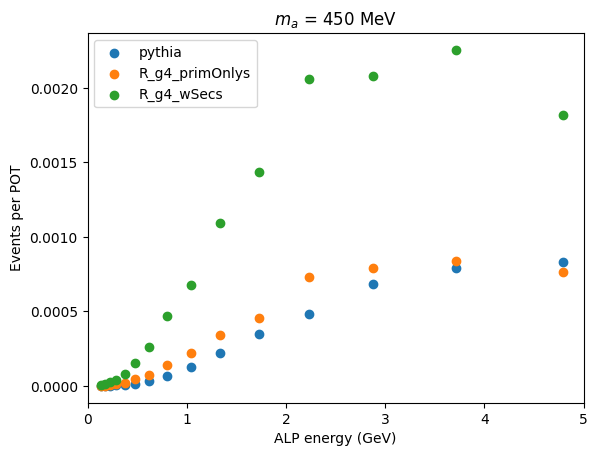

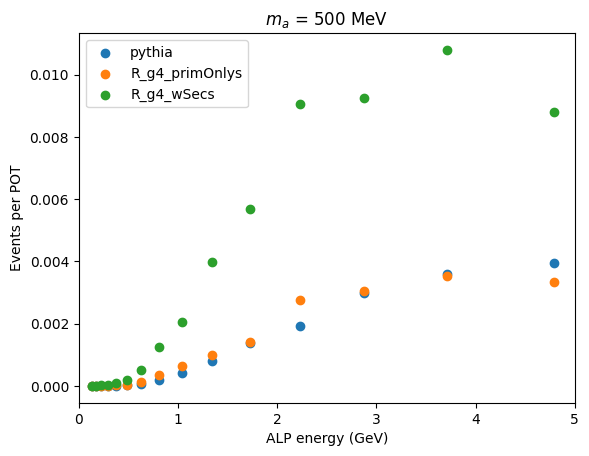

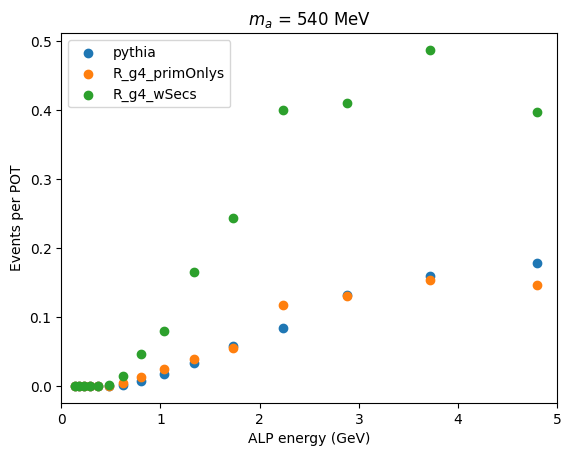

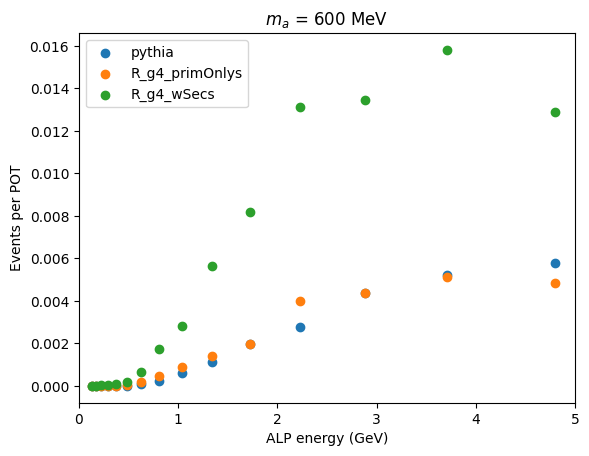

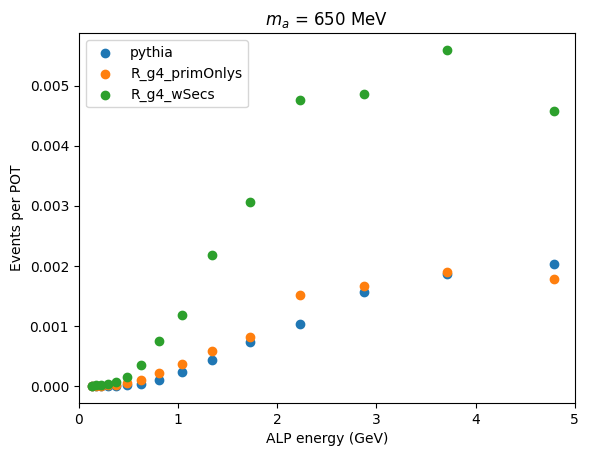

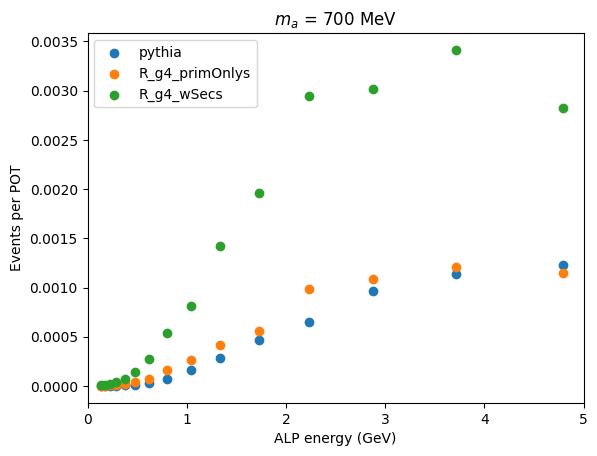

In [26]:
for i, m in enumerate(alp_nosup_masses):
    plt.scatter(E_low_bin_bounds[i], R_pythias[i], label='pythia')
    plt.scatter(E_low_bin_bounds[i], R_g4_primOnlys[i], label='R_g4_primOnlys')
    plt.scatter(E_low_bin_bounds[i], R_g4_wSecs[i], label='R_g4_wSecs')
    plt.xlabel('ALP energy (GeV)')
    plt.ylabel('Events per POT')
    plt.legend()
    plt.title('$m_a$ = %a MeV' % m)
    plt.xlim((0,5))
    #plt.ylim((0., 0.0002))
    plt.show()


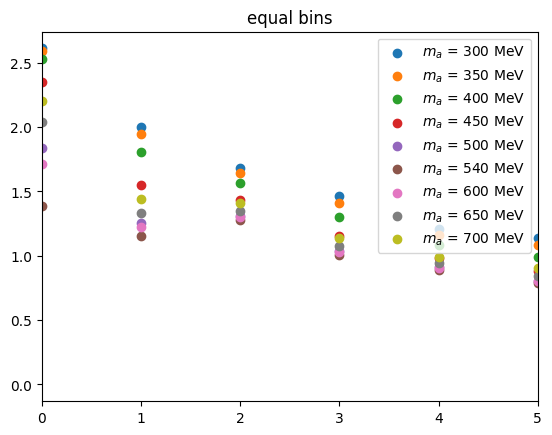

In [92]:
for i, m in enumerate(alp_nosup_masses):
    #if i > 2: 
    #    continue
    plt.scatter(E_low_bin_bounds[i], R_g4_primOnlys[i]/R_pythias[i], label = '$m_a$ = %a MeV' % m)
plt.legend()
plt.xlim((0,5))
plt.title('log bins')
plt.show()

In [15]:
#%%time
# This is the cell that adds the flux wgts to evtdf!
cats = make_categories(evtdf, detailed_bsm=True)
df = 0
alp_mass_ind = 0
w = 0
for c in cats:
    if 'ALP' in c.name: 
        #print(alp_mass_ind, ': ', c.name)
        df = evtdf[c]
        mass = np.array(alp_nosup_masses)[alp_mass_ind]

        mass = np.array(alp_nosup_masses)[alp_mass_ind]/1000.
        if mass in mass_to_alpSampleIndex.keys():
            i_alp = mass_to_alpSampleIndex[mass]
            i_alp_mcdf = mass_to_alp_mcdf_SampleIndex[mass]
        else:
            print("You've got a problem.")
        
        alpFluxRatios = np.array([get_alp_flux_w(x, alp_mass_ind)for x in evtdf[c].bsm_E])
        
        for uni in evtdf[c].wgt.flux.columns:
            shift = np.random.normal()
            w = 1 + alpFluxRatios*np.abs(shift)
            evtdf.loc[c, ('wgt', 'flux', *uni)] = w
        alp_mass_ind = alp_mass_ind + 1
    

### Extract the ALP running couplings, to use to check number of selected events of most abundant signal benchmarks for candidate near sidebands.

In [16]:
running_cmu_codominance_file = '/exp/icarus/data/users/jdyer/muon_selection/tabulated_running_alp_cmu_vals_fromJosh/cl_c3_1_c12_1.csv' 
fas = [] # fa values
cls = []
fa_strings = []
with open(running_cmu_codominance_file, 'r') as file:
    for line in file: 
        fa, cl = line.strip().split(',')
        fas.append(float(fa))
        cls.append(float(cl))
running_cmu_interp = interp1d(fas, cls)
   

In [ ]:
print(min(fas),', ', max(fas))
print(len(fas))
plt.scatter(fas, cls)
ynew = running_cmu_interp(np.array(fas))   # use interpolation function returned by `interp1d`
plt.plot(fas, ynew, '-')
plt.xlabel('$f_a$')
plt.ylabel('$c_\mu$')
#plt.xscale('log')
plt.title('Running $c_\mu$ w/ \nCodominance Scenario ($c_1 = c_2 = c_3 = 1$)')
plt.show()

plt.scatter(1./np.array(fas), cls)
#ynew = running_cmu_interp(np.array(fas))   # use interpolation function returned by `interp1d`
#plt.plot(fas, ynew, '-')
plt.xlabel('$1/f_a$')
plt.ylabel('$c_\mu$')
plt.xscale('log')
plt.title('Running $c_\mu$ w/ \nCodominance Scenario ($c_1 = c_2 = c_3 = 1$)')
plt.show()

In [17]:
good_alp_bm_fa = 5*10**3
good_alp_bm_cmu = running_cmu_interp(good_alp_bm_fa)
print('ALP bm with highest rate: \n', good_alp_bm_fa, ', ', good_alp_bm_cmu)

edge_alp_bm_fa = 2.5*10**4
edge_alp_bm_cmu = running_cmu_interp(edge_alp_bm_fa)
print('ALP bm at edge of sensitivity: \n', edge_alp_bm_fa, ', ', edge_alp_bm_cmu)

ALP bm with highest rate: 
 5000 ,  0.0004930866779987364
ALP bm at edge of sensitivity: 
 25000.0 ,  0.0006535395392087886


1/fa = 2*10^-4 is in the middle of my ALP sensitivity contour.

This corresponds to fa = 5*10^3, cmu = 0.00049309 under codominance scenario w/ running coupling.

Rescale all my ALP events to this model benchmark in order to verify that my sideband won't spoint signal there. Add the reweights for this benchmark directly to the dataframe. Call the column "rwt_to_good_alp_bm."

In [18]:
%%time
# This is the cell that adds "rwt_to_good_alp_bm" and "rwt_to_edge_alp_bm" to evtdf!
evtdf["rwt_to_good_alp_bm"]=1
evtdf["rwt_to_edge_alp_bm"]=1
cats = make_categories(evtdf, detailed_bsm=True)
df = 0
for c in cats:
    if 'ALP' in c.name: 
        print(evtdf[c].shape)
        print(mcdf.shape)
        #merged_df_left = pd.merge(evtdf[c], mcdf, on=['sample', '__ntuple', 'entry'], how='left')
        old_fas = np.array(pd.merge(evtdf[c], mcdf.C1, on=['sample', '__ntuple', 'entry'], how='left').C1)
        old_cmus = np.array(pd.merge(evtdf[c], mcdf.C2, on=['sample', '__ntuple', 'entry'], how='left').C2)
        #old_starts = np.array(pd.merge(evtdf[c], mcdf.start, on=['sample', '__ntuple', 'entry'], how='left'))
        
        old_starts = pd.merge(evtdf[c], mcdf.start, on=['sample', '__ntuple', 'entry'], how='left')[['x','y','z']].values
        old_enters = pd.merge(evtdf[c], mcdf.enter, on=['sample', '__ntuple', 'entry'], how='left')[['x','y','z']].values
        old_exits = pd.merge(evtdf[c], mcdf.exit, on=['sample', '__ntuple', 'entry'], how='left')[['x','y','z']].values
        
        old_decay_lengths = np.array(pd.merge(evtdf[c], mcdf.decay_length, on=['sample', '__ntuple', 'entry'], how='left').decay_length)
        old_adfs = np.array(pd.merge(evtdf[c], mcdf.allowed_decay_fraction, on=['sample', '__ntuple', 'entry'], how='left').allowed_decay_fraction)
        
        print('')
        print(c.name, " (",old_starts.shape,"):")
        print('Number of unique old_starts:', np.unique(old_starts).shape)
        print(np.unique(old_starts))
        print('Number of unique old_enters:', np.unique(old_enters).shape)
        print('Number of unique old_exits:', np.unique(old_exits).shape)
        
        #print(old_fas, old_cmus, old_starts, old_enters,old_exits, old_decay_lengths,
        #      old_adfs, sep='\n')
        #i=0
        #rwts_to_good_bm = [reweight_alps(old_fas[i], good_alp_bm_fa,
        #                                 old_cmus[i], good_alp_bm_cmu,
        #                                 old_starts[i], 
        #                                 old_enters[i], 
        #                                 old_exits[i],
        #                                 old_decay_lengths[i], 
        #                                 old_adfs[i]
        #                                )]
        #print(min(rwts_to_good_bm), max(rwts_to_good_bm), sep=', ')
        
        rwts_to_good_bm = [reweight_alps(old_fas[i], good_alp_bm_fa,
                                         old_cmus[i], good_alp_bm_cmu,
                                         old_starts[i], 
                                         old_enters[i], 
                                         old_exits[i],
                                         old_decay_lengths[i], 
                                         old_adfs[i]
                                        ) for i in range(evtdf[c].shape[0])]
        rwts_to_edge_bm = [reweight_alps(old_fas[i], edge_alp_bm_fa,
                                         old_cmus[i], edge_alp_bm_cmu,
                                         old_starts[i], 
                                         old_enters[i], 
                                         old_exits[i],
                                         old_decay_lengths[i], 
                                         old_adfs[i]
                                        ) for i in range(evtdf[c].shape[0])]
        print('Output of reweight function:')
        print(min(rwts_to_good_bm), max(rwts_to_good_bm), sep=', ')
        evtdf.loc[c,"rwt_to_good_alp_bm"] = rwts_to_good_bm
        evtdf.loc[c,"rwt_to_edge_alp_bm"] = rwts_to_edge_bm
        assert(max(evtdf.loc[c].rwt_to_good_alp_bm) == max(rwts_to_good_bm))


(14466, 834)
(1257100, 19)


<timed exec>:11: FutureWarning: merging between different levels is deprecated and will be removed in a future version. (6 levels on the left, 1 on the right)
<timed exec>:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
<timed exec>:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
<timed exec>:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmen


$M_{ALP}$ = 300, $c$ = 0.01, $fa$ = '1.0e+06'  ( (14466, 3) ):
Number of unique old_starts: (3,)
[-73363.25   -31512.037   -3364.4912]
Number of unique old_enters: (22927,)
Number of unique old_exits: (22927,)
Output of reweight function:
0.0033578135009479752, 2774716.424669046
(17668, 834)
(1257100, 19)


<timed exec>:11: FutureWarning: merging between different levels is deprecated and will be removed in a future version. (6 levels on the left, 1 on the right)
<timed exec>:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
<timed exec>:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
<timed exec>:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmen


$M_{ALP}$ = 350, $c$ = 0.01, $fa$ = '1.0e+06'  ( (17668, 3) ):
Number of unique old_starts: (3,)
[-73363.25   -31512.037   -3364.4912]
Number of unique old_enters: (28541,)
Number of unique old_exits: (28541,)
Output of reweight function:
1.544308495058423e-08, 2805204.477459347
(19617, 834)
(1257100, 19)


...


$M_{ALP}$ = 600, $c$ = 0.01, $fa$ = '1.0e+06'  ( (24829, 3) ):
Number of unique old_starts: (3,)
[-73363.25   -31512.037   -3364.4912]
Number of unique old_enters: (47713,)
Number of unique old_exits: (47715,)
Output of reweight function:
0.0, 3.7879090397906734e-188
(24667, 834)
(1257100, 19)


<timed exec>:11: FutureWarning: merging between different levels is deprecated and will be removed in a future version. (6 levels on the left, 1 on the right)
<timed exec>:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
<timed exec>:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
<timed exec>:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmen


$M_{ALP}$ = 650, $c$ = 0.01, $fa$ = '1.0e+06'  ( (24667, 3) ):
Number of unique old_starts: (3,)
[-73363.25   -31512.037   -3364.4912]
Number of unique old_enters: (47092,)
Number of unique old_exits: (47099,)
Output of reweight function:
0.0, 3.995033489017369e-76
(24409, 834)
(1257100, 19)


<timed exec>:11: FutureWarning: merging between different levels is deprecated and will be removed in a future version. (6 levels on the left, 1 on the right)
<timed exec>:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
<timed exec>:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
<timed exec>:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmen


$M_{ALP}$ = 700, $c$ = 0.01, $fa$ = '1.0e+06'  ( (24409, 3) ):
Number of unique old_starts: (3,)
[-73363.25   -31512.037   -3364.4912]
Number of unique old_enters: (46552,)
Number of unique old_exits: (46556,)
Output of reweight function:
0.0, 5.238641109512941e-74
CPU times: user 26.8 s, sys: 514 ms, total: 27.4 s
Wall time: 27.4 s


In [30]:
for col in evtdf.columns:
    print(col)

('slc', 'is_clear_cosmic', '', '', '', '')
('slc', 'vertex', 'x', '', '', '')
('slc', 'vertex', 'y', '', '', '')
('slc', 'vertex', 'z', '', '', '')
('slc', 'self', '', '', '', '')
('slc', 'tmatch', 'eff', '', '', '')
('slc', 'tmatch', 'pur', '', '', '')
('slc', 'tmatch', 'idx', '', '', '')
('slc', 'producer', '', '', '', '')
('slc', 'nuid', 'crlongtrkdiry', '', '', '')
('slc', 'reco', 'nstub', '', '', '')
('slc', 'reco', 'npfp', '', '', '')
('slc', 'fmatch', 'time', '', '', '')
('slc', 'truth', 'E', '', '', '')
('slc', 'truth', 'time', '', '', '')
('slc', 'truth', 'bjorkenX', '', '', '')
('slc', 'truth', 'inelasticityY', '', '', '')
('slc', 'truth', 'Q2', '', '', '')
('slc', 'truth', 'w', '', '', '')
('slc', 'truth', 'momentum', 'x', '', '')
('slc', 'truth', 'momentum', 'y', '', '')
('slc', 'truth', 'momentum', 'z', '', '')
('slc', 'truth', 'position', 'x', '', '')
('slc', 'truth', 'position', 'y', '', '')
('slc', 'truth', 'position', 'z', '', '')
('slc', 'truth', 'pdg', '', '', '')
('

### Print # signal and bg and associated uncertainties, given a set of cuts:

In [39]:
print('min, max flux weights for HPS uni 0:')
print(min(bsm_evtdf[bsm_evtdf['hps']==True].wgt.flux.univ_0), ', ', max(bsm_evtdf[bsm_evtdf['hps']==True].wgt.flux.univ_0))
print('min, max g4 weights for HPS uni 0:')
print(min(bsm_evtdf[bsm_evtdf['hps']==True].wgt.g4.univ_0), ', ', max(bsm_evtdf[bsm_evtdf['hps']==True].wgt.g4.univ_0))

print('')

print('min, max flux weights for ALP uni 0:')
print(min(bsm_evtdf[bsm_evtdf['alp']==True].wgt.flux.univ_0), ', ', max(bsm_evtdf[bsm_evtdf['alp']==True].wgt.flux.univ_0))
print('min, max g4 weights for ALP uni 0:')
print(min(bsm_evtdf[bsm_evtdf['alp']==True].wgt.g4.univ_0), ', ', max(bsm_evtdf[bsm_evtdf['alp']==True].wgt.g4.univ_0))

min, max flux weights for HPS uni 0:


NameError: name 'bsm_evtdf' is not defined

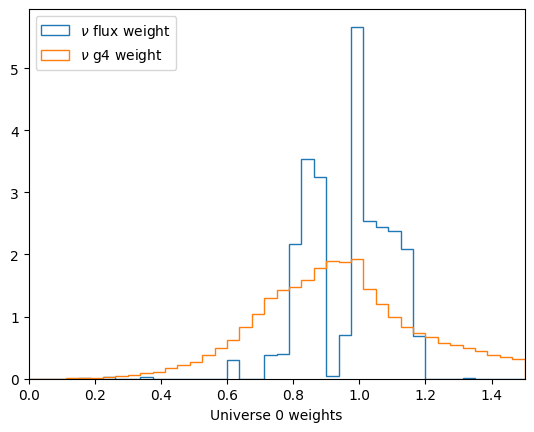

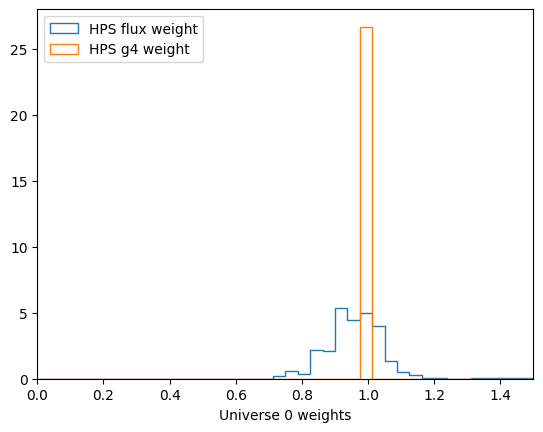

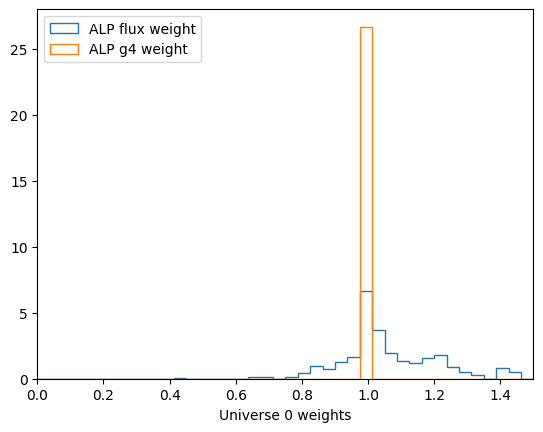

In [30]:
mybins=40
myrange=(0,1.5)
plt.hist(evtdf[cats[1]].wgt.flux.univ_1, label='$\\nu$ flux weight', bins=mybins, histtype='step', range=myrange, density=True)
plt.hist(evtdf[cats[1]].wgt.g4.univ_1, label='$\\nu$ g4 weight', bins=mybins, histtype='step', range=myrange, density=True)
plt.xlabel('Universe 0 weights')
plt.xlim(myrange)
plt.legend(loc='upper left')
plt.show()
# Q: Is the dis. for the nus from kaons bimodal too? If so, weird that its different from HPS.

plt.hist(bsm_evtdf[bsm_evtdf['hps']==True].wgt.flux.univ_1, label='HPS flux weight', bins=mybins, histtype='step', range=myrange, density=True)
plt.hist(bsm_evtdf[bsm_evtdf['hps']==True].wgt.g4.univ_1, label='HPS g4 weight', bins=mybins, histtype='step', range=myrange, density=True)
plt.xlabel('Universe 0 weights')
plt.xlim(myrange)
plt.legend(loc='upper left')
plt.show()

plt.hist(bsm_evtdf[bsm_evtdf['alp']==True].wgt.flux.univ_1, label='ALP flux weight', bins=mybins, histtype='step', range=myrange, density=True)
plt.hist(bsm_evtdf[bsm_evtdf['alp']==True].wgt.g4.univ_1, label='ALP g4 weight', bins=mybins, histtype='step', range=myrange, density=True)
plt.xlabel('Universe 0 weights')
plt.xlim(myrange)
plt.legend(loc='upper left')
plt.show()

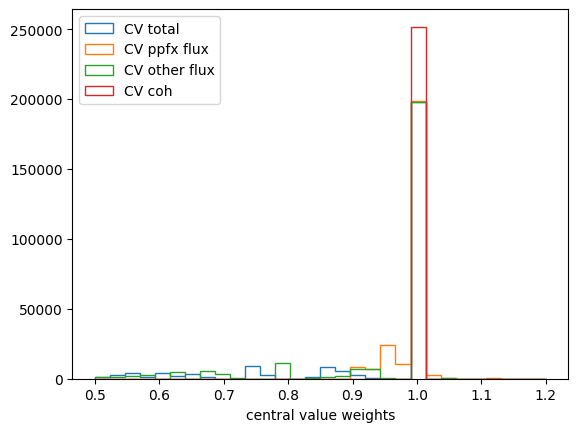

In [40]:
mybins=30
myrange=(0.5,1.2)
plt.hist(bsm_evtdf.wgt.cv.tot, label='CV total', bins=mybins, histtype='step', range=myrange)
plt.hist(bsm_evtdf.wgt.cv.ppfx, label='CV ppfx flux', bins=mybins, histtype='step', range=myrange)
plt.hist(bsm_evtdf.wgt.cv.flux_other_than_ppfx, label='CV other flux', bins=mybins, histtype='step', range=myrange)
plt.hist(bsm_evtdf.wgt.cv.coh, label='CV coh', bins=mybins, histtype='step', range=myrange)
plt.xlabel('central value weights')
plt.legend(loc='upper left')
plt.show()

In [38]:
for c in evtdf.columns: 
    if 'wgt' in c:
        print(c)

('wgt', 'cv', 'tot', '', '', '')
('wgt', 'cv', 'ppfx', '', '', '')
('wgt', 'cv', 'flux_other_than_ppfx', '', '', '')
('wgt', 'cv', 'flux_alp_secondaries', '', '', '')
('wgt', 'cv', 'coh', '', '', '')
('wgt', 'coh', 'univ_0', '', '', '')
('wgt', 'coh', 'univ_1', '', '', '')
('wgt', 'coh', 'univ_2', '', '', '')
('wgt', 'coh', 'univ_3', '', '', '')
('wgt', 'coh', 'univ_4', '', '', '')
('wgt', 'coh', 'univ_5', '', '', '')
('wgt', 'coh', 'univ_6', '', '', '')
('wgt', 'coh', 'univ_7', '', '', '')
('wgt', 'coh', 'univ_8', '', '', '')
('wgt', 'coh', 'univ_9', '', '', '')
('wgt', 'coh', 'univ_10', '', '', '')
('wgt', 'coh', 'univ_11', '', '', '')
('wgt', 'coh', 'univ_12', '', '', '')
('wgt', 'coh', 'univ_13', '', '', '')
('wgt', 'coh', 'univ_14', '', '', '')
('wgt', 'coh', 'univ_15', '', '', '')
('wgt', 'coh', 'univ_16', '', '', '')
('wgt', 'coh', 'univ_17', '', '', '')
('wgt', 'coh', 'univ_18', '', '', '')
('wgt', 'coh', 'univ_19', '', '', '')
('wgt', 'coh', 'univ_20', '', '', '')
('wgt', 'coh

In [21]:
print(evtdf.shape)
print(evtdf[evtdf.mccoh==True].shape)


(579047, 830)
(108593, 830)


In [21]:
coarse_cats = make_categories(evtdf, detailed_bsm=False, detailed_nu='none')
bgdf = evtdf[coarse_cats[1] | coarse_cats[2]]
print(bgdf.shape)

(228698, 832)


In [20]:
# look into bg flux uncertainty variation 12/23/25:

cuts = evtSel_dict['DD'][0]
thresholds = evtSel_dict['DD'][1]
df = evtdf

master_mask = None
for i in range(len(cuts)):
    if thresholds is None:
        func_output = cuts[i](*[df])
    else: 
        func_output = cuts[i](*[df], thresh=thresholds[i])
    if i==0: 
        master_mask = func_output[0]
    else:
        master_mask = master_mask & func_output[0]
    new_df = df[master_mask]
    
selected_df = df[master_mask]
#selected_df = df

coarse_cats = make_categories(selected_df, detailed_bsm=False, detailed_nu='none')
selected_bgdf = selected_df[coarse_cats[1] | coarse_cats[2]]
print('total bg calculated from selected_bgdf: ', np.sum(selected_bgdf.scale*selected_bgdf.wgt.cv.tot))
print(np.min(selected_bgdf.scale), ', ', np.max(selected_bgdf.scale))
print(np.min(selected_bgdf.wgt.cv.tot), ', ', np.max(selected_bgdf.wgt.cv.tot))

total_bg = np.sum(selected_bgdf.scale*selected_bgdf.wgt.cv.tot)
universe_contributions = ["flux"]
universe_contributions_use_in_plot = ["flux"]
universe_covs = []
for uc, uni_cont in enumerate(universe_contributions): # ["coh", "xsec", "flux", "g4"]
    hcov = None #3
    uni_counter = 0
    for col in selected_bgdf.wgt[uni_cont].columns:
        if not col[0].startswith("univ"): continue
        uni_counter = uni_counter + 1
        uni_weight = np.sum(selected_bgdf.scale*selected_bgdf.wgt.cv.tot*selected_bgdf.wgt[uni_cont][col])
        this_cov = (total_bg-uni_weight)**2
        if hcov is None:
            hcov = this_cov
        else:
            hcov += this_cov
    universe_covs.append(hcov/uni_counter)
flux_cov = universe_covs[0]
print('Fractional uncertainty on flux for selected BG events (most recently generated dataframes/weights): ', np.sqrt(flux_cov)/total_bg)



total bg calculated from selected_bgdf:  1.7828682910500768
0.04193852414074643 ,  0.5496800541877747
0.17176266335561713 ,  1.6647135871679164
Fractional uncertainty on flux for selected BG events (most recently generated dataframes/weights):  0.0707288199533405


Fractional uncertainty on flux for selected BG events (earlier generated dataframes/weights):
0.03918645971798309

Fractional uncertainty on flux for ALL BG events (earlier generated dataframes/weights):
0.017509004596869885

Fractional uncertainty on flux for selected BG events (mid-ly generated dataframes/weights):
0.09702506605337917

Fractional uncertainty on flux for ALL BG events (mid-ly recently generated dataframes/weights): 
0.010565661597942411

Fractional uncertainty on flux for selected BG events (most recently generated dataframes/weights):
0.0707288199533405

Fractional uncertainty on flux for ALL BG events (most recently generated dataframes/weights):
0.013741492943917794



In [53]:
for c in df.wgt.flux.columns:
    print(c)

('univ_0', '', '', '')
('univ_1', '', '', '')
('univ_2', '', '', '')
('univ_3', '', '', '')
('univ_4', '', '', '')
('univ_5', '', '', '')
('univ_6', '', '', '')
('univ_7', '', '', '')
('univ_8', '', '', '')
('univ_9', '', '', '')
('univ_10', '', '', '')
('univ_11', '', '', '')
('univ_12', '', '', '')
('univ_13', '', '', '')
('univ_14', '', '', '')
('univ_15', '', '', '')
('univ_16', '', '', '')
('univ_17', '', '', '')
('univ_18', '', '', '')
('univ_19', '', '', '')
('univ_20', '', '', '')
('univ_21', '', '', '')
('univ_22', '', '', '')
('univ_23', '', '', '')
('univ_24', '', '', '')
('univ_25', '', '', '')
('univ_26', '', '', '')
('univ_27', '', '', '')
('univ_28', '', '', '')
('univ_29', '', '', '')
('univ_30', '', '', '')
('univ_31', '', '', '')
('univ_32', '', '', '')
('univ_33', '', '', '')
('univ_34', '', '', '')
('univ_35', '', '', '')
('univ_36', '', '', '')
('univ_37', '', '', '')
('univ_38', '', '', '')
('univ_39', '', '', '')
('univ_40', '', '', '')
('univ_41', '', '', '')
('

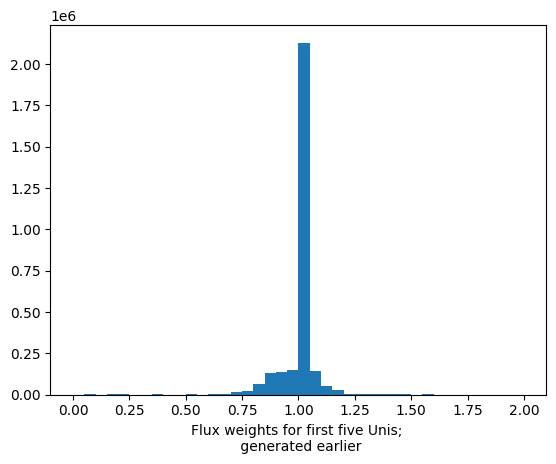

In [68]:
myrange = (0,2)
plt.hist(pd.concat([df.wgt.flux.univ_0, df.wgt.flux.univ_1, df.wgt.flux.univ_2, df.wgt.flux.univ_3, df.wgt.flux.univ_4 ]),
         bins=40,
         range=myrange)
plt.xlabel('Flux weights for first five Unis; \n generated earlier')
plt.xrange=(myrange)
plt.show()

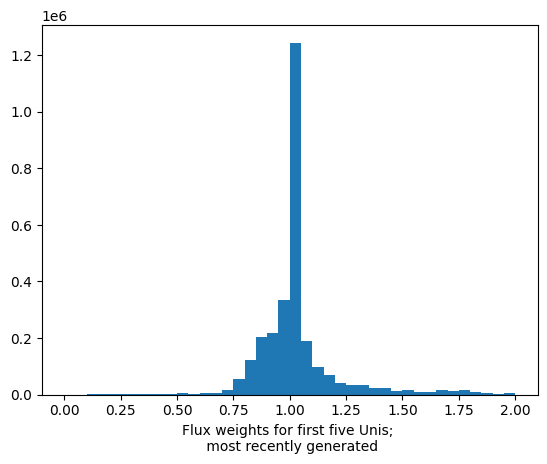

In [59]:
myrange = (0,2)
plt.hist(pd.concat([df.wgt.flux.univ_0, df.wgt.flux.univ_1, df.wgt.flux.univ_2, df.wgt.flux.univ_3, df.wgt.flux.univ_4 ]),
         bins=40,
         range=myrange)
plt.xlabel('Flux weights for first five Unis; \n most recently generated')
plt.xrange=(myrange)
plt.show()

In [19]:
def apply_cuts_and_reweight_signal(df, cuts, thresholds=None, 
                                   detailed_bsm=True, detailed_nu='int_type', 
                                   mccoh_detVar_dfs = mccoh_detVar_evtdfs,
                                   do_model_reweights=False, print_cuts=True
                                  ):
    
    # Loop through cuts to make rows for data frame and to make master_mask
    master_mask = None
    for i in range(len(cuts)):
        if thresholds is None:
            func_output = cuts[i](*[df])
        else: 
            func_output = cuts[i](*[df], thresh=thresholds[i])
        if i==0: 
            master_mask = func_output[0]
        else:
            master_mask = master_mask & func_output[0]
        new_df = df[master_mask]
        if print_cuts: print(func_output[1])
    
    # Count events by category: MC, POT-normalized, and POT-normalized w/ reweights to different model benchmarks
    selected_df = df[master_mask]
    total_mc = []
    total_POT_normed = []
    total_POT_normed_rwt_to_good_bm = []
    total_POT_normed_rwt_to_edge_bm = []
    stat_unc_by_cat = []
    POT_normed_unc_by_cat_coh = []
    POT_normed_unc_by_cat_xsec = []
    POT_normed_unc_by_cat_flux = []
    POT_normed_unc_by_cat_g4 = []
    POT_normed_unc_by_cat = [] # 12/2/25 TODO: take care of this in the following for loop.
    total_POT_normed_rwt_to_fa_E5 = []
    categories = make_categories(selected_df, detailed_bsm=detailed_bsm, detailed_nu=detailed_nu)
    alp_mass_ind = 0
    
    # Initialize the dataframe to display:
    display_df = pd.DataFrame(
        np.zeros((0,len(categories)), dtype=int), # start w/ zero rows (cuts), fill later
        columns = [c.name for c in categories]
    )
    display_df = display_df.T
    
    for c in categories:
                
        #c = [True]*selected_df.shape[0]
        
        total_mc.append(selected_df[c].shape[0])
        total_POT_normed.append(np.sum(selected_df[c].scale*selected_df[c].wgt.cv.tot))
        total_POT_normed_rwt_to_good_bm.append(np.sum(selected_df[c].scale*selected_df[c].wgt.cv.tot*selected_df[c].rwt_to_good_alp_bm))
        total_POT_normed_rwt_to_edge_bm.append(np.sum(selected_df[c].scale*selected_df[c].wgt.cv.tot*selected_df[c].rwt_to_edge_alp_bm))
        
        # MC Statistical
        stat_unc_by_cat.append(np.sqrt(np.sum((selected_df[c].scale*selected_df[c].wgt.cv.tot)**2)))
        
        # ~~~~~~ SUM OVER UNIVERSES. 
        
        # ~~ separate (#coh, #xsec, #flux, #g4)
        universe_contributions = ["coh", "xsec", "flux", "g4"]
        universe_contributions_use_in_plot = ["coh xs", "other xs", "flux", "g4"]
        universe_covs = []
        for uc, uni_cont in enumerate(universe_contributions): # ["coh", "xsec", "flux", "g4"]
            hcov = None # 1
            uni_counter = 0
            for col in selected_df[c].wgt[uni_cont].columns:
                if not col[0].startswith("univ"): continue
                uni_counter = uni_counter + 1
                uni_weight = np.sum(selected_df[c].scale*selected_df[c].wgt.cv.tot*selected_df[c].wgt[uni_cont][col])
                this_cov = (np.sum(selected_df[c].scale*selected_df[c].wgt.cv.tot)-uni_weight)**2
                if hcov is None:
                    hcov = this_cov
                else:
                    hcov += this_cov
            universe_covs.append(hcov/uni_counter)
        POT_normed_unc_by_cat_coh.append(np.sqrt(universe_covs[0]))
        POT_normed_unc_by_cat_xsec.append(np.sqrt(universe_covs[1]))
        POT_normed_unc_by_cat_flux.append(np.sqrt(universe_covs[2]))
        POT_normed_unc_by_cat_g4.append(np.sqrt(universe_covs[3]))
        
        ## ~~ together ("all" = coh * xsec * flux * g4)
        #hcov = None #2
        #nuni = len(selected_df[c].wgt["all"].columns)
        #for col in selected_df[c].wgt["all"].columns:
        #    if not col[0].startswith("univ"): continue
        #    uni_weight = np.sum(selected_df[c].scale*selected_df[c].wgt.cv.tot*selected_df[c].wgt["all"][col])
        #    this_cov = (np.sum(selected_df[c].scale*selected_df[c].wgt.cv.tot)-uni_weight)**2
        #    if hcov is None:
        #        hcov = this_cov
        #    else:
        #        hcov += this_cov
        #POT_normed_unc_by_cat.append(hcov/nuni)
        
        if do_model_reweights:
            if 'ALP' in c.name:
                mass = np.array(alp_nosup_masses)[alp_mass_ind]/1000.
                #print(mass, ', ', c.name)
                reweigts_psuedomixed_alps = []
                if mass in mass_to_alpSampleIndex.keys():
                    i_alp = mass_to_alpSampleIndex[mass]
                    i_alp_mcdf = mass_to_alp_mcdf_SampleIndex[mass]
                    old_fa = float(alp_nosup_mcdfs[i_alp_mcdf].iloc[[0]].C1)
                    old_cmu = float(alp_nosup_mcdfs[i_alp_mcdf].iloc[[0]].C2)        
                    old_alp_f = float(alp_nosup_mcdfs[i_alp_mcdf].iloc[0].allowed_decay_fraction)    
                    reweigts_psuedomixed_alps = []
                    #display(alp_nosup_mcdfs[i_alp_mcdf])
                    for idx in selected_df[c].index:
                        #if mass==0.4: print(idx)
                        row = alp_nosup_mcdfs[i_alp_mcdf].loc[(idx[1],idx[2], 0)]
                        factor_rwgt_producedAlps = float(
                            reweight_alps(old_fa, 10**5, old_cmu, 0.01, 
                                            row.start, row.enter, row.exit, 
                                            row.decay_length, old_alp_f)
                        )
                        reweigts_psuedomixed_alps.append(factor_rwgt_producedAlps)
                    total_POT_normed_rwt_to_fa_E5.append(np.sum(selected_df[c].scale*selected_df[c].wgt.cv.tot*reweigts_psuedomixed_alps))
                    mass = round(mass+0.05,2)
                else: (print('Uh-oh, dont know alp mcdf info!'))
                alp_mass_ind = alp_mass_ind+1
            else:
                total_POT_normed_rwt_to_fa_E5.append(-1)
    
    display_df['# MC events']=total_mc
    display_df['POT normed']=total_POT_normed
    display_df['POT normed, rwt to $f_a$=%a, $c_\mu$=%a' % (good_alp_bm_fa, float(good_alp_bm_cmu))]=total_POT_normed_rwt_to_good_bm
    display_df['POT normed, rwt to $f_a$=%a, $c_\mu$=%a' % (edge_alp_bm_fa, float(edge_alp_bm_cmu))]=total_POT_normed_rwt_to_edge_bm

    display_df['MC stat. unc.'] = np.array(stat_unc_by_cat)/np.array(total_POT_normed)
    
    print('POT_normed_unc_by_cat_coh: ', POT_normed_unc_by_cat_coh)
    print('POT_normed_unc_by_cat_xsec: ', POT_normed_unc_by_cat_xsec)
    print('POT_normed_unc_by_cat_flux: ', POT_normed_unc_by_cat_flux)
    print('POT_normed_unc_by_cat_g4: ', POT_normed_unc_by_cat_g4)
    
    display_df['coh_xs syst.'] = np.array(POT_normed_unc_by_cat_coh)/np.array(total_POT_normed)
    display_df['incoh_xs syst.'] = np.array(POT_normed_unc_by_cat_xsec)/np.array(total_POT_normed)
    display_df['flux syst.'] = np.array(POT_normed_unc_by_cat_flux)/np.array(total_POT_normed)
    display_df['g4 syst.'] = np.array(POT_normed_unc_by_cat_g4)/np.array(total_POT_normed)                       
                                        
    #display_df['coh_xs, incoh_xs, g4, \n& flux syst.'] = POT_normed_unc_by_cat/total_POT_normed
    
    display_df['detector syst.'] = [0.]*len(total_POT_normed)
    
    tot_unc_col = np.sqrt(
        display_df['MC stat. unc.']**2 + 
        display_df['coh_xs syst.']**2 + display_df['incoh_xs syst.']**2 +
        display_df['flux syst.']**2 + display_df['g4 syst.']**2 + display_df['detector syst.']**2    
    )
    display_df['Total unc.'] = tot_unc_col #[0.]*len(total_POT_normed)
    print('Total fractional uncertainty, calculated from columns: \n', tot_unc_col)
    x = np.sqrt(
        np.array(stat_unc_by_cat)**2 + np.array(POT_normed_unc_by_cat_coh)**2 + np.array(POT_normed_unc_by_cat_xsec)**2 +
        np.array(POT_normed_unc_by_cat_flux)**2 + np.array(POT_normed_unc_by_cat_g4)**2 + np.array([0.]*len(total_POT_normed))**2
    )/np.array(total_POT_normed)
    print('Total fractional uncertainty, calculated from uncertainties: \n', x)
    
    if do_model_reweights: 
        display_df['POT normed, rwt to fa=E5']=total_POT_normed_rwt_to_fa_E5
    
    sum_of_bg = display_df.iloc[16:].sum(axis=0)
    display_df.loc['Total BG']=sum_of_bg
    total_bg = float(display_df.loc['Total BG']['POT normed'])
    print('total_bg: ', total_bg)
        
    # CALCULATE THE TOTAL UNCERTAINTY ON BACKGROUND (not by category):

    coarse_cats = make_categories(selected_df, detailed_bsm=False, detailed_nu='none')
    selected_bgdf = selected_df[coarse_cats[1] | coarse_cats[2]]
    print('total bg calculated from selected_bgdf: ', np.sum(selected_bgdf.scale*selected_bgdf.wgt.cv.tot))
    
    # statistical:
    mc_stat_err = np.sqrt(np.sum((selected_bgdf.scale*selected_bgdf.wgt.cv.tot)**2))
    print('selected_bgdf.shape: ', selected_bgdf.shape)
    print('mc_stat_err: ', mc_stat_err)
    
    display_df.loc['Total BG']['MC stat. unc.'] = mc_stat_err/total_bg
    
    # ~~~~~~ SUM OVER UNIVERSES. 
        
    # ~~ separate (#coh, #xsec, #flux, #g4)
    universe_contributions = ["coh", "xsec", "flux", "g4"]
    universe_contributions_use_in_plot = ["coh xs", "other xs", "flux", "g4"]
    universe_covs = []
    for uc, uni_cont in enumerate(universe_contributions): # ["coh", "xsec", "flux", "g4"]
        hcov = None #3
        uni_counter = 0
        for col in selected_bgdf.wgt[uni_cont].columns:
            if not col[0].startswith("univ"): continue
            uni_counter = uni_counter + 1
            uni_weight = np.sum(selected_bgdf.scale*selected_bgdf.wgt.cv.tot*selected_bgdf.wgt[uni_cont][col])
            this_cov = (total_bg-uni_weight)**2
            if hcov is None:
                hcov = this_cov
            else:
                hcov += this_cov
        universe_covs.append(hcov/uni_counter)
    coh_cov = universe_covs[0]
    xsec_cov = universe_covs[1]
    flux_cov = universe_covs[2]
    g4_cov = universe_covs[3]
        
    display_df.loc['Total BG']['coh_xs syst.'] = np.sqrt(coh_cov)/total_bg
    display_df.loc['Total BG']['incoh_xs syst.'] = np.sqrt(xsec_cov)/total_bg
    display_df.loc['Total BG']['flux syst.'] = np.sqrt(flux_cov)/total_bg
    display_df.loc['Total BG']['g4 syst.'] = np.sqrt(g4_cov)/total_bg
        
    # ~~ together ("all" = coh * xsec * flux * g4)
    
    uni_weights = []
    hcov = None #4
    for col in selected_bgdf.wgt["all"].columns:
        if not col[0].startswith("univ"): continue
        uni_weight = np.sum(selected_bgdf.scale*selected_bgdf.wgt.cv.tot*selected_bgdf.wgt["all"][col])
        uni_weights.append(uni_weight)
        this_cov = (total_bg-uni_weight)**2
        if hcov is None:
            hcov = this_cov
        else:
            hcov += this_cov
    #print('hcov: ', hcov)
    #print('len(uni_weights): ', len(uni_weights))
    Universe_cov = hcov / len(uni_weights)
    #print('Universe_cov: ', Universe_cov)
    #display_df.loc['Total BG']['coh_xs, incoh_xs, g4, \n& flux systematics'] = np.sqrt(Universe_cov)/total_bg
    print('Total systematic unc on bg from coh_xs, incoh_xs, g4, flux: ', np.sqrt(Universe_cov))
    print('Total systematic unc on bg from coh_xs, incoh_xs, g4, flux, \
    as calculated from doing them all separately: ', np.sqrt(coh_cov+xsec_cov+flux_cov+g4_cov))
        
    ## ~~~~~~
                
    # BG MC DETECTOR SYSTEMATICS
    
    do_detector_variations=True     
    if do_detector_variations:
        
        # calculate fraction of selected bg events that are cohlike:
        selected_cohlike_mask = (selected_bgdf.mccoh==True)
        selected_cohlike = np.sum(selected_bgdf[selected_cohlike_mask].scale * selected_bgdf[selected_cohlike_mask].wgt.cv.tot)
        #print('selected_cohlike: ', selected_cohlike)
        frac_cohlike = selected_cohlike/total_bg
        print('frac_cohlike: ', frac_cohlike)
        
        # apply event selection to detector variation samples and get cov for each:
        selected_syst_evtdfs = [] # cohlikes
        dv_covs = []
        for d, systdf in enumerate(mccoh_detVar_dfs):
            cut_results = apply_cuts(systdf, cuts, thresholds=thresholds, detailed_nu='none', print_cuts=print_cuts)
            mask = cut_results[-1]
            sel_systdf = systdf[mask]
            selected_syst_evtdfs.append(sel_systdf)
            dv_covs.append( (total_bg - (1/frac_cohlike)*np.sum(sel_systdf.scale*sel_systdf.wgt.cv.tot))**2 )
        mccoh_detVar_dfs = selected_syst_evtdfs
        total_det_syst_bg = np.sqrt(np.sum(dv_covs))
        print('Total detector uncertainty on total bg: ', total_det_syst_bg)
        display_df.loc['Total BG']['detector syst.'] = total_det_syst_bg/total_bg
        
        display_df['detector syst.'] = [total_det_syst_bg/total_bg]*display_df.shape[0] # placeholder for now until I get actual values.
        
        total_unc = np.sqrt(Universe_cov + np.sum(dv_covs) + mc_stat_err**2)
        print('Total Uncertainty on total bg: ', total_unc)
        display_df.loc['Total BG']['Total unc.'] = total_unc/total_bg
    
        
    ###
    
    display(display_df)
    return display_df 

In [19]:
%%time
cut_list = evtSel_dict['DD'][0]
thresholds = evtSel_dict['DD'][1]
x = apply_cuts_and_reweight_signal(evtdf, cut_list, thresholds=thresholds,
                                   mccoh_detVar_dfs = mccoh_detVar_evtdfs,
                                   detailed_nu='int_type', detailed_bsm=True)



dE/dx <= 50 MeV/cm up to 0_5 cm
dE/dx <= 35 MeV/cm 0_5-1 cm
dE/dx <= 15 MeV/cm 1-2 cm
dE/dx <= 10 MeV/cm 2-3 cm
max shower len < 0.0 cm
contained trk chi2mu < 8
S_NuMI_angle < 3 deg
opening angle < 25 deg
shorter of tracks > 100.0 cm


/tmp/ipykernel_2144872/488280199.py:127: RuntimeWarning: invalid value encountered in divide
  display_df['MC stat. unc.'] = np.array(stat_unc_by_cat)/np.array(total_POT_normed)
/tmp/ipykernel_2144872/488280199.py:134: RuntimeWarning: invalid value encountered in divide
  display_df['coh_xs syst.'] = np.array(POT_normed_unc_by_cat_coh)/np.array(total_POT_normed)
/tmp/ipykernel_2144872/488280199.py:135: RuntimeWarning: invalid value encountered in divide
  display_df['incoh_xs syst.'] = np.array(POT_normed_unc_by_cat_xsec)/np.array(total_POT_normed)
/tmp/ipykernel_2144872/488280199.py:136: RuntimeWarning: invalid value encountered in divide
  display_df['flux syst.'] = np.array(POT_normed_unc_by_cat_flux)/np.array(total_POT_normed)
/tmp/ipykernel_2144872/488280199.py:137: RuntimeWarning: invalid value encountered in divide
  display_df['g4 syst.'] = np.array(POT_normed_unc_by_cat_g4)/np.array(total_POT_normed)
/tmp/ipykernel_2144872/488280199.py:150: RuntimeWarning: invalid value encoun

POT_normed_unc_by_cat_coh:  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.6752501084255599, 0.0, 0.0]
POT_normed_unc_by_cat_xsec:  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.024039443364496, 0.02655779426502983, 0.0, 0.0, 0.0]
POT_normed_unc_by_cat_flux:  [4.711345611381294e-05, 0.000634089433916612, 0.0014576356953075157, 0.0016226637133533828, 0.0016744708969219128, 0.0016450602788047155, 0.0020569988595702158, 0.00021182008747102574, 0.0003007155372204834, 0.0003186045495863739, 0.0004329539604840362, 0.0007104261484171252, 0.0068356679499027295, 0.00046444253753628504, 5.430527630177632e-05, 0.00011526881845121198, 0.0, 0.0, 0.0027289471737590777, 0.054081329846112546, 0.07624010701061214, 0.0, 0.0]
POT_normed_unc_by_cat_g4:  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.01834104873460194, 0.22924393563751, 0.14954457300674884, 0.

/tmp/ipykernel_2144872/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)


dE/dx <= 35 MeV/cm 0_5-1 cm


...

/tmp/ipykernel_2144872/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_2144872/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)


opening angle < 25 deg
shorter of tracks > 100.0 cm
Total detector uncertainty on total bg:  0.7080592954695042
Total Uncertainty on total bg:  1.0699543554046946


/tmp/ipykernel_2144872/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)


,# MC events,POT normed,"POT normed, rwt to $f_a$=5000, $c_\mu$=0.0004930866779987364","POT normed, rwt to $f_a$=25000.0, $c_\mu$=0.0006535395392087886",MC stat. unc.,coh_xs syst.,incoh_xs syst.,flux syst.,g4 syst.,detector syst.,Total unc.
"$M_S$ = 220, $\theta_S$ = 1e-05",429.0,0.000738,7.377541e-04,7.377541e-04,0.049339,0.000000,0.000000,0.063861,0.000000,0.397146,0.080700
"$M_S$ = 240, $\theta_S$ = 1e-05",1205.0,0.010647,1.064708e-02,1.064708e-02,0.029301,0.000000,0.000000,0.059555,0.000000,0.397146,0.066373
"$M_S$ = 260, $\theta_S$ = 1e-05",1475.0,0.025652,2.565235e-02,2.565235e-02,0.026662,0.000000,0.000000,0.056823,0.000000,0.397146,0.062767
"$M_S$ = 280, $\theta_S$ = 1e-05",873.0,0.033151,3.315103e-02,3.315103e-02,0.034675,0.000000,0.000000,0.048948,0.000000,0.397146,0.059985
"$M_S$ = 300, $\theta_S$ = 1e-05",1412.0,0.035948,3.594817e-02,3.594817e-02,0.027307,0.000000,0.000000,0.046580,0.000000,0.397146,0.053994
"$M_S$ = 320, $\theta_S$ = 1e-05",1528.0,0.030375,3.037474e-02,3.037474e-02,0.026324,0.000000,0.000000,0.054159,0.000000,0.397146,0.060217
"$M_S$ = 340, $\theta_S$ = 1e-05",1697.0,0.020228,2.022805e-02,2.022805e-02,0.025086,0.000000,0.000000,0.101690,0.000000,0.397146,0.104739
"$M_{ALP}$ = 300, $c$ = 0.01, $fa$ = '1.0e+06'",3005.0,0.000326,1.041881e+02,3.125740e+00,0.018415,0.000000,0.000000,0.648937,0.000000,0.397146,0.649198
"$M_{ALP}$ = 350, $c$ = 0.01, $fa$ = '1.0e+06'",3439.0,0.000546,2.910831e+02,5.368069e+00,0.017152,0.000000,0.000000,0.550572,0.000000,0.397146,0.550839
"$M_{ALP}$ = 400, $c$ = 0.01, $fa$ = '1.0e+06'",3375.0,0.000925,1.511363e+03,9.592588e+00,0.017296,0.000000,0.000000,0.344327,0.000000,0.397146,0.344761


CPU times: user 5min 29s, sys: 2.66 s, total: 5min 32s
Wall time: 5min 34s


In [49]:
print(good_alp_bm_fa)
print(float(good_alp_bm_cmu))

print(edge_alp_bm_fa)
print(float(edge_alp_bm_cmu))

5000
0.0004930866779987364
25000.0
0.0006535395392087886


In [21]:
sum_of_bg = x.iloc[16:].sum(axis=0)
x.loc['Total BG']=sum_of_bg
x

,# MC events,POT normed,"POT normed, rwt to fa=E5"
"$M_S$ = 220, $\theta_S$ = 1e-05",429.0,0.000645,-1.000000e+00
"$M_S$ = 240, $\theta_S$ = 1e-05",1205.0,0.009546,-1.000000e+00
"$M_S$ = 260, $\theta_S$ = 1e-05",1475.0,0.023138,-1.000000e+00
"$M_S$ = 280, $\theta_S$ = 1e-05",873.0,0.030439,-1.000000e+00
"$M_S$ = 300, $\theta_S$ = 1e-05",1412.0,0.033143,-1.000000e+00
"$M_S$ = 320, $\theta_S$ = 1e-05",1528.0,0.028177,-1.000000e+00
"$M_S$ = 340, $\theta_S$ = 1e-05",1697.0,0.019019,-1.000000e+00
"$M_{ALP}$ = 300, $c$ = 0.01, $fa$ = '1.0e+06'",3005.0,0.000152,9.308564e-01
"$M_{ALP}$ = 350, $c$ = 0.01, $fa$ = '1.0e+06'",3439.0,0.000256,1.359735e+00
"$M_{ALP}$ = 400, $c$ = 0.01, $fa$ = '1.0e+06'",3375.0,0.000403,1.898132e+00


In [18]:
xx = x.iloc[7:16,:]
xx['3rd col / 2nd col']=round(xx['POT normed, rwt to fa=E5']/xx['POT normed'])
xx

/tmp/ipykernel_3642246/854853067.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  xx['3rd col / 2nd col']=round(xx['POT normed, rwt to fa=E5']/xx['POT normed'])


,# MC events,POT normed,"POT normed, rwt to fa=E5",3rd col / 2nd col
"$M_{ALP}$ = 300, $c$ = 0.01, $fa$ = '1.0e+06'",3005,0.000152,9.308564e-01,6116.0
"$M_{ALP}$ = 350, $c$ = 0.01, $fa$ = '1.0e+06'",3439,0.000256,1.359735e+00,5321.0
"$M_{ALP}$ = 400, $c$ = 0.01, $fa$ = '1.0e+06'",3375,0.000403,1.898132e+00,4705.0
"$M_{ALP}$ = 450, $c$ = 0.01, $fa$ = '1.0e+06'",3440,0.000910,3.438276e+00,3778.0
"$M_{ALP}$ = 500, $c$ = 0.01, $fa$ = '1.0e+06'",3438,0.004448,3.648556e+00,820.0
"$M_{ALP}$ = 540, $c$ = 0.01, $fa$ = '1.0e+06'",4458,0.066467,8.327871e-13,0.0
"$M_{ALP}$ = 600, $c$ = 0.01, $fa$ = '1.0e+06'",2802,0.007320,4.434242e-01,61.0
"$M_{ALP}$ = 650, $c$ = 0.01, $fa$ = '1.0e+06'",2360,0.002866,9.820892e-01,343.0
"$M_{ALP}$ = 700, $c$ = 0.01, $fa$ = '1.0e+06'",1819,0.001651,7.009260e-01,424.0


In [53]:
for c in evtdf.wgt.columns: #coh, #xsec, #flux, #g4, #all -- all of these have 100 universes
    print(c)

('cv', 'tot', '', '', '')
('cv', 'ppfx', '', '', '')
('cv', 'flux_other_than_ppfx', '', '', '')
('cv', 'coh', '', '', '')
('coh', 'univ_0', '', '', '')
('coh', 'univ_1', '', '', '')
('coh', 'univ_2', '', '', '')
('coh', 'univ_3', '', '', '')
('coh', 'univ_4', '', '', '')
('coh', 'univ_5', '', '', '')
('coh', 'univ_6', '', '', '')
('coh', 'univ_7', '', '', '')
('coh', 'univ_8', '', '', '')
('coh', 'univ_9', '', '', '')
('coh', 'univ_10', '', '', '')
('coh', 'univ_11', '', '', '')
('coh', 'univ_12', '', '', '')
('coh', 'univ_13', '', '', '')
('coh', 'univ_14', '', '', '')
('coh', 'univ_15', '', '', '')
('coh', 'univ_16', '', '', '')
('coh', 'univ_17', '', '', '')
('coh', 'univ_18', '', '', '')
('coh', 'univ_19', '', '', '')
('coh', 'univ_20', '', '', '')
('coh', 'univ_21', '', '', '')
('coh', 'univ_22', '', '', '')
('coh', 'univ_23', '', '', '')
('coh', 'univ_24', '', '', '')
('coh', 'univ_25', '', '', '')
('coh', 'univ_26', '', '', '')
('coh', 'univ_27', '', '', '')
('coh', 'univ_28', '

### makeplot()

In [20]:
saveplots = False
plotdir = '/exp/icarus/data/users/jdyer/muon_datamc/plots/'
def makeplot(df, var, 
             syst_evtdfs, syst_vars, 
             myrange, xlabel = 'x axis', bins = 25, vline=None, detailed_nu='int_type', do_systs=True,
             POTSTR=POTSTR, title=None, ratio_bounds=None, plotname='noname', ylabel=None,
             textOnPlot = '', 
             bsm_index=None, bsm_detector_varis_vars=[], bsm_magnifier=1, fwt_bsm_to_high_prob_bench = False,
             rwt_alp = False,
             evtSel_key=None, 
             do_detector_variations=True,
             subplot='percent', 
             do_subplot = True, 
             print_cuts = False
            ): # , [-1,3]
    # options for 'detailed_mc' are: 'int_type', 'cd /exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-toolsfinal_state', 'none'
    # df: concatenation of mccoh, mcincoh, and bsm evt_dfs (data to come later)
    # var: corresponds to 'df' variable
    # syst_evtdfs: for the cohlike events and bsm
    # syst_vars: correspond to the 'syst_evtdfs'
    
    do_detector_variations_signal = False
    
    if bsm_index is not None:
        if do_detector_variations_signal:
            assert len(bsm_detector_varis_vars)>0, 'You need to provide the signal detector variation sample vars!'
        categories = make_categories(df, detailed_nu = detailed_nu, detailed_bsm=True)
        bsm_cats = [c for c in categories if c.mc_signal]
        bsm_cat = bsm_cats[bsm_index]
        bsm_df = df[bsm_cat]
        bsm_var = var[bsm_cat]
        if do_detector_variations_signal:
            bsm_syst_evtdfs = bsm_detector_varis_dfs[bsm_index]
            bsm_syst_vars = bsm_detector_varis_vars[bsm_index]
    
    mc_evtdf = df[df.mc & ~df.bsm]
    mc_var = var[df.mc & ~df.bsm]
    unq = np.unique(np.array(mc_evtdf.scale))
    print('VERIFY THAT THIS NUMBER IS TWO (1 nominal nu sample, and any number of cohlike samples (whose POTs get combined), for a total of 2 POT scalings): ', len(mc_evtdf.scale.unique())) # len(unq)) # for the cohlike and nominal samples (later there will be more cohlikes).
    
    # first apply event selection, if applicable:
    if evtSel_key is not None:
        cut_list = evtSel_dict[evtSel_key][0]
        thresholds = evtSel_dict[evtSel_key][1]
        
        # df, var:
        cut_results = apply_cuts(df, cut_list, thresholds=thresholds, detailed_nu='none', print_cuts=print_cuts)
        mask = cut_results[-1]
        df, var = df[mask], var[mask]
        #print('selected_evtdf.shape: ', df.shape)

        
        if do_detector_variations:
            # cohlike detector variations df, cohlike detector variations var
            new_syst_evtdfs, new_syst_vars = [], []
            for d, systdf in enumerate(syst_evtdfs):
                #print('systdf: \n', systdf)
                cut_results = apply_cuts(systdf, cut_list, thresholds=thresholds, detailed_nu='none', make_pretty_dfs=False)
                mask = cut_results[-1]
                new_syst_evtdfs.append(systdf[mask])
                new_syst_vars.append(syst_vars[d][mask])
            syst_evtdfs, syst_vars = new_syst_evtdfs, new_syst_vars
        
        # bsm detector variations df, bsm detector variations var
        if bsm_index is not None:
            cut_results = apply_cuts(bsm_df, cut_list, thresholds=thresholds, detailed_nu='none')
            mask = cut_results[-1]
            bsm_df = bsm_df[mask]
            bsm_var = bsm_var[mask]
        
            if do_detector_variations_signal:
                new_bsm_syst_evtdfs = []
                new_bsm_syst_vars = []
                for i, detector_variation in enumerate(bsm_syst_evtdfs):
                    cut_results = apply_cuts(detector_variation, cut_list, thresholds=thresholds, detailed_nu='none')
                    mask = cut_results[-1]
                    new_bsm_syst_evtdfs.append(detector_variation[mask])
                    new_bsm_syst_vars.append(bsm_syst_vars[i][mask])
                bsm_syst_evtdfs = new_bsm_syst_evtdfs 
                bsm_syst_vars = new_bsm_syst_vars
                
    fig, (p0, p1) = plt.subplots(2, 1, gridspec_kw={'height_ratios': [3,1]}, sharex=True) #, figsize=(7, 6.4)
    fig.subplots_adjust(hspace=0.03)
    
    mydensity = False

    scale = df.scale.copy()
    #var[np.isnan(var) | (var < 0)] = -10
    var[np.isnan(var)] = -10
    
    if bsm_index is not None:
        categories = make_categories(df, detailed_nu = detailed_nu, detailed_bsm=True)
    else:
        categories = make_categories(df, detailed_nu = detailed_nu)  
    
    # DATA
    # (ignoring data for now.)
    
    # BG MC
    if detailed_nu == 'none': histtype_str = 'step'
    else: histtype_str = 'bar'
    _ = p0.hist([var[cat] for cat in categories if cat.mc_bg], #[:-2]], 
                weights = [df[cat].scale*df[cat].wgt.cv.tot for cat in categories if cat.mc_bg], #[:-2]], 
                color=[cat.color for cat in categories if cat.mc_bg], #[:-2]],
                label=[cat.name for cat in categories if cat.mc_bg], #[:-2]],
                bins=bins, density=mydensity, histtype=histtype_str, stacked=True, range=myrange)
    returned_bins = _[1]
    bin_centers = 0.5*(returned_bins[1:] + returned_bins[:-1])
    try: mc = _[0][-1,:] # np.sum(np.array(_[0]), axis=0)
    except IndexError: mc = _[0]
    total_mc_bg_in_plot = np.sum(mc)
    mc_bin_nevents = []
    
    mc_evtdf = df[df.mc & ~df.bsm]
    mc_var = var[df.mc & ~df.bsm]
    unq = np.unique(np.array(mc_evtdf.scale))
    print('len(unq): ', len(unq))
    
    # BG MC STATISTICAL
    # TODO 25/12/09: ADD THE CV WEIGHTS INTO THIS SECTION! 
    
    consider_only_data_in_plot = True
    if consider_only_data_in_plot:
        in_range_mask = ((mc_var>= myrange[0]) & (mc_var< myrange[1]))
        mc_stat_err = np.sqrt(np.sum((mc_evtdf[in_range_mask].scale*mc_evtdf[in_range_mask].wgt.cv.tot)**2))
    else:
        mc_stat_err = np.sqrt(np.sum((mc_evtdf.scale*mc_evtdf.wgt.cv.tot)**2))
    #print('mc_evtdf.shape: ', mc_evtdf.shape)
    #print('mc_stat_err: ', mc_stat_err)
    # Note: This way, implemented 12/11/25, considers both POT and cv weights, but it gets the total statistical uncertainty,
    #       not the stat. uncertainty by bin. This is fine for when I just plot signal box with one bin. But may create
    #       confusion for other plots (or possibly problems due to a mismatch in the length of this unc. and other uncs.)
        
    #for w in unq:
    #    temp = plt.hist(mc_var[mc_evtdf.scale == w], 
    #                    bins=bins, alpha=0, density=False, range=myrange)
    #    mc_bin_nevents.append(temp[0])
    #mc_bin_nevents = np.array(mc_bin_nevents) 
    #mc_stat_err = []
    #for b in range(mc_bin_nevents.shape[1]):
    #    if len(unq) ==3.:
    #        mc_stat_err.append( np.sqrt( (unq[0]**2)*mc_bin_nevents[0,b] + (unq[1]**2)*mc_bin_nevents[1,b] + (unq[2]**2)*mc_bin_nevents[2,b] ) )
    #    elif len(unq) ==2.:
    #        mc_stat_err.append( np.sqrt( (unq[0]**2)*mc_bin_nevents[0,b] + (unq[1]**2)*mc_bin_nevents[1,b] ) )
    #    elif len(unq)==1:
    #        mc_stat_err.append( (unq[0])*np.sqrt(mc_bin_nevents[0,b]) )
    #    else: print('you need adjust the function now.')
    #mc_stat_err = np.array(mc_stat_err)
    ## Note: this is for the total number of mc_bg events in each bin - I don't have to worry about categories here, like distinction between cosmics and neutrinos.
    ## QUESTION TO REVISIT MAY 2025: INCLUDE POT NORMALIZATION IN STAT ERROR? INCLUDE CV WEIGHTS IN STAT ERR?
    ##    I've handled the POT correctly here (the "scale" is factored into the statistical error). 
    ##    I'm not doing anything with the cv weights, which I think is okay (enough).
        
    # BG MC SYSTEMATICS
    if do_systs:
        
        # UNIVERSE SYSTS - these include multi-sigma, multi-sim, and morph type systematic uncertainties.
        # JUNE 5, '25 TODO: "all" --> #coh, #xsec, #flux, #g4
        
        # ~~~~~~ SUM OVER UNIVERSES.
        
        # ~~ separate (#coh, #xsec, #flux, #g4)
        universe_contributions = ["coh", "xsec", "flux", "g4"]
        universe_contributions_use_in_plot = ["coh xs", "other xs", "flux", "g4"]
        coh_weighted_hists = []
        xsec_weighted_hists = []
        flux_weighted_hists = []
        g4_weighted_hists = []
        universe_weighted_hists = [coh_weighted_hists, xsec_weighted_hists, flux_weighted_hists, g4_weighted_hists]
        universe_covs = []
        for uc, uni_cont in enumerate(universe_contributions):
            for col in mc_evtdf.wgt[uni_cont].columns:
                if not col[0].startswith("univ"): continue
                #hsyst_weights.append(histf(mc_evtdf.wgt["all"][col]))
                new_weighted_hist = plt.hist(
                    mc_var, 
                    weights = mc_evtdf.scale*mc_evtdf.wgt.cv.tot*mc_evtdf.wgt[uni_cont][col],
                    bins=bins, alpha=0, density=mydensity, range=myrange
                )
                universe_weighted_hists[uc].append(new_weighted_hist[0])
            hcov = None
            # average over Universe (each Universe has a bunch of weights-based uncertainties in it)
            for i in range(len(universe_weighted_hists[uc])):
                thiscov = np.outer( mc - universe_weighted_hists[uc][i] , mc - universe_weighted_hists[uc][i] )
                if hcov is None:
                    hcov = thiscov
                else:
                    hcov += thiscov
            universe_covs.append(hcov/len(universe_weighted_hists[uc]))
        coh_cov = universe_covs[0]
        xsec_cov = universe_covs[1]
        flux_cov = universe_covs[2]
        g4_cov = universe_covs[3]
        
        # ~~ together ("all")
        
        #weighted_hists = []
        #for col in mc_evtdf.wgt["all"].columns:
        #    if not col[0].startswith("univ"): continue
        #    #hsyst_weights.append(histf(mc_evtdf.wgt["all"][col]))
        #    new_weighted_hist = plt.hist(
        #        mc_var, 
        #        weights = mc_evtdf.scale*mc_evtdf.wgt.cv.tot*mc_evtdf.wgt["all"][col],
        #        bins=bins, alpha=0, density=mydensity, range=myrange
        #    )
        #    weighted_hists.append(new_weighted_hist[0])
        ## TODO: to get uncerts. from the simulation systematics, do similary to the detector variation ones, 
        ##      but use 'new_weighted_hist' as the plus/minus  from CV, 
        ##      BUT use contributions from xs, g4, and flux one at a time instead of the new_weighted_hist
        ##hsyst = SystSpectrum(hsyst_weights)
        
        #hcov = None
        ## average over Universe (each Universe has a bunch of weights-based uncertainties in it)
        #for i in range(len(weighted_hists)):
        #    thiscov = np.outer( mc - weighted_hists[i] , mc - weighted_hists[i] )
        #    if hcov is None:
        #        hcov = thiscov
        #    else:
        #        hcov += thiscov
        #Universe_cov = hcov / len(weighted_hists)
        
        ## ~~~~~~
                
        # BG MC DETECTOR SYSTEMATICS
        
        cohlike_hist = p0.hist(mc_var[is_coh_like_JD(mc_evtdf)], #df["mccoh"]==True],
                                weights = mc_evtdf[is_coh_like_JD(mc_evtdf)].scale * mc_evtdf[is_coh_like_JD(mc_evtdf)].wgt.cv.tot,
                                bins=bins, alpha=0, density=mydensity, range=myrange)

        #frac_cohlike = (mccoh_evt.shape[0]*GOAL_POT/mccoh_hdr_pot) / ( (mc_incoh_evt.shape[0]*GOAL_POT/mc_incoh_pot) +  (mccoh_evt.shape[0]*GOAL_POT/mccoh_hdr_pot) )
        frac_cohlike_bybin = np.array(cohlike_hist[0]/mc)
        #print('frac_cohlike_bybin: ', frac_cohlike_bybin)
        
        if do_detector_variations:
        
            detsyst_hists = []
            # TODO: double check that I am not incorrectly including cosmics from my detector variation samples.
            for s, mc_detsyst_var in enumerate(syst_vars):
                #mc_detsyst_var = sdf.Snumi_angle_mcs*180./math.pi # TODO: generalize this to any var.
                new_detsyst_hist = p0.hist(
                    mc_detsyst_var, 
                    weights = syst_evtdfs[s].scale*syst_evtdfs[s].wgt.cv.tot,
                    #weights = sdf.scale, 
                    bins=bins, alpha=0, density=mydensity, range=myrange
                )
                detsyst_hists.append(new_detsyst_hist[0]/frac_cohlike_bybin)
                    
            # Middle Induction Transparency:
            middle_ind_cov = np.outer( mc - detsyst_hists[0] , mc - detsyst_hists[0] )        
            # Noise High:
            noise_hi_cov = np.outer( mc - detsyst_hists[1] , mc - detsyst_hists[1] )
            # Space Charge Effect x2:
            sce_cov = np.outer( mc - detsyst_hists[2] , mc - detsyst_hists[2] )
            # Ind 0 Nom (?): # changing signal shapes on front induction to Wire Cell nominal. Our nominal (default) is garfield.
            # signal shape simulation is in wire cell (so is 2D convolution, but rn we do 1d deconv. which is not using Wire Cell.)
            ind0nom_cov = np.outer( mc - detsyst_hists[3] , mc - detsyst_hists[3] )
            ## Gain: (missing as of December 4 - sample is in progress thanks to Gray!)
            front_ind_gain_cov = np.outer(np.array([0]*len(mc)), np.array([0]*len(mc)))
            
            detector = np.sqrt( np.diag(middle_ind_cov)  
                               + np.diag(noise_hi_cov) + np.diag(sce_cov) + np.diag(ind0nom_cov) 
                               + np.diag(front_ind_gain_cov)
                              )
      
            #yerr_syst_total_combine_all_SimErrs = np.sqrt(np.diag(Universe_cov)+ 
            #                          np.diag(middle_ind_cov) + np.diag(front_ind_gain_cov) 
            #                          + np.diag(noise_hi_cov) + np.diag(sce_cov) + np.diag(ind0nom_cov))
        
            yerr_syst_total = np.sqrt(np.diag(coh_cov) + np.diag(xsec_cov) + np.diag(flux_cov) + np.diag(g4_cov) +
                                      detector**2
                                     )
                                      #np.diag(middle_ind_cov) + np.diag(front_ind_gain_cov) 
                                      #+ np.diag(noise_hi_cov) + np.diag(sce_cov) + np.diag(ind0nom_cov))
        else:
            yerr_syst_total = np.sqrt(np.diag(coh_cov) + np.diag(xsec_cov) + np.diag(flux_cov) + np.diag(g4_cov))
                                      
        #print('Combined result minus separate result: \n', yerr_syst_total_combine_all_SimErrs - yerr_syst_total)
        
        
    # BG TOTAL MC UNCERTAINTY
        
    if do_systs:
        mc_err = np.sqrt(mc_stat_err**2 + yerr_syst_total**2)
        mc_err_label = 'Stat. + Syst. Err.'
            
    else:
        mc_err = mc_stat_err
        mc_err_label = 'Stat. Err.'
    #print('mc_stat_err: ', mc_stat_err)
    #print('mc syst. err: ', yerr_syst_total)
    #print('mc_err: ', mc_err)
    total_mc_bg_err_in_plot = np.sqrt(np.sum((mc_err[np.isfinite(mc_err)])**2))
        
    #print('mc: ', mc)
    mc_minus_err = np.append((mc - mc_err), 0.)
    mc_minus_err[np.isnan(mc_minus_err)] = 0.
    mc_plus_err = np.append((mc + mc_err), 0.)
    mc_plus_err[np.isnan(mc_plus_err)] = 0.
    fill = p0.fill_between(returned_bins, mc_minus_err, mc_plus_err, step="post", hatch="//", label = mc_err_label, edgecolor="gray", facecolor="gray", alpha=0.4, linewidth=0) #label = 'MC Total Uncertainty', hatch="x", color="gray", alpha=0.5, 
    
    #print('MC EVENTS IN PLOT (w/ Normalization): ', np.sum(mc))
    #print('DATA/MC IN PLOT (w/ Normalization): ', np.sum(data)/np.sum(mc) )

    #print('bin boundaries:')
    #print(onbeam_data[1][:-1])
    ###
    
    if do_subplot:
    
        ## SUB PLOT: ratio of nu unc_i^2/unc_tot^2, by bin
        if subplot=='ratio':
    
            # QUESTION / TO DO: HAVE I BEEN SHOWING SOME DETECTOR VARIATION ERRORS INCORRECTLY?
            # pretty sure I am showing plus/minus whatever the np.diag(cov) gives 
            # is this wrong for the one-sided detector effects (ie noise hi, sceX2, and ind0nom)? Should those only have error in one direction?
            # Answer: No, I'm good! Look at where I'm averaging for individual detector variation effects.
    
            if do_detector_variations:
                                      
                uncertainties_sqrd_by_bin = [
                    #np.diag(Universe_cov), # Universe systematics.
                    np.diag(coh_cov), np.diag(xsec_cov), np.diag(flux_cov), np.diag(g4_cov),
                    detector**2, # detector uncertainties combined 
                    mc_stat_err**2 # statistical
                ]
                #uncertainties_labels = ["Universe systs"]+['detector']+['statistical']
                uncertainties_labels = universe_contributions_use_in_plot+['detector']+['statistical'] # universe_contributions = ["coh", "xsec", "flux", "g4"]
    
            else:
                uncertainties_sqrd_by_bin = [
                    #np.diag(Universe_cov), # Universe systematics.
                    np.diag(coh_cov), np.diag(xsec_cov), np.diag(flux_cov), np.diag(g4_cov),
                    #detector**2, # detector uncertainties combined 
                    mc_stat_err**2 # statistical
                ]
                uncertainties_labels = universe_contributions_use_in_plot+['statistical'] # universe_contributions = ["coh", "xsec", "flux", "g4"]
    
            tot_uncertainty_sqrd = mc_err**2
    
            unc_running_sum = np.array([0.]*len(bin_centers))
            for i, unc_sqrd in enumerate(uncertainties_sqrd_by_bin):
                p1.bar(bin_centers, unc_sqrd/tot_uncertainty_sqrd, 
                       bottom = unc_running_sum,
                       width=bin_centers[1]-bin_centers[0], 
                       label=uncertainties_labels[i]+' %a%%' % f"{100.*np.sum(unc_sqrd[np.isfinite(unc_sqrd)])/np.sum(tot_uncertainty_sqrd[np.isfinite(tot_uncertainty_sqrd)]):.{2}g}", 
                       fill=True)#, color=southwest[i])#, edgecolor=southwest[i])
                unc_running_sum = unc_running_sum+(unc_sqrd/tot_uncertainty_sqrd)
        
        ## SUBPLOT: % uncertainty, by source of uncertainty, by bin.
        if subplot=='percent':
    
            if do_detector_variations:
                                      
                pc_uncertainties_by_bin = [np.sqrt(unc_i)/mc for unc_i in [np.diag(coh_cov), np.diag(xsec_cov), 
                                                                  np.diag(flux_cov), np.diag(g4_cov),
                                                                  detector**2, 
                                                                           mc_stat_err**2]]
                uncertainties_labels = universe_contributions_use_in_plot+['detector']+['statistical'] # universe_contributions = ["coh", "xsec", "flux", "g4"]
    
            else:
                pc_uncertainties_by_bin = [np.sqrt(unc_i)/mc for unc_i in [np.diag(coh_cov), np.diag(xsec_cov), 
                                                              np.diag(flux_cov), np.diag(g4_cov),
                                                              mc_stat_err**2]]
                uncertainties_labels = universe_contributions_use_in_plot+['statistical'] # universe_contributions = ["coh", "xsec", "flux", "g4"]
        
            for i, unc_i in enumerate(pc_uncertainties_by_bin):
                p1.bar(bin_centers, unc_i, 
                       width=bin_centers[1]-bin_centers[0],
                       label=uncertainties_labels[i]+' %a' % f"{unc_i[0]:.{2}g}",
                       fill=False, edgecolor=southwest[i]
                      )#, color=southwest[i])#, edgecolor=southwest[i])
            p1.bar(bin_centers, mc_err/mc, 
                   width=bin_centers[1]-bin_centers[0],
                   label="Total",
                   fill=False, edgecolor='black'
                  )
            #print('Total percent uncertainty: \n', mc_err/mc)  
    
    ## RATIO SUBPLOT
    
    #rathole = data/mc # (ratio)
    #rathole_err = np.sqrt((data_err/mc)**2 + (data*mc_err/mc**2)**2)
    #p1.errorbar( bin_centers, rathole, marker = '.',
    #            yerr = rathole_err, color='black', ls='none' )
    
    ## CHI-SQUARED

    #okay_denom = (data_err**2 + mc_err**2)>0
    #ndof = (data_err**2 + mc_err**2)[okay_denom].shape[0]
    #chi2 = np.sum( ((mc-data)[okay_denom])**2/(data_err**2 + mc_err**2)[okay_denom] ) # denominator is total error squared.
    #howgood = chi2/ndof
    #print( 'chi2 over n = %a' % howgood )
    ##if xs != None:
    ##    p0.text(xs[0], xs[1], "$\\chi^2/n$ = %.3f / %i" % (chi2, ndof), fontsize=14)#, transform=plt.transAxes)
    
        ###################
    
    # SIGNAL
    
    # Note: df[bsm_cat] and bsm_df are the same thing. var[bsm_cat] and bsm_var are the same thing.
    if bsm_index is not None:
        bsm_color = "#FF00FF"
        if (rwt_alp) and ('ALP' in bsm_cat.name):
            if fwt_bsm_to_high_prob_bench:
                sig_wgts_list = [bsm_df.scale*bsm_df.wgt.cv.tot*bsm_df.rwt_to_edge_alp_bm,
                                 bsm_df.scale*bsm_df.wgt.cv.tot*bsm_df.rwt_to_good_alp_bm
                                ]
            else:
                sig_wgts_list = [bsm_df.scale*bsm_df.wgt.cv.tot*bsm_df.rwt_to_edge_alp_bm]
            bsm_magnifier = 1. 
            #print('apple')
        else: 
            sig_wgts_list = [bsm_df.scale*bsm_df.wgt.cv.tot]
            bsm_label = bsm_cat.name + ' X' + str(bsm_magnifier)
            #print('banana')
            
        for s, sig_wgts in enumerate(sig_wgts_list):
            if rwt_alp:
                #print('orange')
                if s==0: 
                    bsm_color = '#ffa62b'
                    bsm_label = bsm_cat.name.split(',')[0]+', $c$ = 6.5*10^-4, $fa$ = 25000'
                    #print('grape')
                else:
                    bsm_color = "#FF00FF"
                    bsm_label = bsm_cat.name.split(',')[0]+', $c$ = 4.9*10^-4, $fa$ = 5000'
                    #print('kiwi')
            
            print(bsm_label)
            _ = p0.hist(var[bsm_cat], 
                        weights = sig_wgts,
                        bins=bins, density=mydensity, histtype='step', range=myrange, alpha=0)
            mc = _[0]
            #print('signal mc: ', mc) 
            p0.stairs(mc*bsm_magnifier, _[1], color=bsm_color, label = bsm_label)
                
            # SIGNAL MC STATISTICAL
            mc_bin_nevents = np.array(plt.hist(var[bsm_cat], bins=bins, alpha=0, density=False, range=myrange)[0])
            mc_stat_err = float(df[bsm_cat].iloc[[0]].scale)*np.sqrt(mc_bin_nevents) # TODO_JAN_7: fix to include CV weights, and rwt_to_good_bm
        
            # SIGNAL MC SYSTEMATICS
            if do_systs:
                # UNIVERSE SYSTS - these include multi-sigma, multi-sim, and morph type systematic uncertainties.
                weighted_hists = []
                for col in bsm_df.wgt["all"].columns:
                    if not col[0].startswith("univ"): continue
                    new_weighted_hist = plt.hist(
                        bsm_var, 
                        weights = sig_wgts*bsm_df.wgt["all"][col],
                        bins=bins, alpha=0, density=mydensity, range=myrange
                    )
                    weighted_hists.append(new_weighted_hist[0])        
                hcov = None
                # average over Universe (each Universe has a bunch of weights-based uncertainties in it)
                for i in range(len(weighted_hists)):
                    thiscov = np.outer( mc - weighted_hists[i] , mc - weighted_hists[i] )
                    if hcov is None:
                        hcov = thiscov
                    else:
                        hcov += thiscov
                Universe_cov = hcov / len(weighted_hists)      
        
            if do_detector_variations_signal:
                # SIGNAL MC DETECTOR SYSTEMATICS
        
                # get histrograms for each of the BSM detector variation samples, excluding the cosmics from those samples.
                bsm_detsyst_hists = []
                for s, bsm_syst_var in enumerate(bsm_syst_vars):
                    no_cosmics_mask = make_categories(bsm_syst_evtdfs[s])[0]
                    new_detsyst_hist = p0.hist(
                        bsm_syst_var[no_cosmics_mask], 
                        weights = bsm_syst_evtdfs[s][no_cosmics_mask].scale*bsm_syst_evtdfs[s][no_cosmics_mask].wgt.cv.tot,
                        bins=bins, alpha=0, density=mydensity, range=myrange
                    )
                bsm_detsyst_hists.append(new_detsyst_hist[0])
                    
                # Middle Induction Transparency:
                middle_ind_cov = ( np.outer( mc - bsm_detsyst_hists[0] , mc - bsm_detsyst_hists[0] ) + np.outer( mc - bsm_detsyst_hists[1] , mc - bsm_detsyst_hists[1] ) )/2.        
                # Front Induction Gain:
                front_ind_gain_cov = ( np.outer( mc - bsm_detsyst_hists[2] , mc - bsm_detsyst_hists[2] ) + np.outer( mc - bsm_detsyst_hists[3] , mc - bsm_detsyst_hists[3] ) )/2.        
                # Noise High:
                noise_hi_cov = np.outer( mc - bsm_detsyst_hists[4] , mc - bsm_detsyst_hists[4] )        
                # Space Charge Effect x2:
                sce_cov = np.outer( mc - bsm_detsyst_hists[5] , mc - bsm_detsyst_hists[5] )        
                # Ind 0 Nom (?): # changing signal shapes on front induction to Wire Cell nominal. Our nominal (default) is garfield.
                # signal shape simulation is in wire cell (so is 2D convolution, but rn we do 1d deconv. which is not using Wire Cell.)
                ind0nom_cov = np.outer( mc - bsm_detsyst_hists[6] , mc - bsm_detsyst_hists[6] )
        
                # SIGNAL MC TOTAL SYST ERROR:
                yerr_syst_total = np.sqrt(np.diag(Universe_cov)+ 
                                          np.diag(middle_ind_cov) + np.diag(front_ind_gain_cov) 
                                          + np.diag(noise_hi_cov) + np.diag(sce_cov) + np.diag(ind0nom_cov))
            else:
                yerr_syst_total = np.sqrt(np.diag(Universe_cov))
                
            # SIGNAL TOTAL MC UNCERTAINTY
            if do_systs:
                mc_err = np.sqrt(mc_stat_err**2 + yerr_syst_total**2)
                mc_err_label = 'Stat. + Syst. Err.'     
            else:
                mc_err = mc_stat_err
                mc_err_label = 'Stat. Err.'
                
            mc_minus_err = np.append((mc - mc_err)*bsm_magnifier, 0.)
            mc_plus_err = np.append((mc + mc_err)*bsm_magnifier, 0.)
            #mc_err_label = mc_err_label + ' X' + str(bsm_magnifier)
            
            mc_minus_err[np.isnan(mc_minus_err)] = 0.
            mc_plus_err[np.isnan(mc_plus_err)] = 0.
            fill = p0.fill_between(returned_bins, mc_minus_err, mc_plus_err, step="post", hatch="//", 
                                   label = 'BSM ' + mc_err_label, # + ' X' + str(bsm_magnifier), 
                                   edgecolor=bsm_color, facecolor=bsm_color, alpha=0.4, linewidth=0) #label = 'MC Total Uncertainty', hatch="x", color="gray", alpha=0.5, 
    
    
                
#        #if fwt_bsm_to_high_prob_bench:
#        #    sig_wgts = bsm_df.scale*bsm_df.wgt.cv.tot*bsm_df.rwt_to_good_alp_bm
#        else: 
#            sig_wgts = bsm_df.scale*bsm_df.wgt.cv.tot
#        _ = p0.hist(var[bsm_cat], 
#                weights = sig_wgts,
#                bins=bins, density=mydensity, histtype='step', range=myrange, alpha=0)
#        mc = _[0]
#        print('signal mc: ', mc)
#        if fwt_bsm_to_high_prob_bench:
#            p0.stairs(mc, _[1], color=bsm_color, label = bsm_cat.name.split(',')[0]+', $c$ = 4.9*10^-4, $fa$ = 5000')
#        else:
#            p0.stairs(mc*bsm_magnifier, _[1], color=bsm_color, label = bsm_cat.name + ' X' + str(bsm_magnifier))
#        # SIGNAL MC STATISTICAL
#        mc_bin_nevents = np.array(plt.hist(var[bsm_cat], bins=bins, alpha=0, density=False, range=myrange)[0])
#        mc_stat_err = float(df[bsm_cat].iloc[[0]].scale)*np.sqrt(mc_bin_nevents) # TODO_JAN_7: fix to include CV weights, and rwt_to_good_bm
#        # QUESTION TO REVISIT MAY 2025: INCLUDE POT NORMALIZATION IN STAT ERROR? INCLUDE CV WEIGHTS IN STAT ERR?
#        #    I've handled the POT correctly here. I'm not doing anything with the cv weights, which I think is okay (enough).
        
#        # SIGNAL MC SYSTEMATICS
#        if do_systs:
#            # UNIVERSE SYSTS - these include multi-sigma, multi-sim, and morph type systematic uncertainties.
#            weighted_hists = []
#            for col in bsm_df.wgt["all"].columns:
#                if not col[0].startswith("univ"): continue
#                new_weighted_hist = plt.hist(
#                    bsm_var, 
#                    weights = sig_wgts*bsm_df.wgt["all"][col],
#                    bins=bins, alpha=0, density=mydensity, range=myrange
#                )
#                weighted_hists.append(new_weighted_hist[0])        
#            hcov = None
#            # average over Universe (each Universe has a bunch of weights-based uncertainties in it)
#            for i in range(len(weighted_hists)):
#                thiscov = np.outer( mc - weighted_hists[i] , mc - weighted_hists[i] )
#                if hcov is None:
#                    hcov = thiscov
#                else:
#                    hcov += thiscov
#            Universe_cov = hcov / len(weighted_hists)      
#        
#        if do_detector_variations_signal:
#            # SIGNAL MC DETECTOR SYSTEMATICS
#        
#            # get histrograms for each of the BSM detector variation samples, excluding the cosmics from those samples.
#            bsm_detsyst_hists = []
#            for s, bsm_syst_var in enumerate(bsm_syst_vars):
#                no_cosmics_mask = make_categories(bsm_syst_evtdfs[s])[0]
#                new_detsyst_hist = p0.hist(
#                    bsm_syst_var[no_cosmics_mask], 
#                    weights = bsm_syst_evtdfs[s][no_cosmics_mask].scale*bsm_syst_evtdfs[s][no_cosmics_mask].wgt.cv.tot,
#                    bins=bins, alpha=0, density=mydensity, range=myrange
#                )
#                bsm_detsyst_hists.append(new_detsyst_hist[0])
                    
#            # Middle Induction Transparency:
#            middle_ind_cov = ( np.outer( mc - bsm_detsyst_hists[0] , mc - bsm_detsyst_hists[0] ) + np.outer( mc - bsm_detsyst_hists[1] , mc - bsm_detsyst_hists[1] ) )/2.        
#            # Front Induction Gain:
#            front_ind_gain_cov = ( np.outer( mc - bsm_detsyst_hists[2] , mc - bsm_detsyst_hists[2] ) + np.outer( mc - bsm_detsyst_hists[3] , mc - bsm_detsyst_hists[3] ) )/2.        
#            # Noise High:
#            noise_hi_cov = np.outer( mc - bsm_detsyst_hists[4] , mc - bsm_detsyst_hists[4] )        
#            # Space Charge Effect x2:
#            sce_cov = np.outer( mc - bsm_detsyst_hists[5] , mc - bsm_detsyst_hists[5] )        
#            # Ind 0 Nom (?): # changing signal shapes on front induction to Wire Cell nominal. Our nominal (default) is garfield.
#            # signal shape simulation is in wire cell (so is 2D convolution, but rn we do 1d deconv. which is not using Wire Cell.)
#            ind0nom_cov = np.outer( mc - bsm_detsyst_hists[6] , mc - bsm_detsyst_hists[6] )
        
#            # SIGNAL MC TOTAL SYST ERROR:
#            yerr_syst_total = np.sqrt(np.diag(Universe_cov)+ 
#                                      np.diag(middle_ind_cov) + np.diag(front_ind_gain_cov) 
#                                      + np.diag(noise_hi_cov) + np.diag(sce_cov) + np.diag(ind0nom_cov))
#        else:
#            yerr_syst_total = np.sqrt(np.diag(Universe_cov))
        
#        # SIGNAL TOTAL MC UNCERTAINTY
#        if do_systs:
#            mc_err = np.sqrt(mc_stat_err**2 + yerr_syst_total**2)
#            mc_err_label = 'Stat. + Syst. Err.'     
#        else:
#            mc_err = mc_stat_err
#            mc_err_label = 'Stat. Err.'
            
        
#        #print('mc: ', mc)
#        if fwt_bsm_to_high_prob_bench:
#            mc_minus_err = np.append((mc - mc_err), 0.)
#            mc_plus_err = np.append((mc + mc_err), 0.)
#        else:
#            mc_minus_err = np.append((mc - mc_err)*bsm_magnifier, 0.)
#            mc_plus_err = np.append((mc + mc_err)*bsm_magnifier, 0.)
#            mc_err_label = mc_err_label + ' X' + str(bsm_magnifier)
#        mc_minus_err[np.isnan(mc_minus_err)] = 0.
#        mc_plus_err[np.isnan(mc_plus_err)] = 0.
#        fill = p0.fill_between(returned_bins, mc_minus_err, mc_plus_err, step="post", hatch="//", 
#                               label = 'BSM ' + mc_err_label, # + ' X' + str(bsm_magnifier), 
#                               edgecolor=bsm_color, facecolor=bsm_color, alpha=0.4, linewidth=0) #label = 'MC Total Uncertainty', hatch="x", color="gray", alpha=0.5, 
    
    
    
    ###################
    
    
    # GENERAL PLOTTING TOOLS
    
    ##plt.legend()
    if title is not None:
        p0.set_title(title)
    plt.xlabel(xlabel)
    if ylabel is not None:
        p0.set_ylabel(ylabel+" / %s" % POTSTR)
    else:
        p0.set_ylabel("Events / %s" % POTSTR)
    #p1.set_ylabel("Data / MC")
    #if ratio_bounds is not None:
    #    p1.set_ylim(ratio_bounds)
    #else:
    #    p1.set_ylim([-6,8])
    if do_subplot:
        if subplot=='ratio':
            p1.set_ylabel("$\delta_i^2/\delta_{tot}^2$ for i srcs. \nof unc. on simulated bg")
            p1.set_ylim([0,1.2])
        if subplot=='percent':
            p1.set_ylabel("$\delta_i/CV$ for i srcs. \nof unc. on simulated bg")
            p1.set_ylim([0,1.])
    
    #p1.axhline([1], linestyle=":", color="r", linewidth=2)
    #plt.yscale("log")
    if (vline is not None):
        for line in vline:
            p0.axvline([line], linestyle=":", color="r", linewidth=2)
            if do_subplot:
                p1.axvline([line], linestyle=":", color="r", linewidth=2)
    #plt.axvline([NuMI_angle_thresh], linestyle=":", color="r", linewidth=2)
    #plt.text(0.6, 0.4, label, transform=plt.gca().transAxes, fontsize=18)
    plt.tight_layout()
    plt.xlim(myrange)
    
    #box = ax.get_position()
    #ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
    #ax.legend(loc = 'center left', bbox_to_anchor=(1, 0.5))
    
    # legend documentation: https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.legend.html
    box = p0.get_position()
    p0.set_position([box.x0, box.y0, box.width * 0.8, box.height])
    #p0.legend(loc = 'center left', bbox_to_anchor=(1, 0.5)) # 2-tuple (x,y) of bbox_to_anchor places the corner of the legend specified by 'loc' at (x,y)
    p0.legend(loc='lower center', bbox_to_anchor=(0.5, 1.03), ncol=3, fontsize='x-small')
    if do_subplot:
        box = p1.get_position()
        p1.set_position([box.x0, box.y0, box.width * 0.8, box.height])
        p1.legend(ncol=2, fontsize='x-small')
    
    p0.text(0.05, 0.96, textOnPlot, fontsize=14, transform=p0.transAxes, verticalalignment="top")
    
    #p0.text(0.64, 0.96, "ICARUS Data", fontsize=14,
    #        transform=p0.transAxes, verticalalignment="top")
    #p0.text(0.64, 0.81, "$\\chi^2/n$ = %.1f/%i" % (chi2, ndof), fontsize=12, transform=p0.transAxes)#

    if saveplots: plt.savefig(plotdir + plotname + ".png", format='png', bbox_inches='tight')
    plt.show()
    
    print('Total number of (POT-normalized) simulated background events in plot: %a' % f"{np.sum(total_mc_bg_in_plot):.{3}g}")
    print('Total uncertainty on simulated background events in plot: ±%a' % f"{total_mc_bg_err_in_plot:.{3}g}")
    print('Total number of (POT-normalized) simulated signal events in plot: %a' % f"{np.sum(mc):.{3}g}")
    print('Total uncertainty on simulated signal events in plot: ±%a' % f"{np.sqrt(np.sum(mc_err**2)):.{3}g}")
    return(total_mc_bg_err_in_plot)
    #return hsyst, cov
    ##return uncertainties_by_bin, uncertainties_labels, bin_centers, 

In [20]:
[print(l) for l in detVar_labels]
for j, i in [True, False]:
    if i: print(i)

Middle Ind. Opacity
Noise 1.2x
Space Charge 2x
Ind0 Nom
True


In [22]:
for c in evtdf.columns:
    print(c)
    

('slc', 'is_clear_cosmic', '', '', '', '')
('slc', 'vertex', 'x', '', '', '')
('slc', 'vertex', 'y', '', '', '')
('slc', 'vertex', 'z', '', '', '')
('slc', 'self', '', '', '', '')
('slc', 'tmatch', 'eff', '', '', '')
('slc', 'tmatch', 'pur', '', '', '')
('slc', 'tmatch', 'idx', '', '', '')
('slc', 'producer', '', '', '', '')
('slc', 'nuid', 'crlongtrkdiry', '', '', '')
('slc', 'reco', 'nstub', '', '', '')
('slc', 'reco', 'npfp', '', '', '')
('slc', 'fmatch', 'time', '', '', '')
('slc', 'truth', 'E', '', '', '')
('slc', 'truth', 'time', '', '', '')
('slc', 'truth', 'bjorkenX', '', '', '')
('slc', 'truth', 'inelasticityY', '', '', '')
('slc', 'truth', 'Q2', '', '', '')
('slc', 'truth', 'w', '', '', '')
('slc', 'truth', 'momentum', 'x', '', '')
('slc', 'truth', 'momentum', 'y', '', '')
('slc', 'truth', 'momentum', 'z', '', '')
('slc', 'truth', 'position', 'x', '', '')
('slc', 'truth', 'position', 'y', '', '')
('slc', 'truth', 'position', 'z', '', '')
('slc', 'truth', 'pdg', '', '', '')
('

In [29]:
categories = make_categories(evtdf, detailed_nu = 'int_type', detailed_bsm=True)
bsm_cats = [c for c in categories if c.mc_signal]
#for bsmc in bsm_cats:
#    print(bsmc.name)
bsm_index=7
bsm_cat = bsm_cats[bsm_index]
print(bsm_cat.name)

test = bsm_cat.name.split(',')
new_label = test[0]+', $c$ = 4.9*10^-4, $fa$ = 5000'
print(new_label)

$M_{ALP}$ = 300, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 300, $c$ = 4.9*10^-4, $fa$ = 5000


VERIFY THAT THIS NUMBER IS TWO (1 nominal nu sample, and any number of cohlike samples (whose POTs get combined), for a total of 2 POT scalings):  2


/tmp/ipykernel_194607/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_194607/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_194607/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_194607/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_194607/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_194607/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results_df_pe

len(unq):  2


/tmp/ipykernel_194607/1916938800.py:231: RuntimeWarning: invalid value encountered in divide
  frac_cohlike_bybin = np.array(cohlike_hist[0]/mc)
/tmp/ipykernel_194607/1916938800.py:354: RuntimeWarning: invalid value encountered in divide
  pc_uncertainties_by_bin = [np.sqrt(unc_i)/mc for unc_i in [np.diag(coh_cov), np.diag(xsec_cov),
/tmp/ipykernel_194607/1916938800.py:354: RuntimeWarning: divide by zero encountered in divide
  pc_uncertainties_by_bin = [np.sqrt(unc_i)/mc for unc_i in [np.diag(coh_cov), np.diag(xsec_cov),
/tmp/ipykernel_194607/1916938800.py:439: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  mc_stat_err = float(df[bsm_cat].iloc[[0]].scale)*np.sqrt(mc_bin_nevents) # TODO_JAN_7: fix to include CV weights, and rwt_to_good_bm


$M_{ALP}$ = 300, $c$ = 6.5*10^-4, $fa$ = 25000


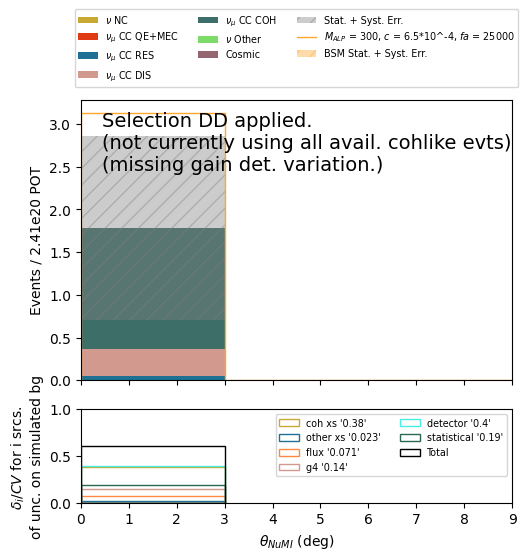

Total number of (POT-normalized) simulated background events in plot: '1.78'
Total uncertainty on simulated background events in plot: ±'1.07'
Total number of (POT-normalized) simulated signal events in plot: '3.13'
Total uncertainty on simulated signal events in plot: ±'2.78e-06'


In [20]:
# Theta NuMI with Benchmarked Event Selection
# SIGNAL BOX!

#mccoh_syst_evtdfs=[0]
mccoh_syst_evtdfs = mccoh_detVar_evtdfs
mccoh_dv_vars = [df.Snumi_angle_hybrid_rangeCorrectedMCS*180./math.pi for df in mccoh_detVar_evtdfs]
      
x = makeplot(evtdf, evtdf.Snumi_angle_hybrid_rangeCorrectedMCS*180./math.pi,
         mccoh_syst_evtdfs, mccoh_dv_vars,
         (0,9.), bins=3,
         xlabel = "$\\theta_{NuMI}$ (deg)", detailed_nu="int_type",
         ratio_bounds=[0.,2.], plotname='theta_NuMI',
         textOnPlot = 'Selection DD applied. \n(not currently using all avail. cohlike evts) \n(missing gain det. variation.)',
         bsm_index=7,
         rwt_alp=True,
         fwt_bsm_to_high_prob_bench = False,
         bsm_detector_varis_vars=0,
         bsm_magnifier = 1000,
         evtSel_key='DD',
             do_detector_variations=True  
        )

In [42]:
cut_list = evtSel_dict['DD'][0]
thresholds = evtSel_dict['DD'][1]

cut_results = apply_cuts(evtdf, cut_list, thresholds=thresholds, detailed_nu='int_type', detailed_bsm=True)
pot_df = cut_results[1]
mask = cut_results[-1]


In [19]:
#print('Number of ALP events required for sensitivity for Selection AA, assuming unc_signal=30% and...')
limit_dir = '/exp/icarus/data/users/jdyer/muons_selections_study_2511/wCVwgts/'

print('Number of ALP events that can be excluded with 90% confidence with Selection AA, assuming unc_signal=30% and unc_bg=X.')

exp_limits_AA60 = np.load(limit_dir+'Selection_AA/pyhf_ExpLim_90CL_30uncSig_60uncBg.npy')
#print(exp_limits_AA)
#print(exp_limits_AA*11.)
formatted_arr_str = '[' + ', '.join([f'{x:.2f}' for x in exp_limits_AA60*11.]) + ']'
print('unc_bg=60%: ', formatted_arr_str)

exp_limits_AA75 = np.load(limit_dir+'Selection_AA/pyhf_ExpLim_90CL_30uncSig_75uncBg.npy')
formatted_arr_str = '[' + ', '.join([f'{x:.2f}' for x in exp_limits_AA75*11.]) + ']'
print('unc_bg=75%: ', formatted_arr_str)

exp_limits_AA100 = np.load(limit_dir+'Selection_AA/pyhf_ExpLim_90CL_30uncSig_100uncBg.npy')
formatted_arr_str = '[' + ', '.join([f'{x:.2f}' for x in exp_limits_AA100*11.]) + ']'
print('unc_bg=100%: ', formatted_arr_str)


#print('Number of ALP events required for sensitivity for Selection DD, assuming unc_signal=30% and...')
print('Number of ALP events that can be excluded with 90% confidence with Selection AA, assuming unc_signal=30% and unc_bg=X.')

exp_limits_DD60 = np.load(limit_dir+'Selection_DD/pyhf_ExpLim_90CL_30uncSig_60uncBg.npy')
formatted_arr_str = '[' + ', '.join([f'{x:.2f}' for x in exp_limits_DD60*11.]) + ']'
print('unc_bg=60%: ', formatted_arr_str)

exp_limits_DD75 = np.load(limit_dir+'Selection_DD/pyhf_ExpLim_90CL_30uncSig_75uncBg.npy')
formatted_arr_str = '[' + ', '.join([f'{x:.2f}' for x in exp_limits_DD75*11.]) + ']'
print('unc_bg=75%: ', formatted_arr_str)

exp_limits_DD100 = np.load(limit_dir+'Selection_DD/pyhf_ExpLim_90CL_30uncSig_100uncBg.npy')
formatted_arr_str = '[' + ', '.join([f'{x:.2f}' for x in exp_limits_DD100*11.]) + ']'
print('unc_bg=100%: ', formatted_arr_str)

print('The middle number of each list is the limit we would draw if the number of selected data events perfectly matches our central value expectation of number of selected background events, based on simulation.')
print('The numbers on either side are the limits we would draw if the number of selected data events is +2, +1, -1, or -2 sigma from our central value expectation of the number of selected background events, based on simulation.') 
#      our number of selected simulated background events.')


Number of ALP events that can be excluded with 90% confidence with Selection AA, assuming unc_signal=30% and unc_bg=X.
unc_bg=60%:  [1.10, 1.57, 2.66, 4.98, 9.68]
unc_bg=75%:  [1.10, 1.61, 2.71, 5.07, 9.80]
unc_bg=100%:  [1.12, 1.68, 2.83, 5.23, 10.04]
Number of ALP events that can be excluded with 90% confidence with Selection AA, assuming unc_signal=30% and unc_bg=X.
unc_bg=60%:  [1.65, 2.44, 3.89, 6.88, 12.68]
unc_bg=75%:  [1.78, 2.57, 4.07, 7.09, 12.98]
unc_bg=100%:  [1.98, 2.75, 4.32, 7.44, 13.45]
The middle number of each list is the limit we would draw if the number of selected data events perfectly matches our central value expectation of number of selected background events, based on simulation.
The numbers on either side are the limits we would draw if the number of selected data events is +2, +1, -1, or -2 sigma from our central value expectation of the number of selected background events, based on simulation.


In [28]:
for c in make_categories(evtdf, detailed_bsm=True):
    print(c.name)

$M_S$ = 220, $\theta_S$ = 1e-05
$M_S$ = 240, $\theta_S$ = 1e-05
$M_S$ = 260, $\theta_S$ = 1e-05
$M_S$ = 280, $\theta_S$ = 1e-05
$M_S$ = 300, $\theta_S$ = 1e-05
$M_S$ = 320, $\theta_S$ = 1e-05
$M_S$ = 340, $\theta_S$ = 1e-05
$M_{ALP}$ = 300, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 340, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 350, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 400, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 450, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 500, $c$ = 0.01, $fa$ = '1.0e+06'
$M_{ALP}$ = 540, $c$ = 0.01, $fa$ = '1.0e+06'
$\nu$ NC
$\nu_\mu$ CC QE+MEC
$\nu_\mu$ CC RES
$\nu_\mu$ CC DIS
$\nu_\mu$ CC COH
$\nu$ Other
Cosmic


VERIFY THAT THIS NUMBER IS TWO (1 nominal nu sample, and any number of cohlike samples (whose POTs get combined), for a total of 2 POT scalings):  2
dE/dx <= 50 MeV/cm up to 0_5 cm
dE/dx <= 35 MeV/cm 0_5-1 cm
dE/dx <= 15 MeV/cm 1-2 cm
dE/dx <= 10 MeV/cm 2-3 cm
max shower len < 0.0 cm
contained trk chi2mu < 8
opening angle < 25 deg
shorter of tracks > 100.0 cm


/tmp/ipykernel_2144872/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_2144872/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_2144872/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_2144872/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_2144872/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_2144872/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results

len(unq):  2
$M_{ALP}$ = 400, $c$ = 6.5*10^-4, $fa$ = 25000


/tmp/ipykernel_2144872/1916938800.py:439: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  mc_stat_err = float(df[bsm_cat].iloc[[0]].scale)*np.sqrt(mc_bin_nevents) # TODO_JAN_7: fix to include CV weights, and rwt_to_good_bm


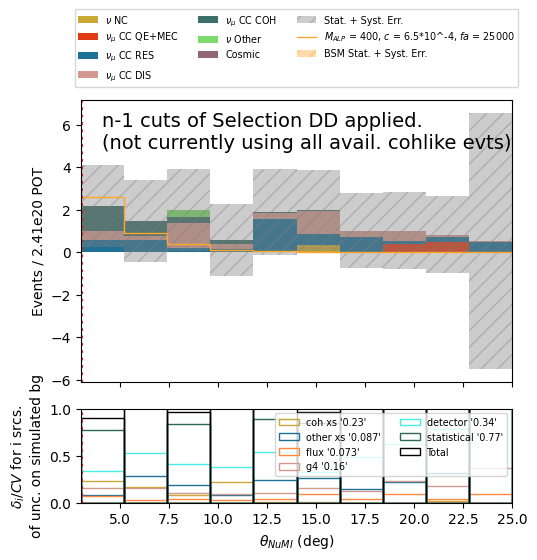

Total number of (POT-normalized) simulated background events in plot: '13.5'
Total uncertainty on simulated background events in plot: ±'8.25'
Total number of (POT-normalized) simulated signal events in plot: '4.09'
Total uncertainty on simulated signal events in plot: ±'4.53e-06'


In [21]:
# Explore Sideband Defined as Flipped theta_NuMI
# Apply all the other cuts, and plot a wider range of theta_NuMI

mccoh_syst_evtdfs = mccoh_detVar_evtdfs
mccoh_dv_vars = [df.Snumi_angle_hybrid_rangeCorrectedMCS*180./math.pi for df in mccoh_detVar_evtdfs]
      
x = makeplot(evtdf, evtdf.Snumi_angle_hybrid_rangeCorrectedMCS*180./math.pi,
             mccoh_syst_evtdfs, mccoh_dv_vars,
             (3,25.), bins=10, vline=[3.],
             xlabel = "$\\theta_{NuMI}$ (deg)", detailed_nu="int_type",
             ratio_bounds=[0.,2.], plotname='theta_NuMI',
             textOnPlot = 'n-1 cuts of Selection DD applied. \n(not currently using all avail. cohlike evts)',
             #textOnPlot = 'Selection J applied. \n(not currently using all avail. cohlike evts)',
             bsm_index=9,
             rwt_alp=True,
             fwt_bsm_to_high_prob_bench = False,
             bsm_detector_varis_vars=0,
             bsm_magnifier = 10000,
             evtSel_key='J',
             do_detector_variations=True, 
             print_cuts = True #, do_subplot = False
            
        )

In [100]:
%%time
cut_list = evtSel_dict['B'][0]
thresholds = evtSel_dict['B'][1]
x = apply_cuts_and_reweight_signal(evtdf, cut_list, thresholds=thresholds,
                                   mccoh_detVar_dfs = mccoh_detVar_evtdfs,
                                   detailed_nu='int_type', detailed_bsm=True)


dE/dx <= 50 MeV/cm up to 0_5 cm
dE/dx <= 35 MeV/cm 0_5-1 cm
dE/dx <= 15 MeV/cm 1-2 cm
dE/dx <= 10 MeV/cm 2-3 cm
max shower len < 0.0 cm
contained trk chi2mu < 8
S_NuMI_angle >= 3 deg
S_NuMI_angle < 10 deg
opening angle > 25 deg
opening angle < 40 deg
contained trk ndaughters >= 0


/tmp/ipykernel_1083756/1442981371.py:124: RuntimeWarning: invalid value encountered in divide
  display_df['MC stat. unc.'] = np.array(stat_unc_by_cat)/np.array(total_POT_normed)
/tmp/ipykernel_1083756/1442981371.py:131: RuntimeWarning: invalid value encountered in divide
  display_df['coh_xs syst.'] = np.array(POT_normed_unc_by_cat_coh)/np.array(total_POT_normed)
/tmp/ipykernel_1083756/1442981371.py:132: RuntimeWarning: invalid value encountered in divide
  display_df['incoh_xs syst.'] = np.array(POT_normed_unc_by_cat_xsec)/np.array(total_POT_normed)
/tmp/ipykernel_1083756/1442981371.py:133: RuntimeWarning: invalid value encountered in divide
  display_df['flux syst.'] = np.array(POT_normed_unc_by_cat_flux)/np.array(total_POT_normed)
/tmp/ipykernel_1083756/1442981371.py:134: RuntimeWarning: invalid value encountered in divide
  display_df['g4 syst.'] = np.array(POT_normed_unc_by_cat_g4)/np.array(total_POT_normed)
/tmp/ipykernel_1083756/1442981371.py:147: RuntimeWarning: invalid value 

POT_normed_unc_by_cat_coh:  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.268285496830951, 0.0, 0.0]
POT_normed_unc_by_cat_xsec:  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.04469697970557485, 1.2972086197276607, 1.5702685717737435, 0.29779660161462035, 0.0, 0.14733354406090796, 0.0]
POT_normed_unc_by_cat_flux:  [1.813008012887164e-07, 3.470438604833983e-05, 0.0001291842621038746, 0.00028465169649063174, 0.0005070050924723758, 0.00035268492310646375, 0.0006433282732340312, 2.5539800886149182e-05, 4.7340090749451794e-05, 5.601111296699607e-05, 0.00011423665251187287, 0.00023501690421616036, 0.000630346851083738, 0.0005765326756139019, 0.00021473877022134424, 0.00018278569877291242, 0.001974124620641867, 0.1170174376999127, 0.14098171559113323, 0.05243646873618255, 0.110050606483972, 0.0820317157071382, 0.0]
POT_normed_unc_by_cat_g4:  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0

/tmp/ipykernel_1083756/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)


dE/dx <= 35 MeV/cm 0_5-1 cm


...

/tmp/ipykernel_1083756/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_1083756/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)


opening angle > 25 deg
opening angle < 40 deg
contained trk ndaughters >= 0
Total detector uncertainty on total bg:  2.4940679725576516
Total Uncertainty on total bg:  4.379795322094863


/tmp/ipykernel_1083756/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_1083756/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)


,# MC events,POT normed,"POT normed, rwt to $f_a$=5000, $c_\mu$=0.0004930866779987364",MC stat. unc.,coh_xs syst.,incoh_xs syst.,flux syst.,g4 syst.,detector syst.,Total unc.
"$M_S$ = 220, $\theta_S$ = 1e-05",1.0,0.000002,2.024702e-06,1.000000,0.000000,0.000000,0.089544,0.000000,0.217413,1.004001
"$M_S$ = 240, $\theta_S$ = 1e-05",42.0,0.000411,4.106125e-04,0.157893,0.000000,0.000000,0.084519,0.000000,0.217413,0.179091
"$M_S$ = 260, $\theta_S$ = 1e-05",74.0,0.001515,1.514637e-03,0.119140,0.000000,0.000000,0.085291,0.000000,0.217413,0.146522
"$M_S$ = 280, $\theta_S$ = 1e-05",103.0,0.004747,4.746805e-03,0.100255,0.000000,0.000000,0.059967,0.000000,0.217413,0.116821
"$M_S$ = 300, $\theta_S$ = 1e-05",257.0,0.007913,7.913011e-03,0.063326,0.000000,0.000000,0.064072,0.000000,0.217413,0.090086
"$M_S$ = 320, $\theta_S$ = 1e-05",301.0,0.007428,7.428128e-03,0.058469,0.000000,0.000000,0.047480,0.000000,0.217413,0.075319
"$M_S$ = 340, $\theta_S$ = 1e-05",412.0,0.006264,6.264302e-03,0.050156,0.000000,0.000000,0.102698,0.000000,0.217413,0.114291
"$M_{ALP}$ = 300, $c$ = 0.01, $fa$ = '1.0e+06'",150.0,0.000023,5.940435e-01,0.082482,0.000000,0.000000,1.124248,0.000000,0.217413,1.127270
"$M_{ALP}$ = 350, $c$ = 0.01, $fa$ = '1.0e+06'",225.0,0.000046,2.961997e+00,0.067132,0.000000,0.000000,1.028150,0.000000,0.217413,1.030339
"$M_{ALP}$ = 400, $c$ = 0.01, $fa$ = '1.0e+06'",240.0,0.000078,5.471850e+01,0.064727,0.000000,0.000000,0.721650,0.000000,0.217413,0.724547


CPU times: user 2min 50s, sys: 2 s, total: 2min 52s
Wall time: 2min 53s


In [22]:
# Cuts

def keep_many_daughters(df, thresh = 1): # 'thresh' is max_allowed per contained track
    mask = df.conTrk_nDaughters >= thresh
    return mask, 'contained trk ndaughters >= %a' % thresh
def open_angle_gt(df, thresh = 0.): # 'thresh' is max_allowed per contained track
    mask = np.arccos(dotdf(df.trunk.trk.dir, df.branch.trk.dir)) > thresh*math.pi/180.
    return mask, 'opening angle > %a deg' % thresh
def numi_angle_hybrid_mcsCorr_mask_gt(df, thresh = 3.):
    return numi_angle_hybrid_mcsCorr_mask(df, thresh = NuMI_angle_thresh, flip=True)    

evtSel_dict = dict([
    
    # check mc sideband in theta_NuMI:
    ( "J", # n-1 cuts for DD.
     ( # tuple of cut list and thresholds
        [ # cut list
            not_stub_05, not_stub_1, not_stub_2, not_stub_3,
            max_shw_len_mask,
            ok_chi2mu_contained,
            open_angle_mask, # corrected this from numi_angle_mcsCorr_mask October 31, 2025
            shortTrk_len_mask
        ],
        [ # thresholds
            50, 35, 15, 10,
            0.0,
            8,
            25,
            100.0
        ]
     )
    ),
    
    ( "DD", # Same as AA, but loosen opening angle cut.
     ( # tuple of cut list and thresholds
        [ # cut list
            not_stub_05, not_stub_1, not_stub_2, not_stub_3,
            max_shw_len_mask,
            ok_chi2mu_contained,
            numi_angle_hybrid_mcsCorr_mask, open_angle_mask, # corrected this from numi_angle_mcsCorr_mask October 31, 2025
            shortTrk_len_mask
        ],
        [ # thresholds
            50, 35, 15, 10,
            0.0,
            8,
            3, 25,
            100.0
        ]
     )
    ), 
    
    ( "A", 
     ( # tuple of cut list and thresholds
        [ # cut list
            not_stub_05, not_stub_1, not_stub_2, not_stub_3,
            max_shw_len_mask,
            ok_chi2mu_contained,
            numi_angle_hybrid_mcsCorr_mask, open_angle_mask, # corrected this from numi_angle_mcsCorr_mask October 31, 2025
            shortTrk_len_mask, 
            keep_many_daughters
        ],
        [ # thresholds
            50, 35, 15, 10,
            0.0,
            8,
            3, 25,
            100.0, 
            1
        ]
     )
    ), 
    
    ( "B", # target cohlikes
     ( # tuple of cut list and thresholds
        [ # cut list
            not_stub_05, not_stub_1, not_stub_2, not_stub_3,
            max_shw_len_mask,
            ok_chi2mu_contained,
            numi_angle_hybrid_mcsCorr_mask_gt, numi_angle_hybrid_mcsCorr_mask, 
            open_angle_gt, open_angle_mask, 
            keep_many_daughters,
            #ndaughters_per_conTrk
        ],
        [
            50, 35, 15, 10,
            0.0,
            8,
            3, 10, 
            15, 40, 
            1,
            #-1
        ]
     )
    )

])
                           

### Plotting function to play with fits (no subplot; stack the signal on top of BG)

In [21]:
saveplots = False
plotdir = '/exp/icarus/data/users/jdyer/muon_datamc/plots/'
def makeplot_toFit(df, var, 
             syst_evtdfs, syst_vars, 
             myrange, xlabel = 'x axis', bins = 25, vline=None, detailed_nu='int_type', do_systs=True,
             POTSTR=POTSTR, title=None, ratio_bounds=None, plotname='noname', ylabel=None,
             textOnPlot = '', 
             bsm_index=None, bsm_detector_varis_vars=[], bsm_magnifier=1, fwt_bsm_to_high_prob_bench = False,
             rwt_alp = False,
             evtSel_key=None, 
             do_detector_variations=True,
             subplot='percent', 
             do_subplot = True, 
             print_cuts = False
            ): # , [-1,3]
    # options for 'detailed_mc' are: 'int_type', 'cd /exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-toolsfinal_state', 'none'
    # df: concatenation of mccoh, mcincoh, and bsm evt_dfs (data to come later)
    # var: corresponds to 'df' variable
    # syst_evtdfs: for the cohlike events and bsm
    # syst_vars: correspond to the 'syst_evtdfs'
    
    do_detector_variations_signal = False
    
    if bsm_index is not None:
        if do_detector_variations_signal:
            assert len(bsm_detector_varis_vars)>0, 'You need to provide the signal detector variation sample vars!'
        categories = make_categories(df, detailed_nu = detailed_nu, detailed_bsm=True)
        bsm_cats = [c for c in categories if c.mc_signal]
        bsm_cat = bsm_cats[bsm_index]
        bsm_df = df[bsm_cat]
        bsm_var = var[bsm_cat]
        if do_detector_variations_signal:
            bsm_syst_evtdfs = bsm_detector_varis_dfs[bsm_index]
            bsm_syst_vars = bsm_detector_varis_vars[bsm_index]
    
    mc_evtdf = df[df.mc & ~df.bsm]
    mc_var = var[df.mc & ~df.bsm]
    unq = np.unique(np.array(mc_evtdf.scale))
    print('VERIFY THAT THIS NUMBER IS TWO (1 nominal nu sample, and any number of cohlike samples (whose POTs get combined), for a total of 2 POT scalings): ', len(mc_evtdf.scale.unique())) # len(unq)) # for the cohlike and nominal samples (later there will be more cohlikes).
    
    # first apply event selection, if applicable:
    if evtSel_key is not None:
        cut_list = evtSel_dict[evtSel_key][0]
        thresholds = evtSel_dict[evtSel_key][1]
        
        # df, var:
        cut_results = apply_cuts(df, cut_list, thresholds=thresholds, detailed_nu='none', print_cuts=print_cuts)
        mask = cut_results[-1]
        df, var = df[mask], var[mask]
        #print('selected_evtdf.shape: ', df.shape)

        
        if do_detector_variations:
            # cohlike detector variations df, cohlike detector variations var
            new_syst_evtdfs, new_syst_vars = [], []
            for d, systdf in enumerate(syst_evtdfs):
                #print('systdf: \n', systdf)
                cut_results = apply_cuts(systdf, cut_list, thresholds=thresholds, detailed_nu='none', make_pretty_dfs=False)
                mask = cut_results[-1]
                new_syst_evtdfs.append(systdf[mask])
                new_syst_vars.append(syst_vars[d][mask])
            syst_evtdfs, syst_vars = new_syst_evtdfs, new_syst_vars
        
        # bsm detector variations df, bsm detector variations var
        if bsm_index is not None:
            cut_results = apply_cuts(bsm_df, cut_list, thresholds=thresholds, detailed_nu='none')
            mask = cut_results[-1]
            bsm_df = bsm_df[mask]
            bsm_var = bsm_var[mask]
        
            if do_detector_variations_signal:
                new_bsm_syst_evtdfs = []
                new_bsm_syst_vars = []
                for i, detector_variation in enumerate(bsm_syst_evtdfs):
                    cut_results = apply_cuts(detector_variation, cut_list, thresholds=thresholds, detailed_nu='none')
                    mask = cut_results[-1]
                    new_bsm_syst_evtdfs.append(detector_variation[mask])
                    new_bsm_syst_vars.append(bsm_syst_vars[i][mask])
                bsm_syst_evtdfs = new_bsm_syst_evtdfs 
                bsm_syst_vars = new_bsm_syst_vars
    
    mydensity = False

    scale = df.scale.copy()
    #var[np.isnan(var) | (var < 0)] = -10
    var[np.isnan(var)] = -10
    
    if bsm_index is not None:
        categories = make_categories(df, detailed_nu = detailed_nu, detailed_bsm=True)
    else:
        categories = make_categories(df, detailed_nu = detailed_nu)  
    
    # DATA
    # (ignoring data for now.)
    
    # BG MC
    if detailed_nu == 'none': histtype_str = 'step'
    else: histtype_str = 'bar'
    _ = plt.hist([var[cat] for cat in categories if cat.mc_bg], #[:-2]], 
                weights = [df[cat].scale*df[cat].wgt.cv.tot for cat in categories if cat.mc_bg], #[:-2]], 
                color=[cat.color for cat in categories if cat.mc_bg], #[:-2]],
                label=[cat.name for cat in categories if cat.mc_bg], #[:-2]],
                bins=bins, density=mydensity, histtype=histtype_str, stacked=True, range=myrange)
    returned_bins = _[1]
    bin_centers = 0.5*(returned_bins[1:] + returned_bins[:-1])
    try: mc = _[0][-1,:] # np.sum(np.array(_[0]), axis=0)
    except IndexError: mc = _[0]
    total_mc_bg_in_plot = np.sum(mc)
    mc_bin_nevents = []
    
    mc_evtdf = df[df.mc & ~df.bsm]
    mc_var = var[df.mc & ~df.bsm]
    unq = np.unique(np.array(mc_evtdf.scale))
    print('len(unq): ', len(unq))
    
    # BG MC STATISTICAL
    # TODO 25/12/09: ADD THE CV WEIGHTS INTO THIS SECTION! 
    
    consider_only_data_in_plot = True
    if consider_only_data_in_plot:
        in_range_mask = ((mc_var>= myrange[0]) & (mc_var< myrange[1]))
        mc_stat_err = np.sqrt(np.sum((mc_evtdf[in_range_mask].scale*mc_evtdf[in_range_mask].wgt.cv.tot)**2))
    else:
        mc_stat_err = np.sqrt(np.sum((mc_evtdf.scale*mc_evtdf.wgt.cv.tot)**2))
    #print('mc_evtdf.shape: ', mc_evtdf.shape)
    #print('mc_stat_err: ', mc_stat_err)
    # Note: This way, implemented 12/11/25, considers both POT and cv weights, but it gets the total statistical uncertainty,
    #       not the stat. uncertainty by bin. This is fine for when I just plot signal box with one bin. But may create
    #       confusion for other plots (or possibly problems due to a mismatch in the length of this unc. and other uncs.)
        
    # BG MC SYSTEMATICS
    if do_systs:
        
        # UNIVERSE SYSTS - these include multi-sigma, multi-sim, and morph type systematic uncertainties.
        # JUNE 5, '25 TODO: "all" --> #coh, #xsec, #flux, #g4
        
        # ~~~~~~ SUM OVER UNIVERSES.
        
        # ~~ separate (#coh, #xsec, #flux, #g4)
        universe_contributions = ["coh", "xsec", "flux", "g4"]
        universe_contributions_use_in_plot = ["coh xs", "other xs", "flux", "g4"]
        coh_weighted_hists = []
        xsec_weighted_hists = []
        flux_weighted_hists = []
        g4_weighted_hists = []
        universe_weighted_hists = [coh_weighted_hists, xsec_weighted_hists, flux_weighted_hists, g4_weighted_hists]
        universe_covs = []
        for uc, uni_cont in enumerate(universe_contributions):
            for col in mc_evtdf.wgt[uni_cont].columns:
                if not col[0].startswith("univ"): continue
                #hsyst_weights.append(histf(mc_evtdf.wgt["all"][col]))
                new_weighted_hist = plt.hist(
                    mc_var, 
                    weights = mc_evtdf.scale*mc_evtdf.wgt.cv.tot*mc_evtdf.wgt[uni_cont][col],
                    bins=bins, alpha=0, density=mydensity, range=myrange
                )
                universe_weighted_hists[uc].append(new_weighted_hist[0])
            hcov = None
            # average over Universe (each Universe has a bunch of weights-based uncertainties in it)
            for i in range(len(universe_weighted_hists[uc])):
                thiscov = np.outer( mc - universe_weighted_hists[uc][i] , mc - universe_weighted_hists[uc][i] )
                if hcov is None:
                    hcov = thiscov
                else:
                    hcov += thiscov
            universe_covs.append(hcov/len(universe_weighted_hists[uc]))
        coh_cov = universe_covs[0]
        xsec_cov = universe_covs[1]
        flux_cov = universe_covs[2]
        g4_cov = universe_covs[3]
        
        ## ~~~~~~
                
        # BG MC DETECTOR SYSTEMATICS
        
        cohlike_hist = plt.hist(mc_var[is_coh_like_JD(mc_evtdf)], #df["mccoh"]==True],
                                weights = mc_evtdf[is_coh_like_JD(mc_evtdf)].scale * mc_evtdf[is_coh_like_JD(mc_evtdf)].wgt.cv.tot,
                                bins=bins, alpha=0, density=mydensity, range=myrange)

        #frac_cohlike = (mccoh_evt.shape[0]*GOAL_POT/mccoh_hdr_pot) / ( (mc_incoh_evt.shape[0]*GOAL_POT/mc_incoh_pot) +  (mccoh_evt.shape[0]*GOAL_POT/mccoh_hdr_pot) )
        frac_cohlike_bybin = np.array(cohlike_hist[0]/mc)
        #print('frac_cohlike_bybin: ', frac_cohlike_bybin)
        
        if do_detector_variations:
        
            detsyst_hists = []
            # TODO: double check that I am not incorrectly including cosmics from my detector variation samples.
            for s, mc_detsyst_var in enumerate(syst_vars):
                #mc_detsyst_var = sdf.Snumi_angle_mcs*180./math.pi # TODO: generalize this to any var.
                new_detsyst_hist = plt.hist(
                    mc_detsyst_var, 
                    weights = syst_evtdfs[s].scale*syst_evtdfs[s].wgt.cv.tot,
                    #weights = sdf.scale, 
                    bins=bins, alpha=0, density=mydensity, range=myrange
                )
                detsyst_hists.append(new_detsyst_hist[0]/frac_cohlike_bybin)
                    
            # Middle Induction Transparency:
            middle_ind_cov = np.outer( mc - detsyst_hists[0] , mc - detsyst_hists[0] )        
            # Noise High:
            noise_hi_cov = np.outer( mc - detsyst_hists[1] , mc - detsyst_hists[1] )
            # Space Charge Effect x2:
            sce_cov = np.outer( mc - detsyst_hists[2] , mc - detsyst_hists[2] )
            # Ind 0 Nom (?): # changing signal shapes on front induction to Wire Cell nominal. Our nominal (default) is garfield.
            # signal shape simulation is in wire cell (so is 2D convolution, but rn we do 1d deconv. which is not using Wire Cell.)
            ind0nom_cov = np.outer( mc - detsyst_hists[3] , mc - detsyst_hists[3] )
            ## Gain: (missing as of December 4 - sample is in progress thanks to Gray!)
            front_ind_gain_cov = np.outer(np.array([0]*len(mc)), np.array([0]*len(mc)))
            
            detector = np.sqrt( np.diag(middle_ind_cov)  
                               + np.diag(noise_hi_cov) + np.diag(sce_cov) + np.diag(ind0nom_cov) 
                               + np.diag(front_ind_gain_cov)
                              )
      
            yerr_syst_total = np.sqrt(np.diag(coh_cov) + np.diag(xsec_cov) + np.diag(flux_cov) + np.diag(g4_cov) +
                                      detector**2
                                     )
                                      #np.diag(middle_ind_cov) + np.diag(front_ind_gain_cov) 
                                      #+ np.diag(noise_hi_cov) + np.diag(sce_cov) + np.diag(ind0nom_cov))
        else:
            yerr_syst_total = np.sqrt(np.diag(coh_cov) + np.diag(xsec_cov) + np.diag(flux_cov) + np.diag(g4_cov))
                                      
        #print('Combined result minus separate result: \n', yerr_syst_total_combine_all_SimErrs - yerr_syst_total)
        
        
    # BG TOTAL MC UNCERTAINTY
        
    if do_systs:
        mc_err = np.sqrt(mc_stat_err**2 + yerr_syst_total**2)
        mc_err_label = 'Stat. + Syst. Err.'
            
    else:
        mc_err = mc_stat_err
        mc_err_label = 'Stat. Err.'
    #print('mc_stat_err: ', mc_stat_err)
    #print('mc syst. err: ', yerr_syst_total)
    #print('mc_err: ', mc_err)
    total_mc_bg_err_in_plot = np.sqrt(np.sum((mc_err[np.isfinite(mc_err)])**2))
        
    #print('mc: ', mc)
    mc_minus_err = np.append((mc - mc_err), 0.)
    mc_minus_err[np.isnan(mc_minus_err)] = 0.
    mc_plus_err = np.append((mc + mc_err), 0.)
    mc_plus_err[np.isnan(mc_plus_err)] = 0.
    plt.stairs(mc, returned_bins, color='black', label='Total BG') 
    fill = plt.fill_between(returned_bins, mc_minus_err, mc_plus_err, step="post", hatch="//", label = 'BG '+mc_err_label, edgecolor="gray", facecolor="gray", alpha=0.4, linewidth=0) #label = 'MC Total Uncertainty', hatch="x", color="gray", alpha=0.5, 
    bg_mc = mc
    bg_mc_err = mc_err
    bg_mc_minus_err = mc_minus_err
    bg_mc_plus_err = mc_plus_err
    bg_mc_err_label = mc_err_label
    
    #print('MC EVENTS IN PLOT (w/ Normalization): ', np.sum(mc))
    #print('DATA/MC IN PLOT (w/ Normalization): ', np.sum(data)/np.sum(mc) )

    #print('bin boundaries:')
    #print(onbeam_data[1][:-1])
    ###
    
    ## CHI-SQUARED

    #okay_denom = (data_err**2 + mc_err**2)>0
    #ndof = (data_err**2 + mc_err**2)[okay_denom].shape[0]
    #chi2 = np.sum( ((mc-data)[okay_denom])**2/(data_err**2 + mc_err**2)[okay_denom] ) # denominator is total error squared.
    #howgood = chi2/ndof
    #print( 'chi2 over n = %a' % howgood )
    ##if xs != None:
    ##    p0.text(xs[0], xs[1], "$\\chi^2/n$ = %.3f / %i" % (chi2, ndof), fontsize=14)#, transform=plt.transAxes)
    
        ###################
    
    # SIGNAL
    
    # Note: df[bsm_cat] and bsm_df are the same thing. var[bsm_cat] and bsm_var are the same thing.
    if bsm_index is not None:
        bsm_color = "#FF00FF"
        if (rwt_alp) and ('ALP' in bsm_cat.name):
            if fwt_bsm_to_high_prob_bench:
                sig_wgts_list = [bsm_df.scale*bsm_df.wgt.cv.tot*bsm_df.rwt_to_edge_alp_bm,
                                 bsm_df.scale*bsm_df.wgt.cv.tot*bsm_df.rwt_to_good_alp_bm
                                ]
            else:
                sig_wgts_list = [bsm_df.scale*bsm_df.wgt.cv.tot*bsm_df.rwt_to_edge_alp_bm]
            bsm_magnifier = 1. 
            #print('apple')
        else: 
            sig_wgts_list = [bsm_df.scale*bsm_df.wgt.cv.tot]
            bsm_label = bsm_cat.name + ' X' + str(bsm_magnifier)
            #print('banana')
            
        for s, sig_wgts in enumerate(sig_wgts_list):
            if rwt_alp:
                #print('orange')
                if s==0: 
                    bsm_color = '#ffa62b'
                    bsm_label = bsm_cat.name.split(',')[0]+', $c$ = 6.5*10^-4, $fa$ = 25000'
                    #print('grape')
                else:
                    bsm_color = "#FF00FF"
                    bsm_label = bsm_cat.name.split(',')[0]+', $c$ = 4.9*10^-4, $fa$ = 5000'
                    #print('kiwi')
            
            print(bsm_label)
            _ = plt.hist(var[bsm_cat], 
                        weights = sig_wgts,
                        bins=bins, density=mydensity, histtype='step', range=myrange, alpha=0)
            mc = _[0]
            mc_signal = mc
            #print('signal mc: ', mc) 
            combined_sig_bg = mc*bsm_magnifier+bg_mc
            plt.stairs(combined_sig_bg, _[1], color=bsm_color, label = 'BG + '+bsm_label)
                
            # SIGNAL MC STATISTICAL
            mc_bin_nevents = np.array(plt.hist(var[bsm_cat], bins=bins, alpha=0, density=False, range=myrange)[0])
            mc_stat_err = float(df[bsm_cat].iloc[[0]].scale)*np.sqrt(mc_bin_nevents) # TODO_JAN_7: fix to include CV weights, and rwt_to_good_bm
        
            # SIGNAL MC SYSTEMATICS
            if do_systs:
                # UNIVERSE SYSTS - these include multi-sigma, multi-sim, and morph type systematic uncertainties.
                weighted_hists = []
                for col in bsm_df.wgt["all"].columns:
                    if not col[0].startswith("univ"): continue
                    new_weighted_hist = plt.hist(
                        bsm_var, 
                        weights = sig_wgts*bsm_df.wgt["all"][col],
                        bins=bins, alpha=0, density=mydensity, range=myrange
                    )
                    weighted_hists.append(new_weighted_hist[0])        
                hcov = None
                # average over Universe (each Universe has a bunch of weights-based uncertainties in it)
                for i in range(len(weighted_hists)):
                    thiscov = np.outer( mc - weighted_hists[i] , mc - weighted_hists[i] )
                    if hcov is None:
                        hcov = thiscov
                    else:
                        hcov += thiscov
                Universe_cov = hcov / len(weighted_hists)      
        
            if do_detector_variations_signal:
                # SIGNAL MC DETECTOR SYSTEMATICS
        
                # get histrograms for each of the BSM detector variation samples, excluding the cosmics from those samples.
                bsm_detsyst_hists = []
                for s, bsm_syst_var in enumerate(bsm_syst_vars):
                    no_cosmics_mask = make_categories(bsm_syst_evtdfs[s])[0]
                    print('bsm_syst_var[no_cosmics_mask]: ', np.max(bsm_syst_var[no_cosmics_mask]))
                    new_detsyst_hist = plt.hist(
                        bsm_syst_var[no_cosmics_mask], 
                        weights = bsm_syst_evtdfs[s][no_cosmics_mask].scale*bsm_syst_evtdfs[s][no_cosmics_mask].wgt.cv.tot,
                        bins=bins, alpha=0, density=mydensity, range=myrange
                    )
                bsm_detsyst_hists.append(new_detsyst_hist[0])
                    
                # Middle Induction Transparency:
                middle_ind_cov = ( np.outer( mc - bsm_detsyst_hists[0] , mc - bsm_detsyst_hists[0] ) + np.outer( mc - bsm_detsyst_hists[1] , mc - bsm_detsyst_hists[1] ) )/2.        
                # Front Induction Gain:
                front_ind_gain_cov = ( np.outer( mc - bsm_detsyst_hists[2] , mc - bsm_detsyst_hists[2] ) + np.outer( mc - bsm_detsyst_hists[3] , mc - bsm_detsyst_hists[3] ) )/2.        
                # Noise High:
                noise_hi_cov = np.outer( mc - bsm_detsyst_hists[4] , mc - bsm_detsyst_hists[4] )        
                # Space Charge Effect x2:
                sce_cov = np.outer( mc - bsm_detsyst_hists[5] , mc - bsm_detsyst_hists[5] )        
                # Ind 0 Nom (?): # changing signal shapes on front induction to Wire Cell nominal. Our nominal (default) is garfield.
                # signal shape simulation is in wire cell (so is 2D convolution, but rn we do 1d deconv. which is not using Wire Cell.)
                ind0nom_cov = np.outer( mc - bsm_detsyst_hists[6] , mc - bsm_detsyst_hists[6] )
        
                # SIGNAL MC TOTAL SYST ERROR:
                yerr_syst_total = np.sqrt(np.diag(Universe_cov)+ 
                                          np.diag(middle_ind_cov) + np.diag(front_ind_gain_cov) 
                                          + np.diag(noise_hi_cov) + np.diag(sce_cov) + np.diag(ind0nom_cov))
            else:
                yerr_syst_total = np.sqrt(np.diag(Universe_cov))
                
            # SIGNAL TOTAL MC UNCERTAINTY
            if do_systs:
                mc_err = np.sqrt(mc_stat_err**2 + yerr_syst_total**2)
                mc_err_label = 'Stat. + Syst. Err.'     
            else:
                mc_err = mc_stat_err
                mc_err_label = 'Stat. Err.'
            mc_signal_err = mc_err    
            mc_minus_err = np.append((mc - mc_err)*bsm_magnifier, 0.)
            mc_plus_err = np.append((mc + mc_err)*bsm_magnifier, 0.)
            #mc_err_label = mc_err_label + ' X' + str(bsm_magnifier)
            
            mc_minus_err[np.isnan(mc_minus_err)] = 0.
            mc_plus_err[np.isnan(mc_plus_err)] = 0.
            #fill = plt.fill_between(returned_bins, mc_minus_err, mc_plus_err, step="post", hatch="//", 
                                   #label = 'BSM ' + mc_err_label, # + ' X' + str(bsm_magnifier), 
                                   #edgecolor=bsm_color, facecolor=bsm_color, alpha=0.4, linewidth=0) #label = 'MC Total Uncertainty', hatch="x", color="gray", alpha=0.5, 
            
            combined_mc_err = np.sqrt(mc_err*mc_err*bsm_magnifier*bsm_magnifier + bg_mc_err*bg_mc_err)
            combined_mc_plus_err = np.append((combined_sig_bg + combined_mc_err), 0.)
            combined_mc_minus_err = np.append((combined_sig_bg - combined_mc_err), 0.)
            fill = plt.fill_between(returned_bins, combined_mc_minus_err, combined_mc_plus_err, step="post", hatch="//", 
                                    label = 'BSM + BG Err.',
                                    edgecolor=bsm_color, facecolor=bsm_color, alpha=0.4, linewidth=0) #label = 'MC Total Uncertainty', hatch="x", color="gray", alpha=0.5, 
            
    
    ###################
    
    
    # GENERAL PLOTTING TOOLS
    
    ##plt.legend()
    if title is not None:
        plt.title(title)
    plt.xlabel(xlabel)
    if ylabel is not None:
        plt.ylabel(ylabel+" / %s" % POTSTR)
    else:
        plt.ylabel("Events / %s" % POTSTR)
    
    
    #plt.yscale("log")
    if (vline is not None):
        for line in vline:
            plt.axvline([line], linestyle=":", color="r", linewidth=2)
    #plt.axvline([NuMI_angle_thresh], linestyle=":", color="r", linewidth=2)
    #plt.text(0.6, 0.4, textOnPlot, transform=plt.gca().transAxes, fontsize=18)
    plt.tight_layout()
    plt.xlim(myrange)
    plt.ylim((0,1.8*np.max(mc*bsm_magnifier)))
    plt.legend(ncol=2)
    
    #box = ax.get_position()
    #ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
    #ax.legend(loc = 'center left', bbox_to_anchor=(1, 0.5))
    
    
    #p0.text(0.05, 0.96, textOnPlot, fontsize=14, transform=p0.transAxes, verticalalignment="top")
    
    #p0.text(0.64, 0.96, "ICARUS Data", fontsize=14,
    #        transform=p0.transAxes, verticalalignment="top")
    #p0.text(0.64, 0.81, "$\\chi^2/n$ = %.1f/%i" % (chi2, ndof), fontsize=12, transform=p0.transAxes)#

    if saveplots: plt.savefig(plotdir + plotname + ".png", format='png', bbox_inches='tight')
    plt.show()
    
    print('Total number of (POT-normalized) simulated background events in plot: %a' % f"{np.sum(total_mc_bg_in_plot):.{3}g}")
    print('Total uncertainty on simulated background events in plot: ±%a' % f"{total_mc_bg_err_in_plot:.{3}g}")
    print('Total number of (POT-normalized) simulated signal events in plot: %a' % f"{np.sum(mc):.{3}g}")
    print('Total uncertainty on simulated signal events in plot: ±%a' % f"{np.sqrt(np.sum(mc_err**2)):.{3}g}")
    return(total_mc_bg_err_in_plot,
           returned_bins,
           bg_mc,
           bg_mc_err,
           combined_sig_bg,
           combined_mc_err, 
           mc_signal,
           mc_signal_err
           
          )
    #return hsyst, cov
    ##return uncertainties_by_bin, uncertainties_labels, bin_centers, 

VERIFY THAT THIS NUMBER IS TWO (1 nominal nu sample, and any number of cohlike samples (whose POTs get combined), for a total of 2 POT scalings):  2


/tmp/ipykernel_2046553/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_2046553/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_2046553/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_2046553/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_2046553/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_2046553/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results

len(unq):  2


/tmp/ipykernel_2046553/1800830918.py:181: RuntimeWarning: invalid value encountered in divide
  frac_cohlike_bybin = np.array(cohlike_hist[0]/mc)
/tmp/ipykernel_2046553/1800830918.py:314: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  mc_stat_err = float(df[bsm_cat].iloc[[0]].scale)*np.sqrt(mc_bin_nevents) # TODO_JAN_7: fix to include CV weights, and rwt_to_good_bm


$M_{ALP}$ = 300, $c$ = 6.5*10^-4, $fa$ = 25000


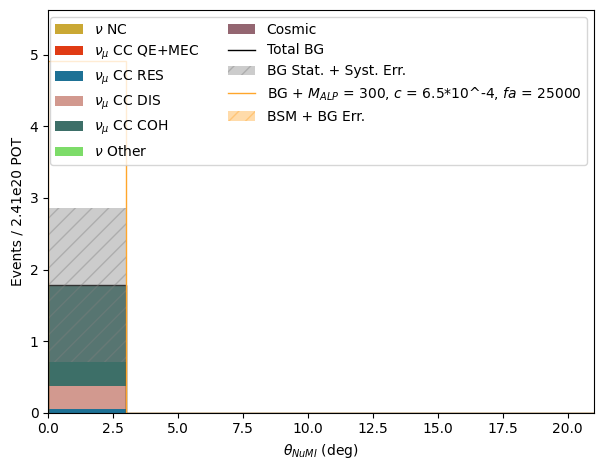

Total number of (POT-normalized) simulated background events in plot: '1.78'
Total uncertainty on simulated background events in plot: ±'1.07'
Total number of (POT-normalized) simulated signal events in plot: '3.13'
Total uncertainty on simulated signal events in plot: ±'2.78e-06'


In [72]:
# Theta NuMI with Benchmarked Event Selection
# SIGNAL BOX!

#mccoh_syst_evtdfs=[0]
mccoh_syst_evtdfs = mccoh_detVar_evtdfs
mccoh_dv_vars = [df.Snumi_angle_hybrid_rangeCorrectedMCS*180./math.pi for df in mccoh_detVar_evtdfs]
      
x = makeplot_toFit(evtdf, evtdf.Snumi_angle_hybrid_rangeCorrectedMCS*180./math.pi,
         mccoh_syst_evtdfs, mccoh_dv_vars,
         (0,21.), bins=7,
         xlabel = "$\\theta_{NuMI}$ (deg)", detailed_nu="int_type",
         ratio_bounds=[0.,2.], plotname='theta_NuMI',
         textOnPlot = 'Selection DD applied. \n(not currently using all avail. cohlike evts) \n(missing gain det. variation.)',
         bsm_index=7,
         rwt_alp=True,
         fwt_bsm_to_high_prob_bench = False,
         bsm_detector_varis_vars=0,
         bsm_magnifier = 1, #1000
         evtSel_key='DD',
             do_detector_variations=True  
        )

VERIFY THAT THIS NUMBER IS TWO (1 nominal nu sample, and any number of cohlike samples (whose POTs get combined), for a total of 2 POT scalings):  2
dE/dx <= 50 MeV/cm up to 0_5 cm
dE/dx <= 35 MeV/cm 0_5-1 cm
dE/dx <= 15 MeV/cm 1-2 cm
dE/dx <= 10 MeV/cm 2-3 cm
max shower len < 0.0 cm
contained trk chi2mu < 8
opening angle < 25 deg
shorter of tracks > 100.0 cm


/tmp/ipykernel_3648118/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_3648118/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_3648118/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_3648118/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_3648118/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_3648118/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results

len(unq):  2
$M_{ALP}$ = 400, $c$ = 6.5*10^-4, $fa$ = 25000


/tmp/ipykernel_3648118/2366833809.py:315: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  mc_stat_err = float(df[bsm_cat].iloc[[0]].scale)*np.sqrt(mc_bin_nevents) # TODO_JAN_7: fix to include CV weights, and rwt_to_good_bm


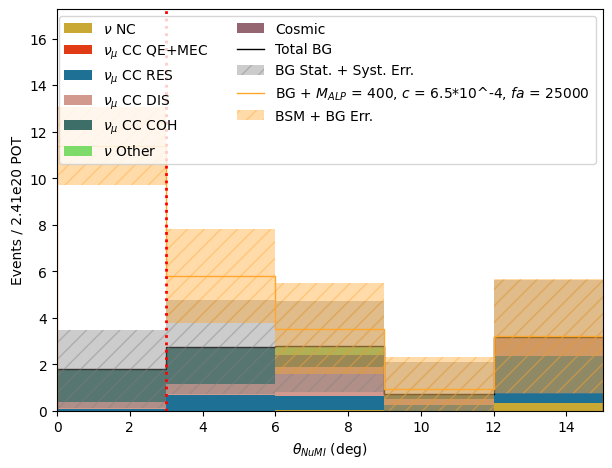

Total number of (POT-normalized) simulated background events in plot: '11.2'
Total uncertainty on simulated background events in plot: ±'4.3'
Total number of (POT-normalized) simulated signal events in plot: '13.7'
Total uncertainty on simulated signal events in plot: ±'8.28e-06'


In [22]:
# SIDEBAND AND SIGNAL BOX!

mccoh_syst_evtdfs = mccoh_detVar_evtdfs
mccoh_dv_vars = [df.Snumi_angle_hybrid_rangeCorrectedMCS*180./math.pi for df in mccoh_detVar_evtdfs]

x = makeplot_toFit(evtdf, evtdf.Snumi_angle_hybrid_rangeCorrectedMCS*180./math.pi,
             mccoh_syst_evtdfs, mccoh_dv_vars,
             (0,15.), bins=5, vline=[3.],
             xlabel = "$\\theta_{NuMI}$ (deg)", detailed_nu="int_type",
             ratio_bounds=[0.,2.], plotname='theta_NuMI',
             textOnPlot = 'n-1 cuts of Selection DD applied. \n(not currently using all avail. cohlike evts)',
             #textOnPlot = 'Selection J applied. \n(not currently using all avail. cohlike evts)',
             bsm_index=9,
             rwt_alp=True,
             fwt_bsm_to_high_prob_bench = False,
             bsm_detector_varis_vars=0,
             bsm_magnifier = 10000,
             evtSel_key='J',
             do_detector_variations=True, 
             print_cuts = True #, do_subplot = False
            
        )
x_400 = x

VERIFY THAT THIS NUMBER IS TWO (1 nominal nu sample, and any number of cohlike samples (whose POTs get combined), for a total of 2 POT scalings):  2
dE/dx <= 50 MeV/cm up to 0_5 cm
dE/dx <= 35 MeV/cm 0_5-1 cm
dE/dx <= 15 MeV/cm 1-2 cm
dE/dx <= 10 MeV/cm 2-3 cm
max shower len < 0.0 cm
contained trk chi2mu < 8
opening angle < 25 deg
shorter of tracks > 100.0 cm


/tmp/ipykernel_3648118/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_3648118/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_3648118/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_3648118/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_3648118/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_3648118/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results

len(unq):  2
$M_{ALP}$ = 300, $c$ = 6.5*10^-4, $fa$ = 25000


/tmp/ipykernel_3648118/2366833809.py:315: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  mc_stat_err = float(df[bsm_cat].iloc[[0]].scale)*np.sqrt(mc_bin_nevents) # TODO_JAN_7: fix to include CV weights, and rwt_to_good_bm


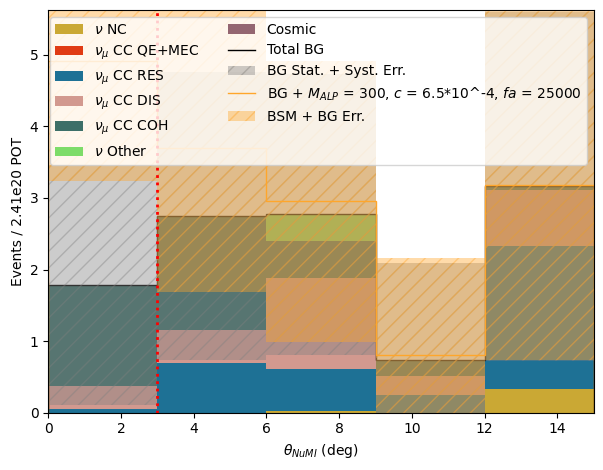

Total number of (POT-normalized) simulated background events in plot: '11.2'
Total uncertainty on simulated background events in plot: ±'4.3'
Total number of (POT-normalized) simulated signal events in plot: '4.34'
Total uncertainty on simulated signal events in plot: ±'3.27e-06'
VERIFY THAT THIS NUMBER IS TWO (1 nominal nu sample, and any number of cohlike samples (whose POTs get combined), for a total of 2 POT scalings):  2
dE/dx <= 50 MeV/cm up to 0_5 cm
dE/dx <= 35 MeV/cm 0_5-1 cm
dE/dx <= 15 MeV/cm 1-2 cm
dE/dx <= 10 MeV/cm 2-3 cm
max shower len < 0.0 cm
contained trk chi2mu < 8
opening angle < 25 deg
shorter of tracks > 100.0 cm


/tmp/ipykernel_3648118/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_3648118/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_3648118/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_3648118/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_3648118/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_3648118/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results

len(unq):  2
$M_{ALP}$ = 350, $c$ = 6.5*10^-4, $fa$ = 25000


/tmp/ipykernel_3648118/2366833809.py:315: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  mc_stat_err = float(df[bsm_cat].iloc[[0]].scale)*np.sqrt(mc_bin_nevents) # TODO_JAN_7: fix to include CV weights, and rwt_to_good_bm


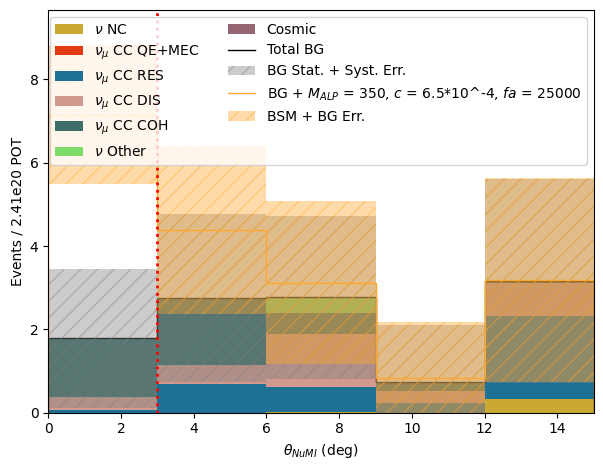

Total number of (POT-normalized) simulated background events in plot: '11.2'
Total uncertainty on simulated background events in plot: ±'4.3'
Total number of (POT-normalized) simulated signal events in plot: '7.46'
Total uncertainty on simulated signal events in plot: ±'5.14e-06'
VERIFY THAT THIS NUMBER IS TWO (1 nominal nu sample, and any number of cohlike samples (whose POTs get combined), for a total of 2 POT scalings):  2
dE/dx <= 50 MeV/cm up to 0_5 cm
dE/dx <= 35 MeV/cm 0_5-1 cm
dE/dx <= 15 MeV/cm 1-2 cm
dE/dx <= 10 MeV/cm 2-3 cm
max shower len < 0.0 cm
contained trk chi2mu < 8
opening angle < 25 deg
shorter of tracks > 100.0 cm


/tmp/ipykernel_3648118/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_3648118/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_3648118/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_3648118/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_3648118/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_3648118/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results

len(unq):  2
$M_{ALP}$ = 450, $c$ = 6.5*10^-4, $fa$ = 25000


/tmp/ipykernel_3648118/2366833809.py:315: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  mc_stat_err = float(df[bsm_cat].iloc[[0]].scale)*np.sqrt(mc_bin_nevents) # TODO_JAN_7: fix to include CV weights, and rwt_to_good_bm


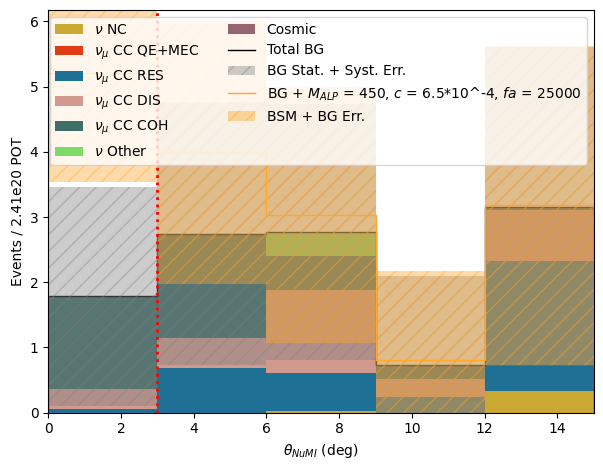

Total number of (POT-normalized) simulated background events in plot: '11.2'
Total uncertainty on simulated background events in plot: ±'4.3'
Total number of (POT-normalized) simulated signal events in plot: '5.03'
Total uncertainty on simulated signal events in plot: ±'1.88e-05'


In [23]:
x_300 = makeplot_toFit(evtdf, evtdf.Snumi_angle_hybrid_rangeCorrectedMCS*180./math.pi,
             mccoh_syst_evtdfs, mccoh_dv_vars,
             (0,15.), bins=5, vline=[3.],
             xlabel = "$\\theta_{NuMI}$ (deg)", detailed_nu="int_type",
             ratio_bounds=[0.,2.], plotname='theta_NuMI',
             textOnPlot = 'n-1 cuts of Selection DD applied. \n(not currently using all avail. cohlike evts)',
             #textOnPlot = 'Selection J applied. \n(not currently using all avail. cohlike evts)',
             bsm_index=7,
             rwt_alp=True,
             fwt_bsm_to_high_prob_bench = False,
             bsm_detector_varis_vars=0,
             bsm_magnifier = 10000,
             evtSel_key='J',
             do_detector_variations=True, 
             print_cuts = True #, do_subplot = False          
        )

x_350 = makeplot_toFit(evtdf, evtdf.Snumi_angle_hybrid_rangeCorrectedMCS*180./math.pi,
             mccoh_syst_evtdfs, mccoh_dv_vars,
             (0,15.), bins=5, vline=[3.],
             xlabel = "$\\theta_{NuMI}$ (deg)", detailed_nu="int_type",
             ratio_bounds=[0.,2.], plotname='theta_NuMI',
             textOnPlot = 'n-1 cuts of Selection DD applied. \n(not currently using all avail. cohlike evts)',
             #textOnPlot = 'Selection J applied. \n(not currently using all avail. cohlike evts)',
             bsm_index=8,
             rwt_alp=True,
             fwt_bsm_to_high_prob_bench = False,
             bsm_detector_varis_vars=0,
             bsm_magnifier = 10000,
             evtSel_key='J',
             do_detector_variations=True, 
             print_cuts = True #, do_subplot = False         
        )

x_450 = makeplot_toFit(evtdf, evtdf.Snumi_angle_hybrid_rangeCorrectedMCS*180./math.pi,
             mccoh_syst_evtdfs, mccoh_dv_vars,
             (0,15.), bins=5, vline=[3.],
             xlabel = "$\\theta_{NuMI}$ (deg)", detailed_nu="int_type",
             ratio_bounds=[0.,2.], plotname='theta_NuMI',
             textOnPlot = 'n-1 cuts of Selection DD applied. \n(not currently using all avail. cohlike evts)',
             #textOnPlot = 'Selection J applied. \n(not currently using all avail. cohlike evts)',
             bsm_index=10,
             rwt_alp=True,
             fwt_bsm_to_high_prob_bench = False,
             bsm_detector_varis_vars=0,
             bsm_magnifier = 10000,
             evtSel_key='J',
             do_detector_variations=True, 
             print_cuts = True #, do_subplot = False         
        )

In [24]:
total_mc_bg_err_in_plot, returned_bins, bg_mc, bg_mc_err, combined_sig_bg_ma400, combined_mc_err_ma400, signal_mc_ma400, signal_mc_err_ma400 = x_400

total_mc_bg_err_in_plot, returned_bins, bg_mc, bg_mc_err, combined_sig_bg_ma300, combined_mc_err_ma300, signal_mc_ma300, signal_mc_err_ma300 = x_300
total_mc_bg_err_in_plot, returned_bins, bg_mc, bg_mc_err, combined_sig_bg_ma350, combined_mc_err_ma350, signal_mc_ma350, signal_mc_err_ma350 = x_350
total_mc_bg_err_in_plot, returned_bins, bg_mc, bg_mc_err, combined_sig_bg_ma450, combined_mc_err_ma450, signal_mc_ma450, signal_mc_err_ma450 = x_450


VERIFY THAT THIS NUMBER IS TWO (1 nominal nu sample, and any number of cohlike samples (whose POTs get combined), for a total of 2 POT scalings):  2
dE/dx <= 50 MeV/cm up to 0_5 cm
dE/dx <= 35 MeV/cm 0_5-1 cm
dE/dx <= 15 MeV/cm 1-2 cm
dE/dx <= 10 MeV/cm 2-3 cm
max shower len < 0.0 cm
contained trk chi2mu < 8
opening angle < 25 deg
shorter of tracks > 100.0 cm


/tmp/ipykernel_3648118/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_3648118/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_3648118/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_3648118/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_3648118/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_3648118/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results

len(unq):  2
$M_{ALP}$ = 400, $c$ = 6.5*10^-4, $fa$ = 25000


/tmp/ipykernel_3648118/2366833809.py:315: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  mc_stat_err = float(df[bsm_cat].iloc[[0]].scale)*np.sqrt(mc_bin_nevents) # TODO_JAN_7: fix to include CV weights, and rwt_to_good_bm


$M_{ALP}$ = 400, $c$ = 4.9*10^-4, $fa$ = 5000


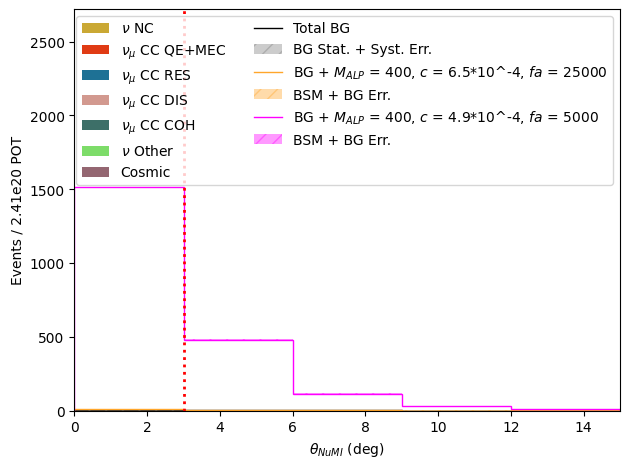

Total number of (POT-normalized) simulated background events in plot: '11.2'
Total uncertainty on simulated background events in plot: ±'4.3'
Total number of (POT-normalized) simulated signal events in plot: '2.14e+03'
Total uncertainty on simulated signal events in plot: ±'8.28e-06'


In [25]:
# SIDEBAND AND SIGNAL BOX!
xx = makeplot_toFit(evtdf, evtdf.Snumi_angle_hybrid_rangeCorrectedMCS*180./math.pi,
             mccoh_syst_evtdfs, mccoh_dv_vars,
             (0,15.), bins=5, vline=[3.],
             xlabel = "$\\theta_{NuMI}$ (deg)", detailed_nu="int_type",
             ratio_bounds=[0.,2.], plotname='theta_NuMI',
             textOnPlot = 'n-1 cuts of Selection DD applied. \n(not currently using all avail. cohlike evts)',
             #textOnPlot = 'Selection J applied. \n(not currently using all avail. cohlike evts)',
             bsm_index=9,
             rwt_alp=True,
             fwt_bsm_to_high_prob_bench = True,
             bsm_detector_varis_vars=0,
             bsm_magnifier = 10000,
             evtSel_key='J',
             do_detector_variations=True, 
             print_cuts = True #, do_subplot = False
            
        )

combined_sig_bg_highSignal_ma400, combined_mc_err_highSignal_ma400 = xx[-2:]

### Use liklihood function so that I can get a RANGE for the prediction in the signal box:

In [27]:
# First, make mock data sets:
#    'md'=='mock data'
# Note: Eventually, I'll want to sample these with a Poisson dist., smeared by the uncertainty of our model
# Note: all mock data sets should be integer numbers of events per bin (matches reality, and is also required by poisson liklihood evaluation.)

# background_only
md_bg_1 = np.round(np.random.normal(loc=bg_mc, scale=bg_mc_err))
md_bg_2 = np.round(np.random.normal(loc=bg_mc, scale=bg_mc_err))
md_bg_1[md_bg_1<0]=0 # set any negative values to zero
md_bg_2[md_bg_2<0]=0

# bg+signal_near_sensitivity_limit_400MeV
md_sigbg_1 = np.round(np.random.normal(loc=combined_sig_bg_ma400, scale=combined_mc_err_ma400))
md_sigbg_1[md_sigbg_1<0]=0
md_sigbg_2 = np.round(np.random.normal(loc=combined_sig_bg_ma400, scale=combined_mc_err_ma400))
md_sigbg_2[md_sigbg_2<0]=0

# bg+signal_at_high_sensitivity_400MeV
#combined_sig_bg_highSignal, combined_mc_err_highSignal = xx[:2]
md_hisigbg_1 = np.round(np.random.normal(loc=combined_sig_bg_highSignal_ma400, scale=combined_mc_err_highSignal_ma400))
md_hisigbg_1[md_hisigbg_1<0]=0
md_hisigbg_2 = np.round(np.random.normal(loc=combined_sig_bg_highSignal_ma400, scale=combined_mc_err_highSignal_ma400))
md_hisigbg_2[md_hisigbg_2<0]=0


Notes on THE LIKLIHOOD FUNCTION:

Interpretation of liklihood: this is the liklihood that the data is in agreement with our model ($a*BG + b*signal$).

We define the liklihood as the Poisson probablility for a given signal and background, with a normally distributed background normalization around the central value.

PROFILE LIKLIHOOD:

Calculate (or rather estimate) the liklihood as a function of b maximizing wrt a to get the profile liklihood.

(The proile liklihood reduces the number of parameters by using the value of a that maximizes L, at each b. a is a nuissance parameter.)

See [PDG Equation 40.18](https://pdg.lbl.gov/2024/reviews/rpp2024-rev-statistics.pdf) for explanation.

In [92]:
# GENERALIZE TO MULTIPLE MASS POINTS

bg_to_fit = bg_mc[1:3]

grid_size = 200
a_list = np.linspace(0,6,grid_size)

def sigBox_pred(a,b):
    return a*bg_mc[0] + b*signal_mc[0]

def L(x,a,b, signal_mc): # Liklihood 
    return (poisson.pmf(x[1],a * bg_mc[1] + b * signal_mc[1]) * poisson.pmf(x[2],a * bg_mc[2] + b * signal_mc[2]) 
            * norm.pdf(a,np.mean(bg_mc[:3]),np.mean(bg_mc_err[:3]))) # second peice makes the fit less likely to inflate a in case of excess.
# For my mean, use the CV of the bin, and for my SD use the error in my bins.
# Here, I am just using the bg_error.
# a is the bg normalization; b is the signal normalization.
# x is the mock data (all three bins! 1 for signal box + 2 for sideband!)
# signal_mc is the signal model you are fitting to (all three bins! 1 for signal box + 2 for sideband!)

def fit_model(sig_to_fit_to, A, B): # takes and uses just the sideband bins.
    # Function to describe the number of events you'll count by bin, 
    # considering BG normalization A and signal normalization B.
    # Signal_exp must be the 3-6deg and 6-9deg bins of the signal B.M. you are testing.
    # The background should be fixed to whatever our (singular) MC expectation for the background is.
    # We have to choose some signal benchmark to do the fit w.r.t (presumably, one per mass).
    # BEST PRACTICE: choose a signal benchmark on the edge of sensitivity, 
    #                so that any observable signal would result in a scaling up from 1 for the signal normalization a.
    return (A*bg_to_fit)+(B*sig_to_fit_to)

def run_L_fitter(mockdata, md_descriptor, shorthand_md_descriptor, #shorthand_md_descriptor='',
                 signal_mcs, signal_mc_descriptors, # these should be lists
                 b_list_min=-10, b_list_max=10,
                 plot_L_ProbDist=False
                ): # all inputs should be three bins (first is signalBox, second & third are sideband)
    
    ydata = mockdata[1:3] # mock data to fit.
    bg_to_fit = bg_mc[1:3]
    
    print('FIT TO %a: \n' % md_descriptor)
    
    #CHECK LEVEL OF AGREEMENT BETWEEN DATA AND BG_ONLY:
    
    print('Comparison of mock data to simulated BG-only in sideband:')
    residuals = ydata - bg_to_fit
    chi_squared = np.sum((residuals / bg_mc_err[1:3])**2)
    print(f"Chi-squared value: {chi_squared}")
    p_value_upper_sideband = chi2.sf(chi_squared, 2) # For an upper-tailed test (most common in Chi-squared tests)
    print('p-value given 2 dof: ', p_value_upper_sideband, '\n') # For an upper-tailed test (most common in Chi-squared tests)
    
    print('Comparison of mock data to simulated BG-only in sideband & signal box:')
    residuals = mockdata[:3] - bg_mc[:3]
    chi_squared = np.sum((residuals / bg_mc_err[:3])**2)
    print(f"Chi-squared value: {chi_squared}")
    p_value_upper = chi2.sf(chi_squared, 2) # For an upper-tailed test (most common in Chi-squared tests)
    print('p-value given 2 dof: ', p_value_upper, '\n') 
    
    if p_value_upper_sideband <= 0.05:
    
        # PREDICT SIGNAL BOX EXPECTATION (w/ ERR BARS) USING LIKLIHOOD METHOD 
    
        b_list = np.linspace(b_list_min, b_list_max, grid_size)
        m_prof_L = []
        m_a_max = []
        m_prof_L_int = []
        for mi, signal_mc in enumerate(signal_mcs):
            sig_to_fit_to = signal_mc[1:3]
            prof_L = [] # maximal L, for every b
            a_max = [] # a that maximizes L, for every b
            for b in b_list:
                this_pl = 0.
                this_a = 0.
                for a in a_list:
                    if L(mockdata,a,b, signal_mc) > this_pl:
                        this_pl = L(mockdata,a,b, signal_mc)
                        this_a = a
                a_max.append(this_a)
                prof_L.append(this_pl)
            a_max = np.array(a_max) # a that maximizes liklihood, for each b. a is a nuisance parameter.
            prof_L = np.array(prof_L) # the maximized L, for each b.
            prof_L_int = interp1d(b_list,prof_L) # Returns a function whose call method uses interpolation to find the value of new points.
        
            m_prof_L.append(prof_L)
            m_a_max.append(a_max)
            m_prof_L_int.append(prof_L_int)
    
        norm_prof_L = np.sum([quad(prof_L_int, b_list_min, b_list_max)[0] for prof_L_int in m_prof_L_int])
        def prob_prof_L(b, prof_L_int): # normalized probability distribution for L.
            return prof_L_int(b) / norm_prof_L

        m_prob_dens = []
        m_max_L = []
        m_max_L_ind = [] 
        m_b_max_L = []
        for mi, prof_L_int in enumerate(m_prof_L_int):
            prob_dens = np.array([prob_prof_L(b, prof_L_int) for b in b_list])
            max_L_ind = np.where(prob_dens == np.max(prob_dens))[0][0]
        
            m_prob_dens.append(prob_dens)
            m_max_L.append( np.max(prob_dens) )
            m_max_L_ind.append( max_L_ind )
            m_b_max_L.append( b_list[max_L_ind] )
    
        #print('m_max_L: ', m_max_L)
        #print('m_max_L_ind: ', m_max_L_ind)
        #print('m_b_max_L: ', m_b_max_L)
    
        # PRINT RESULTS OF BEST FIT:
    
        #print("Optimal parameters (A = BG normalization, B = signal normalization) occur for this benchmark mass: ")
        best_mass_ind = np.where(m_max_L == np.max(m_max_L))[0][0]
        #print(signal_mc_descriptors[best_mass_ind].split(',')[0])
        best_b = m_b_max_L[best_mass_ind]
        best_a = float(m_a_max[best_mass_ind][np.where(b_list==best_b)])
        #print(f"Optimal parameters (A = BG normalization, B = signal normalization): {best_a, best_b}")
        expectation_cv = best_a*bg_mc[0] + best_b*signal_mcs[best_mass_ind][0]
        #print('Signal box expectation w/ best fit: ', expectation_cv)
        print('CV expectation:')
        print(expectation_cv, ' signal box events')
        print('from '+signal_mc_descriptors[best_mass_ind].split(',')[0], ', with a=', best_a, ', b=', best_b, '\n')
    
        ## GET THE 95% C.L. BOUNDS ON b:
    
        # first get a ballpark guess based on one liklihood distribution:
    
        mm_ind = len(signal_mc_descriptors)//2 # 'mm' = 'middle mass'
        #mm_full_int = quad(prob_prof_L(m_prof_L_int[mm_ind]), b_list[0], b_list[-1])[0]
        mm_right_half_int = quad(prob_prof_L, m_b_max_L[mm_ind], b_list[-1], args=(m_prof_L_int[mm_ind]))[0]
        mm_integrated_up_from_half_L = []
        for i in range(m_max_L_ind[mm_ind], grid_size):
            mm_integrated_up_from_half_L.append(quad(prob_prof_L, 
                                                    m_b_max_L[mm_ind], b_list[i],
                                                    args=(m_prof_L_int[mm_ind])
                                                   )[0])
        mm_b_upper_bound = b_list[m_max_L_ind[mm_ind] + np.argmin(np.abs(np.array(mm_integrated_up_from_half_L)/mm_right_half_int - 0.95))] # 95% sure true b is between lower bound (in this case zero) and this value.
        A = prob_prof_L(mm_b_upper_bound, m_prof_L_int[mm_ind])
        #print('A: ', A)
        ints_given_A = []
        b_bounds = []
        for mi, prof_L_int in enumerate(m_prof_L_int):
            b_lower = brentq(lambda this_b: prob_prof_L(this_b, prof_L_int) - A, b_list[0], m_b_max_L[mi])
            b_upper = brentq(lambda this_b: prob_prof_L(this_b, prof_L_int) - A, m_b_max_L[mi], b_list[-1])
            b_bounds.append([b_lower, b_upper])
            ints_given_A.append(
                quad(prob_prof_L,
                     b_lower,
                     b_upper,
                     args=(prof_L_int)
                    )[0]
            )
        CL_sum = np.sum(ints_given_A)
        #print('np.sum(ints_given_A): ', np.sum(ints_given_A))
    
        while round(CL_sum*100.) != 95:
            A_step = np.max(m_prob_dens[best_mass_ind])/100.
            if CL_sum >= 0.955:
                A = A + A_step
            if CL_sum < 0.945:
                A = A - A_step
            ints_given_A = []
            b_bounds = []
            for mi, prof_L_int in enumerate(m_prof_L_int):
                b_lower = brentq(lambda this_b: prob_prof_L(this_b, prof_L_int) - A, b_list[0], m_b_max_L[mi])
                b_upper = brentq(lambda this_b: prob_prof_L(this_b, prof_L_int) - A, m_b_max_L[mi], b_list[-1])
                b_bounds.append([b_lower, b_upper])
                ints_given_A.append(
                    quad(prob_prof_L,
                         b_lower,
                         b_upper,
                         args=(prof_L_int)
                        )
                )
            CL_sum = np.sum(ints_given_A)
        ##check:
        print('Probability of getting a b within calculated 95% probability limits: ', CL_sum)
    
        # CALCULATE THE BOUNDS ON THE PREDICTION IN THE SIGNAL BOX:
        # TODO: pick up here Wednesday. 
    
        expectation_low = expectation_cv
        expectation_low_mi = 100
        expectation_low_a = 100
        expectation_high = expectation_cv
        expectation_high_mi = 100
        expectation_low_b = 100
        for mi, signal_mc in enumerate(signal_mcs):
            b_low = b_bounds[mi][0]
            L_temp = -1.
            a_low = -1.
            for a in a_list:
                if L(mockdata,a,b_low, signal_mc) > L_temp:
                    L_temp = L(mockdata,a,b_low, signal_mc)
                    a_low = a
            exp = a_low*bg_mc[0] + b_low*signal_mc[0]
            if exp < expectation_low:
                expectation_low = exp
                expectation_low_mi = mi
                expectation_low_a = a_low
        
            b_hi = b_bounds[mi][1]
            L_temp = -1.
            a_hi = -1.
            for a in a_list:
                if L(mockdata,a,b_hi, signal_mc) > L_temp:
                    L_temp = L(mockdata,a,b_hi, signal_mc)
                    a_hi = a
            exp = a_hi*bg_mc[0] + b_hi*signal_mc[0]
            if exp > expectation_high:
                expectation_high = exp
                expectation_high_mi = mi
                expectation_high_a = a_hi
    
        print('95% CL lower bound expectation:')
        print(round(expectation_low), ' signal box events')
        print('from '+signal_mc_descriptors[expectation_low_mi].split(',')[0]+', with a=', 
              expectation_low_a,', b=',b_bounds[expectation_low_mi][0],'\n')
    
        print('95% CL upper bound expectation:')
        print(round(expectation_high), ' signal box events')
        print('from '+signal_mc_descriptors[expectation_high_mi].split(',')[0]+', with a=', 
              expectation_high_a,', b=',b_bounds[expectation_high_mi][0],'\n')
    
        # PLOT THE LIKLIHOOD:
    
        if plot_L_ProbDist:
            show_best_a_for_b = False
            if show_best_a_for_b:
                default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
                fig, ax1 = plt.subplots()
                ax1.set_xlabel('value of b')
                ax1.set_ylabel('Probability Density \n(using the maximizing value of $a$ found above)') #, color='C0')
                for mi, prob_dens in enumerate(m_prob_dens):
                    ax1.plot(b_list, prob_dens, color=default_colors[mi], label=signal_mc_descriptors[mi])
                ax1.tick_params(axis='y')#, labelcolor='C0')
                ax1.vlines(x=np.concatenate([bb for bb in b_bounds]), ymin=-1, ymax=A, color='black', linestyle=':', 
                           label='95% CL bounds on b', alpha=0.5)
                ax1.set_ylim(0, 1.2*max(prob_dens))

                ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis
                ax2.set_ylabel('L-maximizing a') #, color='C1')  # we already handled the x-label with ax1
                for mi, prob_dens in enumerate(m_prob_dens):
                    ax2.plot(b_list, m_a_max[mi], linestyle='--', color=default_colors[mi])
                ax2.tick_params(axis='y')#, labelcolor='C1')
                ax2.set_ylim(np.min(a_list), np.max(a_list)*1.1)
                
                #ax1[0].axvline(x=[b_max_L, b_upper_bound, b_lower_bound], color='black', linestyle=':', 
                #               label='Vertical Line 1', alpha=0.5)

                fig.tight_layout()  # otherwise the right y-label is slightly clipped
                plt.show()
        
            else:
                for mi, prob_dens in enumerate(m_prob_dens):
                    plt.plot(b_list, prob_dens, label=signal_mc_descriptors[mi]) # , color='C0'
                plt.xlim(b_list_min-0.1*b_list_min, 1.1*b_list_max)
                plt.ylim(0,1.2*max(prob_dens))
                plt.ylabel('Probability Density \n(using the maximizing value of $a$ found above)')
                plt.vlines(np.concatenate([bb for bb in b_bounds]), -5, A, color='black', linestyle=':', alpha=0.5)
                plt.hlines([A], b_list_min-0.1*b_list_min, 1.1*b_list_max, color='black', linestyle=':', alpha=0.5)
                plt.xlabel('value of b')
                plt.legend()
                plt.show() # should integrate to 1.
    
        ## AND WHAT IF WE OPTIMIZE USING CURVE_FIT?
    
        #initial_guesses = [1, 1]
        #my_yerr = combined_mc_err[1:3]
        #popt, pcov = curve_fit(fit_model, sig_to_fit_to, ydata, p0=initial_guesses, sigma=my_yerr, 
        #                       bounds=([0,0],[10, 10000]))#, method='dogbox') # (from scipy) # bounds=([0,0],[np.inf, np.inf])
        #print('popt: ', popt[0], ', ', popt[1])
    
    # MAKE THE PLOTS:
    
    bin_centers = (returned_bins[0:-1]+returned_bins[1:])/2.
    bin_half_width = returned_bins[1]-bin_centers[0]
    
    mycapsize = 5
    plt.errorbar(bin_centers, bg_mc, yerr=bg_mc_err, fmt='o', label='simulated BG', capsize=mycapsize) #, xerr=bin_half_width
    plt.errorbar(bin_centers, mockdata, fmt='o', label='mock data\n'+shorthand_md_descriptor, color='black')
    ##print('asymm. error bars: ', np.array([[expectation_cv-expectation_low], [expectation_high-expectation_cv]]))
    ### apply some fudging in case of negative number of events predicted in signal box:
    if p_value_upper <= 0.05:
        #plt.errorbar(bin_centers, combined_sig_bg-bg_mc, fmt='o', label='simulated ' + signal_mc_descriptor, capsize=mycapsize)
        for mi, signal_mc in enumerate(signal_mcs):
            plt.errorbar(bin_centers, bg_mc+signal_mc, yerr=bg_mc_err, fmt='x', # yerr=combined_mc_err, 
                         label='simulated BG + ' + signal_mc_descriptors[mi], capsize=mycapsize)
        plt.title( '(note: Only BG unc. is shown on (mc+bg) data)')
        expectation_cv_to_plot = np.max([expectation_cv, 0.])
        expectation_low_to_plot = np.max([expectation_low, 0.])
        plt.errorbar(bin_centers[0], expectation_cv_to_plot, 
                     yerr=np.array([[expectation_cv_to_plot-expectation_low_to_plot], 
                                    [expectation_high-expectation_cv]]), 
                     fmt='D', 
                     label=f'predicted signal box data from Liklihood \n a={float(best_a):.2f}, b={best_b:.2f}' , 
                     capsize=mycapsize
                    )
        #plt.errorbar(bin_centers[0], popt[0]*bg_mc[0] + popt[1]*(combined_sig_bg[0]-bg_mc[0]), fmt='D', 
        #            label=f'predicted signal box data from curve_fit \n a={popt[0]:.2f}, b={popt[1]:.2f}')
    plt.legend(fontsize='small')
    plt.xlabel('$\\theta_{NuMI}$ (bin centers)')
    plt.ylabel('Number of Events')
    plt.show()
    
    return


FIT TO 'BG_ONLY MOCK DATA SET #1': 

Comparison of mock data to simulated BG-only in sideband:
Chi-squared value: 2.0499420347344963
p-value given 2 dof:  0.3588068644228358 

Comparison of mock data to simulated BG-only in sideband & signal box:
Chi-squared value: 2.268525727874923
p-value given 2 dof:  0.3216591405182862 



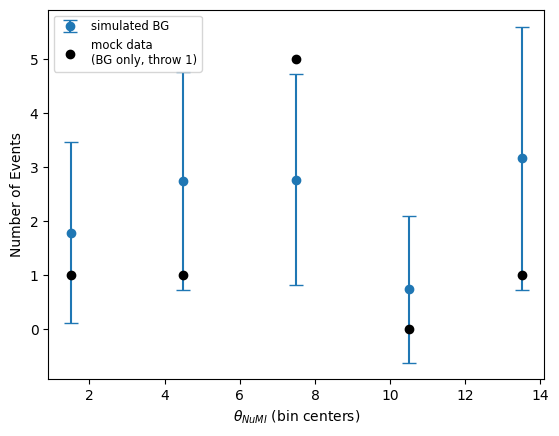

In [86]:
run_L_fitter(#md_hisigbg_1, 'BG+SIG_400MeV_fa5000 MOCK DATA SET #1', '(BG + ($m_a$ = 400 MeV, $f_a$ = 5000), throw 1)', 
             md_bg_1, 'BG_ONLY MOCK DATA SET #1', '(BG only, throw 1)',
             [signal_mc_ma300, signal_mc_ma350, signal_mc_ma400, signal_mc_ma450], 
             ['$m_a$ = 300 MeV, $f_a$ = 25000',
              '$m_a$ = 350 MeV, $f_a$ = 25000',
              '$m_a$ = 400 MeV, $f_a$ = 25000',
              '$m_a$ = 450 MeV, $f_a$ = 25000'
             ], 
             #b_list_min=1, b_list_max=200,
             b_list_min=-20, b_list_max=10,
             plot_L_ProbDist=True
            )

FIT TO 'BG+SIG_400MeV_fa5000 MOCK DATA SET #1': 

Comparison of mock data to simulated BG-only in sideband:
Chi-squared value: 58837.10093656002
p-value given 2 dof:  0.0 

Comparison of mock data to simulated BG-only in sideband & signal box:
Chi-squared value: 871188.2635057356
p-value given 2 dof:  0.0 



/tmp/ipykernel_3648118/4194531934.py:86: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  norm_prof_L = np.sum([quad(prof_L_int, b_list_min, b_list_max)[0] for prof_L_int in m_prof_L_int])
/tmp/ipykernel_3648118/4194531934.py:127: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and 

CV expectation:
1561.982777678849  signal box events
from $m_a$ = 350 MeV , with a= 2.6834170854271355 , b= 290.0854271356784 



/tmp/ipykernel_3648118/4194531934.py:144: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  quad(prob_prof_L,
/tmp/ipykernel_3648118/4194531934.py:166: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrato

Probability of getting a b within calculated 95% probability limits:  0.9519924785079888
95% CL lower bound expectation:
1197  signal box events
from $m_a$ = 450 MeV, with a= 4.281407035175879 , b= 346.61774026803926 

95% CL upper bound expectation:
1717  signal box events
from $m_a$ = 350 MeV, with a= 1.3266331658291457 , b= 262.3698599624561 



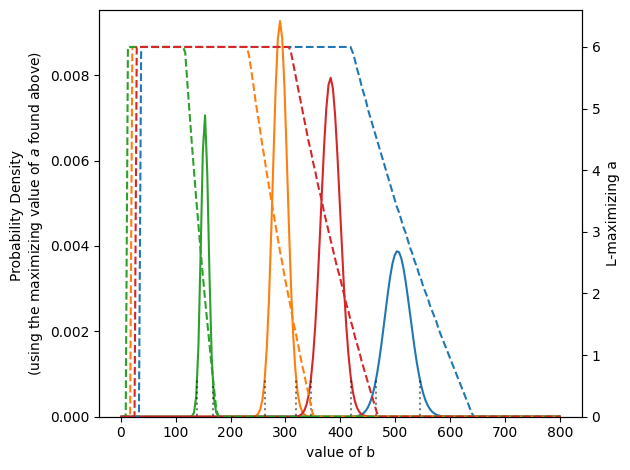

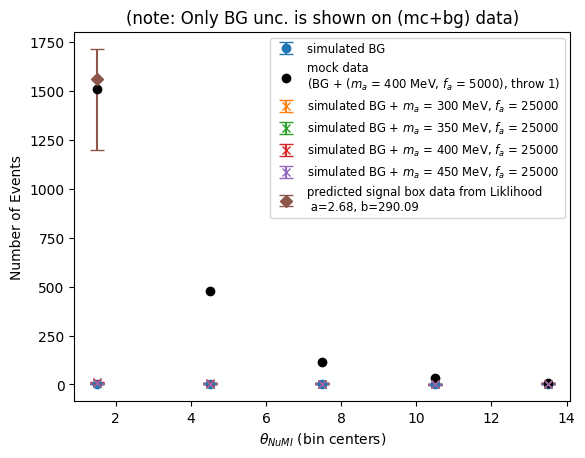

In [91]:
run_L_fitter(md_hisigbg_1, 'BG+SIG_400MeV_fa5000 MOCK DATA SET #1', '(BG + ($m_a$ = 400 MeV, $f_a$ = 5000), throw 1)', 
             #md_bg_1, 'BG_ONLY MOCK DATA SET #1', '(BG only, throw 1)',
             [signal_mc_ma300, signal_mc_ma350, signal_mc_ma400, signal_mc_ma450], 
             ['$m_a$ = 300 MeV, $f_a$ = 25000',
              '$m_a$ = 350 MeV, $f_a$ = 25000',
              '$m_a$ = 400 MeV, $f_a$ = 25000',
              '$m_a$ = 450 MeV, $f_a$ = 25000'
             ], 
             b_list_min=1, b_list_max=800,
             #b_list_min=-20, b_list_max=10,
             plot_L_ProbDist=True
            )

In [39]:
# THIS CELL WORKS FOR A SINGLE MASS POINT.

bg_to_fit = bg_mc[1:3]

grid_size = 200
a_list = np.linspace(0,6,grid_size)

def sigBox_pred(a,b):
    return a*bg_mc[0] + b*signal_mc[0]

def L(x,a,b, signal_mc): # Liklihood
    return (poisson.pmf(x[1],a * bg_mc[1] + b * signal_mc[1]) * poisson.pmf(x[2],a * bg_mc[2] + b * signal_mc[2]) 
            * norm.pdf(a,np.mean(bg_mc[:3]),np.mean(bg_mc_err[:3]))) # second peice makes the fit less likely to inflate a in case of excess.
# For my mean, use the CV of the bin, and for my SD use the error in my bins.
# Here, I am just using the bg_error.
# a is the bg normalization; b is the signal normalization.
# x is the mock data (all three bins! 1 for signal box + 2 for sideband!)
# signal_mc is the signal model you are fitting to (all three bins! 1 for signal box + 2 for sideband!)

def fit_model(sig_to_fit_to, A, B): # takes and uses just the sideband bins.
    # Function to describe the number of events you'll count by bin, 
    # considering BG normalization A and signal normalization B.
    # Signal_exp must be the 3-6deg and 6-9deg bins of the signal B.M. you are testing.
    # The background should be fixed to whatever our (singular) MC expectation for the background is.
    # We have to choose some signal benchmark to do the fit w.r.t (presumably, one per mass).
    # BEST PRACTICE: choose a signal benchmark on the edge of sensitivity, 
    #                so that any observable signal would result in a scaling up from 1 for the signal normalization a.
    return (A*bg_to_fit)+(B*sig_to_fit_to)

def run_L_fitter(mockdata, md_descriptor, shorthand_md_descriptor, #shorthand_md_descriptor='',
                 signal_mc, signal_mc_descriptor, 
                 b_list_min=-10, b_list_max=10,
                 plot_L_ProbDist=False
                ): # all inputs should be three bins (first is signalBox, second & third are sideband)
    
    ydata = mockdata[1:3] # mock data to fit.
    bg_to_fit = bg_mc[1:3]
    sig_to_fit_to = signal_mc[1:3]
    
    print('FIT TO %a: \n' % md_descriptor)
    
    #CHECK LEVEL OF AGREEMENT BETWEEN DATA AND BG_ONLY:
    
    print('Comparison of mock data to simulated BG-only:')
    residuals = ydata - bg_to_fit
    chi_squared = np.sum((residuals / bg_mc_err[1:3])**2)
    print(f"Chi-squared value: {chi_squared}")
    p_value_upper = chi2.sf(chi_squared, 2) # For an upper-tailed test (most common in Chi-squared tests)
    print('p-value given 2 dof: ', p_value_upper) # For an upper-tailed test (most common in Chi-squared tests)
    print('')
    
    # PREDICT SIGNAL BOX EXPECTATION (w/ ERR BARS) USING LIKLIHOOD METHOD 
    
    b_list = np.linspace(b_list_min, b_list_max, grid_size)
    prof_L = [] # maximal L, for every b
    a_max = [] # a that maximizes L, for every b
    for b in b_list:
        this_pl = 0.
        this_a = 0.
        for a in a_list:
            if L(mockdata,a,b, signal_mc) > this_pl:
                this_pl = L(mockdata,a,b, signal_mc)
                this_a = a
        a_max.append(this_a)
        prof_L.append(this_pl)
    a_max = np.array(a_max) # a that maximizes liklihood, for each b. a is a nuisance parameter.
    prof_L = np.array(prof_L) # the maximized L, for each b.
    
    prof_L_int = interp1d(b_list,prof_L) # Returns a function whose call method uses interpolation to find the value of new points.
    norm_prof_L = quad(prof_L_int, b_list_min, b_list_max)[0]
    def prob_prof_L(b): # normalized probability distribution for L.
        return prof_L_int(b) / norm_prof_L
    
    prob_dens = np.array([prob_prof_L(b) for b in b_list])
    max_L_ind = np.where(prob_dens == np.max(prob_dens))[0][0]
    b_max_L = b_list[max_L_ind]
    
    # Print results of best fit:
    
    print(f"Optimal parameters (A = BG normalization, B = signal normalization): {float(a_max[np.where(b_list==b_max_L)]), b_max_L}")
    print('These parameters maximize the liklihood that the mock data is consistent \n \
          with this number of counts in each bin: N|expected_signal = A+expected_BG + B*expected_signal')
    print('(The signal being fit to here is: '+signal_mc_descriptor+')')
    print('')
    
    ## Get the 95% C.L. bounds on b:
    
    right_half_integral = quad(prob_prof_L, b_max_L, b_list[-1])[0] # If things were behaving on left side, and we integrated from true peak, this would equal 0.5. 
    integrated_up_fromHalf_L = []
    for i in range(max_L_ind,grid_size):
        integrated_up_fromHalf_L.append(quad(prob_prof_L, b_max_L, b_list[i])[0])
    b_upper_bound = b_list[max_L_ind + np.argmin(np.abs(np.array(integrated_up_fromHalf_L)/right_half_integral - 0.95))] # 95% sure true b is between lower bound (in this case zero) and this value.
    #print('upper bound on b: ', b_upper_bound)
    
    ## Assume symmetric L shape to determine b_lower_bound:
    b_lower_bound = b_list[max_L_ind - np.argmin(np.abs(np.array(integrated_up_fromHalf_L)/right_half_integral - 0.95))] # 95% sure true b is between lower bound (in this case zero) and this value.
    
    #check:
    print('Probability of getting a b within calculated 95% probability limits: ',
          quad(prob_prof_L, b_lower_bound, b_upper_bound)[0]/quad(prob_prof_L, b_list_min, b_list_max)[0]
         )
    
    if plot_L_ProbDist:
        show_best_a_for_b = True
        if show_best_a_for_b:
            fig, ax1 = plt.subplots()
            ax1.set_xlabel('value of b')
            ax1.set_ylabel('Probability Density \n(using the maximizing value of $a$ found above)', color='C0')
            ax1.plot(b_list, prob_dens, color='C0')
            ax1.tick_params(axis='y')#, labelcolor='C0')

            ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis
            ax2.set_ylabel('L-maximizing a', color='C1')  # we already handled the x-label with ax1
            ax2.plot(b_list, a_max, color='C1')
            ax2.tick_params(axis='y')#, labelcolor='C1')
        
            ax1.vlines(x=[b_max_L, b_upper_bound, b_lower_bound], ymin=-1, ymax=5, color='black', linestyle=':', 
                       label='CV exp. b and 95% CL bounds on b', alpha=0.5)
            ax1.set_ylim(0, 1.2*max(prob_dens))
            #ax1[0].axvline(x=[b_max_L, b_upper_bound, b_lower_bound], color='black', linestyle=':', 
            #               label='Vertical Line 1', alpha=0.5)

            fig.tight_layout()  # otherwise the right y-label is slightly clipped
            plt.show()
        
        else:    
            #plt.plot(b_list, prob_dens)
            #plt.xlim(b_list_min-0.1*b_list_min, 1.1*b_list_max)
            #plt.ylim(0,1.2*max(prob_dens))
            #plt.ylabel('Probability Density \n(using the maximizing value of $a$ found above)')
            #plt.vlines([b_max_L, b_upper_bound, b_lower_bound], -5, 1, color='black', linestyle=':', alpha=0.5)
            #plt.xlabel('value of b')
            #plt.show() # should integrate to 1.
    
    # the bounds on prediction in signal box:
    expectation_low = sigBox_pred(a_max[np.where(b_list==b_lower_bound)], b_lower_bound)[0] 
    expectation_high =  sigBox_pred(a_max[np.where(b_list==b_upper_bound)], b_upper_bound)[0]
    expectation_cv = sigBox_pred(a_max[np.where(b_list==b_max_L)], b_max_L)[0]
    print('Lower bound for the expectation on signal box data: ', expectation_low)
    print('Upper bound for the expectation on signal box data: ', expectation_high)
    print('Central value expectation on signal box data: ', expectation_cv)
    
    # AND WHAT IF WE OPTIMIZE USING CURVE_FIT?
    
    initial_guesses = [1, 1]
    my_yerr = combined_mc_err[1:3]
    popt, pcov = curve_fit(fit_model, sig_to_fit_to, ydata, p0=initial_guesses, sigma=my_yerr, 
                           bounds=([0,0],[10, 10000]))#, method='dogbox') # (from scipy) # bounds=([0,0],[np.inf, np.inf])
    print('popt: ', popt[0], ', ', popt[1])
    
    # MAKE THE PLOTS:
    
    bin_centers = (returned_bins[0:-1]+returned_bins[1:])/2.
    bin_half_width = returned_bins[1]-bin_centers[0]
    
    mycapsize = 5
    plt.errorbar(bin_centers, bg_mc, yerr=bg_mc_err, fmt='o', label='simulated BG', capsize=mycapsize) #, xerr=bin_half_width
    plt.errorbar(bin_centers, combined_sig_bg-bg_mc, fmt='o', 
                 label='simulated ' + signal_mc_descriptor, capsize=mycapsize)
    plt.errorbar(bin_centers, combined_sig_bg, yerr=combined_mc_err, fmt='o', 
                 label='simulated BG + ' + signal_mc_descriptor, capsize=mycapsize)
    plt.errorbar(bin_centers, mockdata, fmt='o', label='mock data\n'+shorthand_md_descriptor)
    #print('asymm. error bars: ', np.array([[expectation_cv-expectation_low], [expectation_high-expectation_cv]]))
    ## apply some fudging in case of negative number of events predicted in signal box:
    expectation_cv_to_plot = np.max([expectation_cv, 0.])
    expectation_low_to_plot = np.max([expectation_low, 0.])
    plt.errorbar(bin_centers[0], expectation_cv_to_plot, 
                 yerr=np.array([[expectation_cv_to_plot-expectation_low_to_plot], 
                                [expectation_high-expectation_cv]]), 
                 fmt='D', label=f'predicted signal box data from Liklihood \n a={float(a_max[np.where(b_list==b_max_L)]):.2f}, b={b_max_L:.2f}' , 
                 capsize=mycapsize)
    plt.errorbar(bin_centers[0], popt[0]*bg_mc[0] + popt[1]*(combined_sig_bg[0]-bg_mc[0]), fmt='D', 
                label=f'predicted signal box data from curve_fit \n a={popt[0]:.2f}, b={popt[1]:.2f}')
    plt.legend()
    plt.xlabel('$\\theta_{NuMI}$ (bin centers)')
    plt.ylabel('Number of Events')
    plt.show()
    
    return

FIT TO 'BG_ONLY MOCK DATA SET #1': 

Comparison of mock data to simulated BG-only:
Chi-squared value: 2.0499420347344963
p-value given 2 dof:  0.3588068644228358



/tmp/ipykernel_2694610/3184293389.py:68: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  norm_prof_L = quad(prof_L_int, b_list_min, b_list_max)[0]
/tmp/ipykernel_2694610/3184293389.py:86: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges

Optimal parameters (A = BG normalization, B = signal normalization): (2.321608040201005, -1.7587939698492452)
These parameters maximize the liklihood that the mock data is consistent 
           with this number of counts in each bin: N|expected_signal = A+expected_BG + B*expected_signal
(The signal being fit to here is: $m_a$ = 400 MeV, $f_a$ = 25000)



/tmp/ipykernel_2694610/3184293389.py:89: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  integrated_up_fromHalf_L.append(quad(prob_prof_L, b_max_L, b_list[i])[0])
/tmp/ipykernel_2694610/3184293389.py:98: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  

Probability of getting a b within calculated 95% probability limits:  0.9427438138128056
Lower bound for the expectation on signal box data:  -28.30476737538642
Upper bound for the expectation on signal box data:  4.345371723170532
Central value expectation on signal box data:  -12.732265345948175
popt:  1.1111928540211768 ,  1.3930238503275832e-22


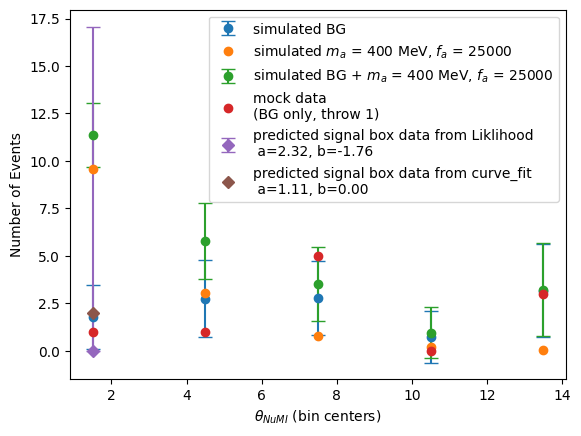

In [40]:
run_L_fitter(md_bg_1, 'BG_ONLY MOCK DATA SET #1', '(BG only, throw 1)',
             signal_mc_ma400, '$m_a$ = 400 MeV, $f_a$ = 25000'
            )

FIT TO 'BG_ONLY MOCK DATA SET #1': 

Comparison of mock data to simulated BG-only:
Chi-squared value: 2.0499420347344963
p-value given 2 dof:  0.3588068644228358



/tmp/ipykernel_2694610/3184293389.py:68: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  norm_prof_L = quad(prof_L_int, b_list_min, b_list_max)[0]
/tmp/ipykernel_2694610/3184293389.py:86: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges

Optimal parameters (A = BG normalization, B = signal normalization): (2.321608040201005, -1.7587939698492452)
These parameters maximize the liklihood that the mock data is consistent 
           with this number of counts in each bin: N|expected_signal = A+expected_BG + B*expected_signal
(The signal being fit to here is: $m_a$ = 400 MeV, $f_a$ = 25000)



/tmp/ipykernel_2694610/3184293389.py:98: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  quad(prob_prof_L, b_lower_bound, b_upper_bound)[0]/quad(prob_prof_L, b_list_min, b_list_max)[0]


Probability of getting a b within calculated 95% probability limits:  0.9427438138128056
Lower bound for the expectation on signal box data:  -28.30476737538642
Upper bound for the expectation on signal box data:  4.345371723170532
Central value expectation on signal box data:  -12.732265345948175
popt:  1.1111928540211768 ,  1.3930238503275832e-22


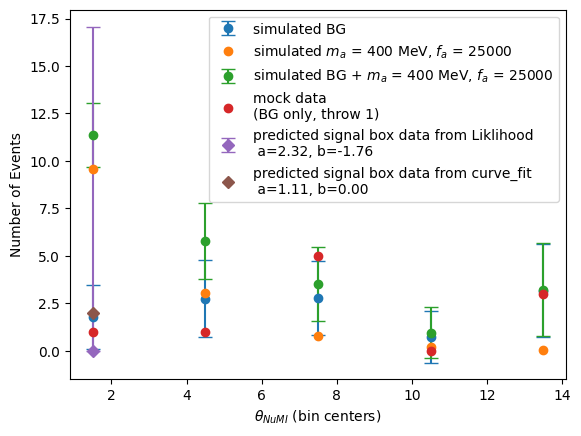

FIT TO 'BG_ONLY MOCK DATA SET #2': 

Comparison of mock data to simulated BG-only:
Chi-squared value: 1.1469557177949379
p-value given 2 dof:  0.5635620372164962

Optimal parameters (A = BG normalization, B = signal normalization): (1.9597989949748742, -1.457286432160803)
These parameters maximize the liklihood that the mock data is consistent 
           with this number of counts in each bin: N|expected_signal = A+expected_BG + B*expected_signal
(The signal being fit to here is: $m_a$ = 400 MeV, $f_a$ = 25000)

Probability of getting a b within calculated 95% probability limits:  0.9470903330748972
Lower bound for the expectation on signal box data:  -26.05758752866614
Upper bound for the expectation on signal box data:  6.700061215582274
Central value expectation on signal box data:  -10.485085499227893
popt:  0.9240152306330035 ,  2.7767903863779616e-28


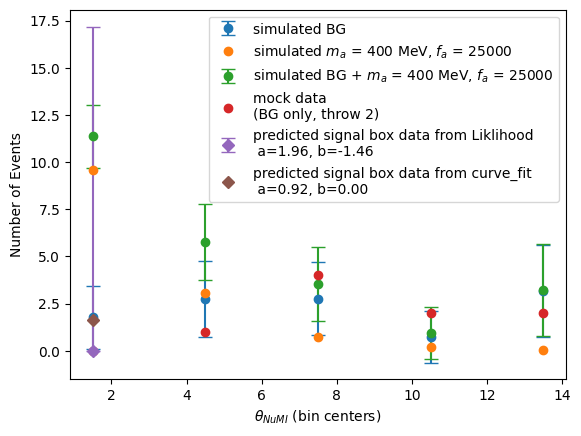

FIT TO 'BG+SIG_400MeV_fa25000 MOCK DATA SET #1': 

Comparison of mock data to simulated BG-only:
Chi-squared value: 1.6848895748274977
p-value given 2 dof:  0.43065637208803675

Optimal parameters (A = BG normalization, B = signal normalization): (2.050251256281407, -0.5527638190954764)
These parameters maximize the liklihood that the mock data is consistent 
           with this number of counts in each bin: N|expected_signal = A+expected_BG + B*expected_signal
(The signal being fit to here is: $m_a$ = 400 MeV, $f_a$ = 25000)

Probability of getting a b within calculated 95% probability limits:  0.961742921404623
Lower bound for the expectation on signal box data:  -23.37686152824654
Upper bound for the expectation on signal box data:  22.071574237371482
Central value expectation on signal box data:  -1.6471078680835465
popt:  1.6371070351113837 ,  2.175697881405536e-10


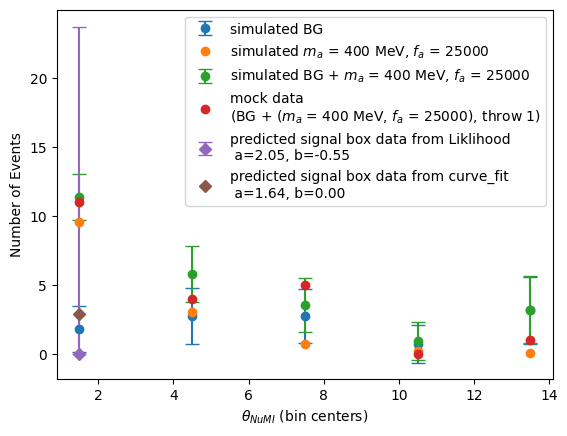

FIT TO 'BG+SIG_400MeV_fa25000 MOCK DATA SET #2': 

Comparison of mock data to simulated BG-only:
Chi-squared value: 2.549035051575573
p-value given 2 dof:  0.27956581898606025

Optimal parameters (A = BG normalization, B = signal normalization): (1.9597989949748742, -0.1507537688442202)
These parameters maximize the liklihood that the mock data is consistent 
           with this number of counts in each bin: N|expected_signal = A+expected_BG + B*expected_signal
(The signal being fit to here is: $m_a$ = 400 MeV, $f_a$ = 25000)

Probability of getting a b within calculated 95% probability limits:  0.9597346544676973
Lower bound for the expectation on signal box data:  -20.69964309876041
Upper bound for the expectation on signal box data:  26.730705970282706
Central value expectation on signal box data:  2.0479446245379958
popt:  1.800187113448968 ,  0.01813756272494429


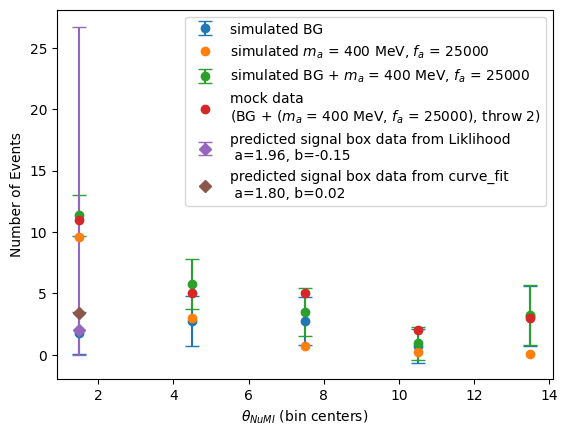

In [42]:
sig_to_fit = (combined_sig_bg_ma400[1:3]-bg_to_fit) # signal expectation for m_a = 400 MeV, fa = 25000

run_L_fitter(md_bg_1, 'BG_ONLY MOCK DATA SET #1', '(BG only, throw 1)',
             signal_mc_ma400, '$m_a$ = 400 MeV, $f_a$ = 25000'
            )
run_L_fitter(md_bg_2, 'BG_ONLY MOCK DATA SET #2', '(BG only, throw 2)',
             signal_mc_ma400, '$m_a$ = 400 MeV, $f_a$ = 25000'
            )

run_L_fitter(md_sigbg_1, 'BG+SIG_400MeV_fa25000 MOCK DATA SET #1', '(BG + ($m_a$ = 400 MeV, $f_a$ = 25000), throw 1)',
             signal_mc_ma400, '$m_a$ = 400 MeV, $f_a$ = 25000'
            )
run_L_fitter(md_sigbg_2, 'BG+SIG_400MeV_fa25000 MOCK DATA SET #2', '(BG + ($m_a$ = 400 MeV, $f_a$ = 25000), throw 2)',
             signal_mc_ma400, '$m_a$ = 400 MeV, $f_a$ = 25000'
            )




FIT TO 'BG+SIG_400MeV_fa5000 MOCK DATA SET #1': 

Comparison of mock data to simulated BG-only:
Chi-squared value: 58837.10093656002
p-value given 2 dof:  0.0



/tmp/ipykernel_2694610/3184293389.py:68: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  norm_prof_L = quad(prof_L_int, b_list_min, b_list_max)[0]
/tmp/ipykernel_2694610/3184293389.py:86: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges

Optimal parameters (A = BG normalization, B = signal normalization): (1.9899497487437185, 152.76381909547737)
These parameters maximize the liklihood that the mock data is consistent 
           with this number of counts in each bin: N|expected_signal = A+expected_BG + B*expected_signal
(The signal being fit to here is: $m_a$ = 400 MeV, $f_a$ = 25000)



/tmp/ipykernel_2694610/3184293389.py:89: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  integrated_up_fromHalf_L.append(quad(prob_prof_L, b_max_L, b_list[i])[0])
/tmp/ipykernel_2694610/3184293389.py:98: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  

Probability of getting a b within calculated 95% probability limits:  0.9578179360157834


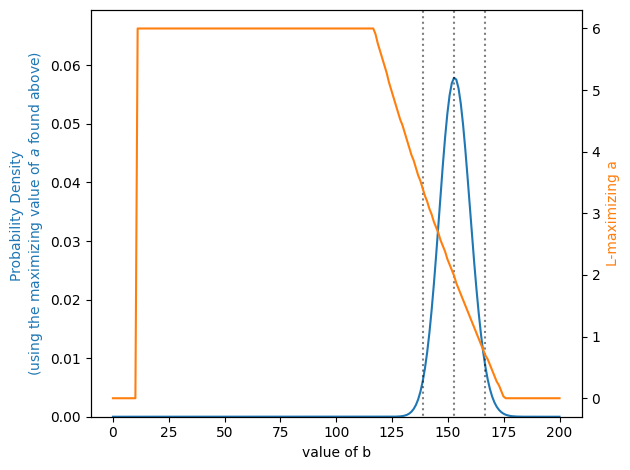

Lower bound for the expectation on signal box data:  1336.5036465813312
Upper bound for the expectation on signal box data:  1601.607899806327
Central value expectation on signal box data:  1468.9482635481374
popt:  4.360894098266973e-15 ,  156.8139926633587


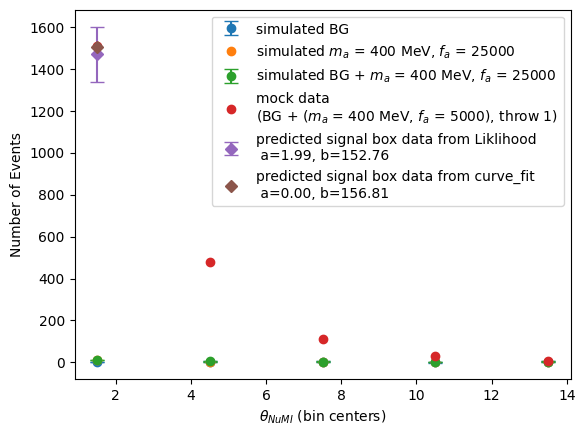

FIT TO 'BG+SIG_400MeV_fa5000 MOCK DATA SET #2': 

Comparison of mock data to simulated BG-only:
Chi-squared value: 58837.10093656002
p-value given 2 dof:  0.0

Optimal parameters (A = BG normalization, B = signal normalization): (1.9899497487437185, 152.76381909547737)
These parameters maximize the liklihood that the mock data is consistent 
           with this number of counts in each bin: N|expected_signal = A+expected_BG + B*expected_signal
(The signal being fit to here is: $m_a$ = 400 MeV, $f_a$ = 25000)

Probability of getting a b within calculated 95% probability limits:  0.9578179360157834


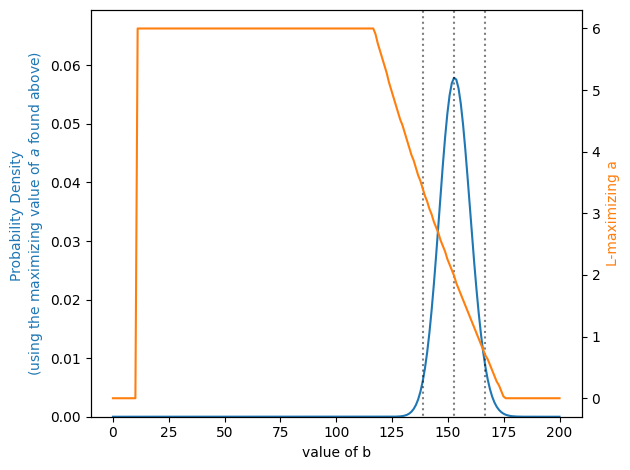

Lower bound for the expectation on signal box data:  1336.5036465813312
Upper bound for the expectation on signal box data:  1601.607899806327
Central value expectation on signal box data:  1468.9482635481374
popt:  4.360894098266973e-15 ,  156.8139926633587


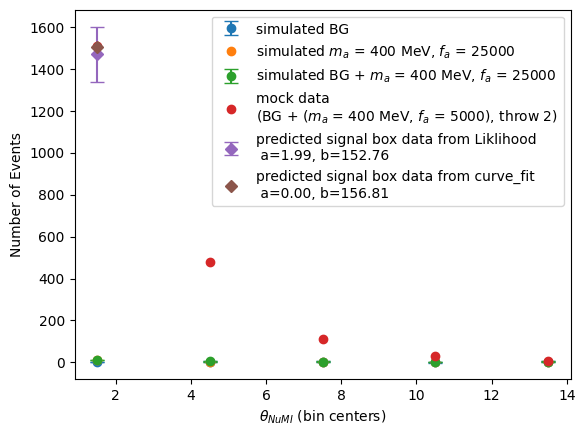

In [41]:

run_L_fitter(md_hisigbg_1, 'BG+SIG_400MeV_fa5000 MOCK DATA SET #1', 
             '(BG + ($m_a$ = 400 MeV, $f_a$ = 5000), throw 1)',
             signal_mc_ma400, '$m_a$ = 400 MeV, $f_a$ = 25000', 
             b_list_min=0, b_list_max=200,
             plot_L_ProbDist=True
            )
run_L_fitter(md_hisigbg_2, 'BG+SIG_400MeV_fa5000 MOCK DATA SET #2', 
             '(BG + ($m_a$ = 400 MeV, $f_a$ = 5000), throw 2)',
             signal_mc_ma400, '$m_a$ = 400 MeV, $f_a$ = 25000', 
             b_list_min=0, b_list_max=200,
             plot_L_ProbDist=True
            )


In [ ]:
# SCRATCH
# ~~~~~~~

grid_size = 200
a_list = np.linspace(0,3,grid_size)
b_list = np.linspace(-10,10,grid_size)

# DEFINE THE LIKLIHOOD:

def L(x,a,b):
    return (poisson.pmf(x[1],a * bg_mc[1] + b * signal_mc[1]) * poisson.pmf(x[2],a * bg_mc[2] + b * signal_mc[2]) 
            * norm.pdf(a,np.mean(bg_mc[:3]),np.mean(bg_mc_err[:3]))) # second peice makes the fit less likely to inflate a in case of excess.
# 2/3 mean ~matches number of events per degree. 
# For my mean, I should just use the CV of the bin, and for my SD I should use the error in my bins.
# a is the bg normalization; b is the signal normalization.
# x is the mock data (just two bins for sideband!)

# GET THE PROFILE LIKLIHOOD:

ydata = md_bg_1[1:3] 
prof_L = []
a_max = []
for b in b_list:
    this_pl = 0.
    this_a = 0.
    for a in a_list:
        if L(md_bg_1,a,b) > this_pl:
            this_pl = L(md_bg_1,a,b)
            this_a = a
    a_max.append(this_a)
    prof_L.append(this_pl)
a_max = np.array(a_max) # a that maximizes liklihood, for each b. a is a nuisance parameter.
prof_L = np.array(prof_L) # the maximized L, for each b.

# TURN THE PROFILE LIKLIHOOD INTO A PROBABILITY DISTRIBUTION FUNCTION:

prof_L_int = interp1d(b_list,prof_L) # Returns a function whose call method uses interpolation to find the value of new points.
norm_prof_L = quad(prof_L_int,-10,10)[0]

def prob_prof_L(b): # normalized probability distribution for L.
    return prof_L_int(b) / norm_prof_L

# FIND THE 95% CL UPPER BOUND ON B:

right_half_integral = quad(prob_prof_L, b_max_L, b_list[-1])[0]
print(right_half_integral)
# If things were behaving on left side, and we integrated from true peak, this would equal 0.5. 
integrated_fromHalf_L = []
for i in range(max_L_ind,grid_size):
    integrated_fromHalf_L.append(quad(prob_prof_L, b_max_L, b_list[i])[0])
b_upper_bound = b_list[max_L_ind + np.argmin(np.abs(np.array(integrated_fromHalf_L)/right_half_integral - 0.95))] # 95% sure true b is between lower bound (in this case zero) and this value.
print('upper bound on b: ', b_upper_bound)

# PLOT THE PROBABILITY DENSITY:

#print(prob_prof_L(b_list[5]))
prob_dens = np.array([prob_prof_L(b) for b in b_list])
plt.plot(b_list, prob_dens)
plt.xlim(-11, 11)
plt.ylim(0,1.2*max(prob_dens))
plt.ylabel('Probability Density \n(using the maximizing value of a found above)')
max_L_ind = np.where(prob_dens == np.max(prob_dens))[0][0]
b_max_L = b_list[max_L_ind]
plt.vlines([b_max_L, b_upper_bound], -5, 1, color='black', linestyle=':', alpha=0.5)
plt.xlabel('value of b')
plt.show()
# should integrate to 1.

# CHECK YOUR UPPER AND LOWER BOUNDS ON B FOR THE 95% CL:

# What we have now: We are 95% certain that the values of b lie between 0 and b_upper_bound.

expectation_low = sigBox_pred(a_max[np.argmin(np.abs(b_list))], 0) #a_max[np.argmin(np.abs(b_list))]*bg_mc[0]
print('Lower bound for the expectation on signal box data: ', expectation_low)

expectation_high =  sigBox_pred(a_max[np.where(b_list==b_upper_bound)], b_upper_bound)[0]
print('Upper bound for the expectation on signal box data: ', expectation_high)

expectation_cv = sigBox_pred(a_max[np.where(b_list==b_max_L)], b_max_L)[0]
print('Central value expectation on signal box data: ', expectation_cv)

# FIND THE MIN, MAX, AND MOST LIKELY EXPECTATION FOR WHAT WE'D SEE IN THE SIGNAL BOX:
# These values correspond to the #_events you'd get from a*bg+b*signal for the b_lower_bound, b_upper_bound, and b_max_L (all used with their corresponding a value that maximizes L for that b)
# TODO: Double check that logic. Yep, it's true! (see plot.)

def sigBox_pred(a,b):
    return a*bg_mc[0] + b*signal_mc[0]

plt.scatter(b_list, [sigBox_pred(a,b) for a,b in zip(a_max, b_list)])
plt.scatter([0,b_max_L,b_upper_bound], [expectation_low, expectation_cv, expectation_high])
plt.ylabel('Predicted # Evts in Signal Box \ngiven b & corrsp. a_max_L')
plt.xlabel('value of b')
plt.show()

In [ ]:
# More sophisticated way using chi2, and no functional forms for the signal and B:

In [25]:
# First, make mock data sets:
#    'md'=='mock data'

# background_only
md_bg_1 = np.random.normal(loc=bg_mc, scale=bg_mc_err)
md_bg_2 = np.random.normal(loc=bg_mc, scale=bg_mc_err)
md_bg_1[md_bg_1<0]=0. # set any negative values to zero
md_bg_2[md_bg_2<0]=0.

# bg+signal_near_sensitivity_limit_400MeV
md_sigbg_1 = np.random.normal(loc=combined_sig_bg, scale=combined_mc_err)
md_sigbg_1[md_sigbg_1<0]=0.
md_sigbg_2 = np.random.normal(loc=combined_sig_bg, scale=combined_mc_err)
md_sigbg_2[md_sigbg_2<0]=0.

# bg+signal_at_high_sensitivity_400MeV
#combined_sig_bg_highSignal, combined_mc_err_highSignal = xx[:2]
md_hisigbg_1 = np.random.normal(loc=combined_sig_bg_highSignal, scale=combined_mc_err_highSignal)
md_hisigbg_1[md_hisigbg_1<0]=0.
md_hisigbg_2 = np.random.normal(loc=combined_sig_bg_highSignal, scale=combined_mc_err_highSignal)
md_hisigbg_2[md_hisigbg_2<0]=0.


In [64]:
print(len(combined_sig_bg))
print(len(combined_sig_bg_highSignal))

5
5


In [74]:
bin_centers = (returned_bins[0:-1]+returned_bins[1:])/2.
print('\n',bin_centers)


 [ 1.5  4.5  7.5 10.5 13.5]


FIT TO 'BG_ONLY MOCK DATA SET #1': 
Optimal parameters (A = BG normalization, B = signal normalization): [1.27553197 0.13305971]
These parameters minmize the chi2 for a comparison of the mock data to an estimator 
           for the number of counts in each bin: N|expected_signal = A+expected_BG + B*expected_signal
(Fitting to this signal model expectation: $m_a$ = 400 MeV, $f_a$ = 25000)
(Both parameters are constrained to A,B >= 0.)
Covariance: 
 [[inf inf]
 [inf inf]]

Comparison of mock data to simulated BG-only:
Chi-squared value: 0.5269638596221278
p-value given 2 dof:  0.7683715069320838





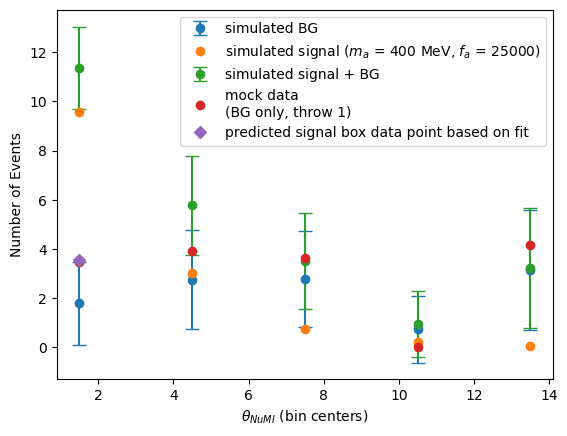

FIT TO 'BG_ONLY MOCK DATA SET #2': 
Optimal parameters (A = BG normalization, B = signal normalization): [2.99127781e-10 1.50207645e+00]
These parameters minmize the chi2 for a comparison of the mock data to an estimator 
           for the number of counts in each bin: N|expected_signal = A+expected_BG + B*expected_signal
(Fitting to this signal model expectation: $m_a$ = 400 MeV, $f_a$ = 25000)
(Both parameters are constrained to A,B >= 0.)
Covariance: 
 [[inf inf]
 [inf inf]]

Comparison of mock data to simulated BG-only:
Chi-squared value: 3.105873705689097
p-value given 2 dof:  0.2116255471961452





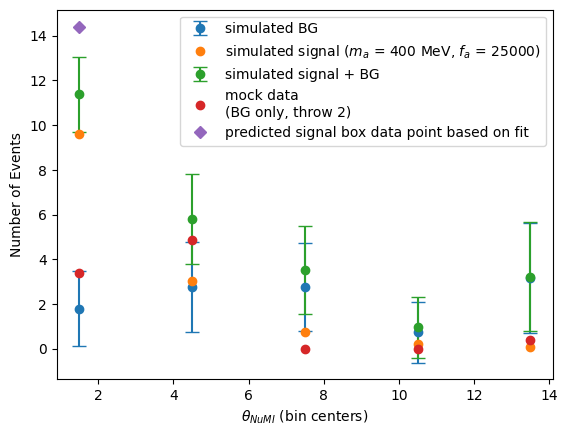

FIT TO 'BG+SIG_400MeV_fa25000 MOCK DATA SET #1': 
Optimal parameters (A = BG normalization, B = signal normalization): [1.42631914 0.51771759]
These parameters minmize the chi2 for a comparison of the mock data to an estimator 
           for the number of counts in each bin: N|expected_signal = A+expected_BG + B*expected_signal
(Fitting to this signal model expectation: $m_a$ = 400 MeV, $f_a$ = 25000)
(Both parameters are constrained to A,B >= 0.)
Covariance: 
 [[inf inf]
 [inf inf]]

Comparison of mock data to simulated BG-only:
Chi-squared value: 2.5008352733617465
p-value given 2 dof:  0.2863851669304374





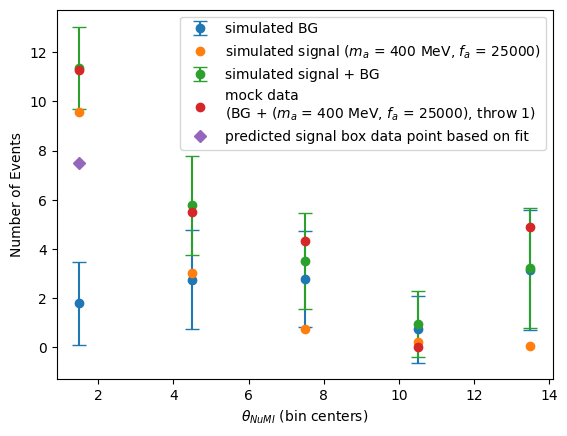

FIT TO 'BG+SIG_400MeV_fa25000 MOCK DATA SET #2': 
Optimal parameters (A = BG normalization, B = signal normalization): [1.50134059 0.24303257]
These parameters minmize the chi2 for a comparison of the mock data to an estimator 
           for the number of counts in each bin: N|expected_signal = A+expected_BG + B*expected_signal
(Fitting to this signal model expectation: $m_a$ = 400 MeV, $f_a$ = 25000)
(Both parameters are constrained to A,B >= 0.)
Covariance: 
 [[inf inf]
 [inf inf]]

Comparison of mock data to simulated BG-only:
Chi-squared value: 1.7481312222546712
p-value given 2 dof:  0.4172517129453056





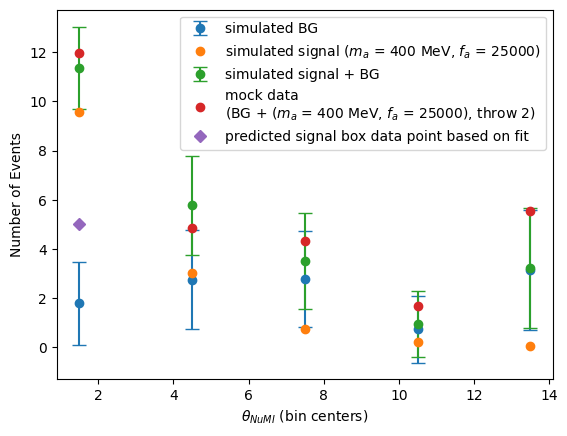

FIT TO 'BG+SIG_400MeV_fa5000 MOCK DATA SET #1': 
Optimal parameters (A = BG normalization, B = signal normalization): [8.37978357e-20 1.58515460e+02]
These parameters minmize the chi2 for a comparison of the mock data to an estimator 
           for the number of counts in each bin: N|expected_signal = A+expected_BG + B*expected_signal
(Fitting to this signal model expectation: $m_a$ = 400 MeV, $f_a$ = 5000)
(Both parameters are constrained to A,B >= 0.)
Covariance: 
 [[inf inf]
 [inf inf]]

Comparison of mock data to simulated BG-only:
Chi-squared value: 60121.64058196375
p-value given 2 dof:  0.0





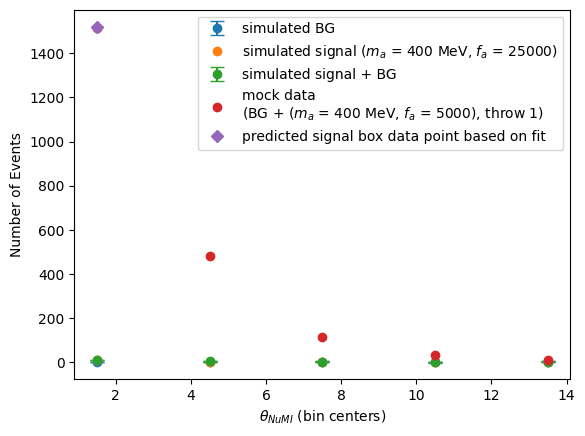

FIT TO 'BG+SIG_400MeV_fa5000 MOCK DATA SET #2': 
Optimal parameters (A = BG normalization, B = signal normalization): [3.90330989e-20 1.58331696e+02]
These parameters minmize the chi2 for a comparison of the mock data to an estimator 
           for the number of counts in each bin: N|expected_signal = A+expected_BG + B*expected_signal
(Fitting to this signal model expectation: $m_a$ = 400 MeV, $f_a$ = 5000)
(Both parameters are constrained to A,B >= 0.)
Covariance: 
 [[inf inf]
 [inf inf]]

Comparison of mock data to simulated BG-only:
Chi-squared value: 59981.899656547306
p-value given 2 dof:  0.0





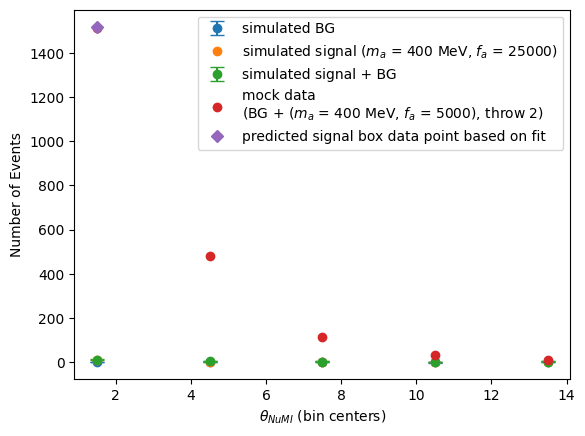

In [36]:
bg_to_fit = bg_mc[1:3]
from scipy.stats import chi2

def fit_model(signal_exp, A, B): 
    # Function to describe the number of events you'll count by bin, 
    # considering BG normalization A and signal normalization B.
    # Signal_exp must be the 3-6deg and 6-9deg bins of the signal B.M. you are testing.
    # The background should be fixed to whatever our (singular) MC expectation for the background is.
    # We have to choose some signal benchmark to do the fit w.r.t (presumably, one per mass).
    return (A*bg_to_fit)+(B*signal_exp)

def run_fitter(mockdata, ydata_descriptor, sig_to_fit_to, sig_to_fit_to_descriptor, shorthand_ydata_descriptor=''):
    ydata = mockdata[1:3] # mock data to fit.
    initial_guesses = [1, 1]
    my_yerr = combined_mc_err[1:3]
    popt, pcov = curve_fit(fit_model, sig_to_fit_to, ydata, p0=initial_guesses, sigma=my_yerr, 
                           bounds=([0,0],[10, 10000]))#, method='dogbox') # (from scipy) # bounds=([0,0],[np.inf, np.inf])

    print('FIT TO %a: ' % ydata_descriptor)
    print(f"Optimal parameters (A = BG normalization, B = signal normalization): {popt}")
    print('These parameters minmize the chi2 for a comparison of the mock data to an estimator \n \
          for the number of counts in each bin: N|expected_signal = A+expected_BG + B*expected_signal')
    print('(Fitting to this signal model expectation: '+sig_to_fit_to_descriptor+')')
    print('(Both parameters are constrained to A,B >= 0.)')
    print('Covariance: \n', pcov)
    print('')

    ## Level of agreement from fit, ie. between mock data and A+expected_BG + B*expected_signal:
    #residuals = ydata - fit_model(sig_to_fit_to, *popt)
    #chi_squared = np.sum((residuals / my_yerr)**2)
    #print(f"Minimized Chi-squared value: {chi_squared}")
    #p_value_upper = chi2.sf(chi_squared, 2) # For an upper-tailed test (most common in Chi-squared tests)
    #print('p-value given 2 dof: ', p_value_upper) 
    #print('')
    
    # But that level of agreement isn't that interesting. 
    # What we want to know is level of agreement between mock data and BG_only!
    # Ordered logic for analysis:
    # - check this level agreement. 
    # - if poor agreement (small p-value), then probably have signal, and the fitter should predict that signal reasonably well.
    # - if good agreement (large p-value), then data is consistent with BG prediction in sideband. 
    #   Fitter wouldn't predict signal box spike even if signal was there.
    #   But, it is still possible to see a little excess in signal box if some lower-rate signal is there.
    print('Comparison of mock data to simulated BG-only:')
    residuals = ydata - bg_to_fit
    chi_squared = np.sum((residuals / bg_mc_err[1:3])**2)
    print(f"Chi-squared value: {chi_squared}")
    p_value_upper = chi2.sf(chi_squared, 2) # For an upper-tailed test (most common in Chi-squared tests)
    print('p-value given 2 dof: ', p_value_upper) # For an upper-tailed test (most common in Chi-squared tests)
    print('')
    
    print('')
    
    bin_centers = (returned_bins[0:-1]+returned_bins[1:])/2.
    bin_half_width = returned_bins[1]-bin_centers[0]
    
    mycapsize = 5
    plt.errorbar(bin_centers, bg_mc, yerr=bg_mc_err, fmt='o', label='simulated BG', capsize=mycapsize) #, xerr=bin_half_width
    #plt.scatter(bin_centers, bg_mc, marker='o', label='simulated BG')
    plt.errorbar(bin_centers, combined_sig_bg-bg_mc, fmt='o', 
                label='simulated signal ($m_a$ = 400 MeV, $f_a$ = 25000)', capsize=mycapsize)
    plt.errorbar(bin_centers, combined_sig_bg, yerr=combined_mc_err, fmt='o',
                label='simulated signal + BG', capsize=mycapsize)
    print()
    plt.errorbar(bin_centers, mockdata, fmt='o', color='C3', label='mock data\n'+shorthand_ydata_descriptor)
    plt.errorbar(bin_centers[0], popt[0]*bg_mc[0] + popt[1]*(combined_sig_bg[0]-bg_mc[0]), fmt='D', 
                label='predicted signal box data point based on fit', color='C4')
    plt.legend()
    plt.xlabel('$\\theta_{NuMI}$ (bin centers)')
    plt.ylabel('Number of Events')
    plt.show()
    
    return

sig_to_fit = (combined_sig_bg[1:3]-bg_to_fit) # signal expectation for m_a = 400 MeV, fa = 25000

run_fitter(md_bg_1, 'BG_ONLY MOCK DATA SET #1', sig_to_fit, '$m_a$ = 400 MeV, $f_a$ = 25000',
          shorthand_ydata_descriptor='(BG only, throw 1)')
run_fitter(md_bg_2, 'BG_ONLY MOCK DATA SET #2', sig_to_fit, '$m_a$ = 400 MeV, $f_a$ = 25000', 
          shorthand_ydata_descriptor='(BG only, throw 2)')

run_fitter(md_sigbg_1, 'BG+SIG_400MeV_fa25000 MOCK DATA SET #1', sig_to_fit, '$m_a$ = 400 MeV, $f_a$ = 25000',
          shorthand_ydata_descriptor='(BG + ($m_a$ = 400 MeV, $f_a$ = 25000), throw 1)')
run_fitter(md_sigbg_2, 'BG+SIG_400MeV_fa25000 MOCK DATA SET #2', sig_to_fit, '$m_a$ = 400 MeV, $f_a$ = 25000',
          shorthand_ydata_descriptor='(BG + ($m_a$ = 400 MeV, $f_a$ = 25000), throw 2)')

run_fitter(md_hisigbg_1, 'BG+SIG_400MeV_fa5000 MOCK DATA SET #1', sig_to_fit, '$m_a$ = 400 MeV, $f_a$ = 5000',
          shorthand_ydata_descriptor='(BG + ($m_a$ = 400 MeV, $f_a$ = 5000), throw 1)')
run_fitter(md_hisigbg_2, 'BG+SIG_400MeV_fa5000 MOCK DATA SET #2', sig_to_fit, '$m_a$ = 400 MeV, $f_a$ = 5000',
          shorthand_ydata_descriptor='(BG + ($m_a$ = 400 MeV, $f_a$ = 5000), throw 2)')


### Takeaways: 

- Ability to predict signal box bin for BG_only or for BG+small_signal is not super powerful (sometimes succeeds, sometimes fails for both cases.).
- Ability to predict signal box bin in case of strong signal is powerful.


In [ ]:
# example:

import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# 1. Define the model function (e.g., a Gaussian function)
def gaussian(x, amp, cen, wid):
    return amp * np.exp(-(x - cen)**2 / wid)

# 2. Generate some sample data with noise and errors
x = np.linspace(-10, 10, 101)
# True parameters: amp=2.33, cen=0.21, wid=1.51
y_true = gaussian(x, 2.33, 0.21, 1.51)
yerr = np.full_like(y_true, 0.2) # Assuming a constant error
ydata = y_true + np.random.normal(0, yerr[0], x.size)

# 3. Perform the fit
initial_guesses = [1, 0, 1] # Initial guess for [amp, cen, wid]
# popt contains the optimized parameters, pcov is the covariance matrix
popt, pcov = curve_fit(gaussian, x, ydata, p0=initial_guesses, sigma=yerr)

print(f"Optimal parameters (amplitude, center, width): {popt}")

# To get the final minimized chi-squared value
residuals = ydata - gaussian(x, *popt)
chi_squared = np.sum((residuals / yerr)**2)
print(f"Minimized Chi-squared value: {chi_squared}")



In [89]:
# example: getting a p-value

from scipy.stats import chi2

# --- Input your values ---
chi2_value = 15.51 # Your calculated Chi-squared statistic
dof = 5          # Your degrees of freedom

# --- Calculate the p-value ---
# For an upper-tailed test (most common in Chi-squared tests)
p_value_upper = chi2.sf(chi2_value, dof)
# Or using the CDF (Cumulative Distribution Function)
p_value_cdf = 1 - chi2.cdf(chi2_value, dof)

print(f"Chi-squared value: {chi2_value}")
print(f"Degrees of freedom: {dof}")
print(f"P-value (Survival Function): {p_value_upper}") # {Link: Stack Overflow https://stackoverflow.com/questions/11725115/p-value-from-chi-sq-test-statistic-in-python}
print(f"P-value (CDF): {p_value_cdf}") # {Link: Minitab https://support.minitab.com/en-us/minitab/help-and-how-to/statistics/basic-statistics/supporting-topics/basics/manually-calculate-a-p-value/}

# Example of two-tailed test (less common for Chi-squared but for illustration)
# p_value_two_tailed = 2 * chi2.sf(chi2_value, dof) if chi2_value > 0 else 1 # Simplified logic
# print(f"P-value (Two-tailed): {p_value_two_tailed}")



Chi-squared value: 15.51
Degrees of freedom: 5
P-value (Survival Function): 0.00839161824955454
P-value (CDF): 0.008391618249554589


In [ ]:
# Very rudimentary first approach I worked on Jan. 26, '26:



In [124]:
import numpy as np
from scipy.odr import ODR, Model, Data, RealData
import matplotlib.pyplot as plt

def poly_sigPLUSbg_model(B, x):
    return B[0] / x**B[1]

def poly_bg_model(B, x):
    return B[0]*x + B[1]



In [125]:
myxerr

1.5

[ 1.5  4.5  7.5 10.5 13.5]


NameError: name 'RealData' is not defined

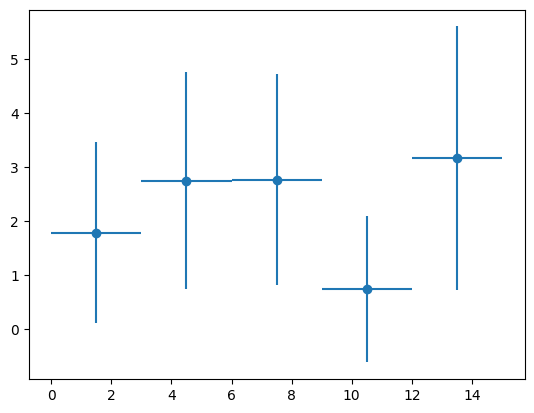

In [35]:
# PERFORM FITS

# background

bin_points = (returned_bins[:-1]+returned_bins[1:])/2.
print(bin_points)
myxerr = (returned_bins[1]-returned_bins[0])/2.
plt.errorbar(bin_points, bg_mc, fmt='o', yerr=bg_mc_err, xerr=myxerr, label='signal + BG')
data = RealData(bin_points[:-1], bg_mc[:-1], sx=myxerr, sy=bg_mc_err[:-1])

myodr = ODR(data, Model(poly_bg_model), beta0=[0., 3.])
myoutput = myodr.run()
print('\nBG Only Fit to $$A*x+B$$:')
print(f"Fitted parameters: {myoutput.beta}")
print(f"Parameter errors: {myoutput.sd_beta}")
plt.plot(bin_points[:-1], poly_bg_model(myoutput.beta, bin_points)[:-1], color='C0', linestyle=':', label='fit to $y=A*x+B$')

myodr = ODR(data, Model(poly_sigPLUSbg_model), beta0=[3., 0.])
myoutput = myodr.run()
#print(f"\nFitted parameters: {myoutput.beta}")
#print(f"Parameter errors: {myoutput.sd_beta}")
plt.plot(bin_points[:-1], poly_sigPLUSbg_model(myoutput.beta, bin_points)[:-1], color='C0', linestyle='--', label='fit to $y=A/x^B$')


# signal + background

plt.errorbar(bin_points, combined_sig_bg, fmt='o', yerr=combined_mc_err, xerr=myxerr, label='BG only')
data = RealData(bin_points[:-1], combined_sig_bg[:-1], sx=myxerr, sy=combined_mc_err[:-1])

myodr = ODR(data, Model(poly_bg_model), beta0=[-5., 15.])
myoutput = myodr.run()
#print(f"\nFitted parameters: {myoutput.beta}")
#print(f"Parameter errors: {myoutput.sd_beta}")
plt.plot(bin_points[:-1], poly_bg_model(myoutput.beta, bin_points)[:-1], color='C1', linestyle=':', label='fit to $y=A*x+B$')

myodr = ODR(data, Model(poly_sigPLUSbg_model), beta0=[10., 1.])
myoutput = myodr.run()
#myoutput.pprint()
#fitted_params = myoutput.beta
#param_errors = myoutput.sd_beta
print('\nSignal + BG Fit to $$A/x^B$$:')
print(f"Fitted parameters: {myoutput.beta}")
print(f"Parameter errors: {myoutput.sd_beta}")
plt.plot(bin_points[:-1], poly_sigPLUSbg_model(myoutput.beta, bin_points)[:-1], color='C1', linestyle='--', label='fit to $y=A/x^B$')

plt.legend()
plt.show()

VERIFY THAT THIS NUMBER IS TWO (1 nominal nu sample, and any number of cohlike samples (whose POTs get combined), for a total of 2 POT scalings):  2
dE/dx <= 50 MeV/cm up to 0_5 cm
dE/dx <= 35 MeV/cm 0_5-1 cm
dE/dx <= 15 MeV/cm 1-2 cm
dE/dx <= 10 MeV/cm 2-3 cm
max shower len < 0.0 cm
contained trk chi2mu < 8
opening angle < 25 deg
shorter of tracks > 100.0 cm


/tmp/ipykernel_3884901/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_3884901/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_3884901/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_3884901/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_3884901/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_3884901/368690949.py:56: RuntimeWarning: invalid value encountered in divide
  cut_results

len(unq):  2
$M_{ALP}$ = 400, $c$ = 6.5*10^-4, $fa$ = 25000


/tmp/ipykernel_3884901/1800830918.py:314: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  mc_stat_err = float(df[bsm_cat].iloc[[0]].scale)*np.sqrt(mc_bin_nevents) # TODO_JAN_7: fix to include CV weights, and rwt_to_good_bm


$M_{ALP}$ = 400, $c$ = 4.9*10^-4, $fa$ = 5000


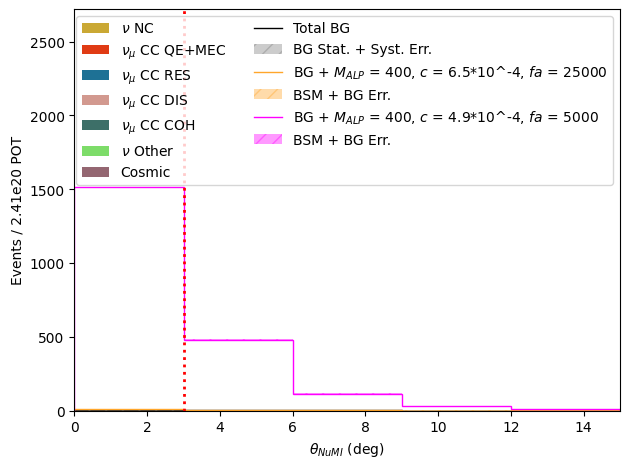

Total number of (POT-normalized) simulated background events in plot: '11.2'
Total uncertainty on simulated background events in plot: ±'4.3'
Total number of (POT-normalized) simulated signal events in plot: '2.14e+03'
Total uncertainty on simulated signal events in plot: ±'8.28e-06'


In [23]:
# SIDEBAND AND SIGNAL BOX!
xx = makeplot_toFit(evtdf, evtdf.Snumi_angle_hybrid_rangeCorrectedMCS*180./math.pi,
             mccoh_syst_evtdfs, mccoh_dv_vars,
             (0,15.), bins=5, vline=[3.],
             xlabel = "$\\theta_{NuMI}$ (deg)", detailed_nu="int_type",
             ratio_bounds=[0.,2.], plotname='theta_NuMI',
             textOnPlot = 'n-1 cuts of Selection DD applied. \n(not currently using all avail. cohlike evts)',
             #textOnPlot = 'Selection J applied. \n(not currently using all avail. cohlike evts)',
             bsm_index=9,
             rwt_alp=True,
             fwt_bsm_to_high_prob_bench = True,
             bsm_detector_varis_vars=0,
             bsm_magnifier = 10000,
             evtSel_key='J',
             do_detector_variations=True, 
             print_cuts = True #, do_subplot = False
            
        )


In [24]:
combined_sig_bg_highSignal, combined_mc_err_highSignal = xx[-2:]



In [116]:
total_mc_bg_err_in_plot, returned_bins, bg_mc, bg_mc_err, combined_sig_bg, combined_mc_err = xx



[ 1.5  4.5  7.5 10.5 13.5]

BG Only Fit to $$A*x+B$$:
Fitted parameters: [ 2.62717891 -0.13499935]
Parameter errors: [1.06460996 0.14074678]

Signal + BG Fit to $$A/x^B$$:
Fitted parameters: [2.18187219e+03 1.73138381e+00]
Parameter errors: [3.37313181e+03 6.83772150e-01]


/tmp/ipykernel_2046553/562677913.py:6: RuntimeWarning: invalid value encountered in power
  return B[0] / x**B[1]


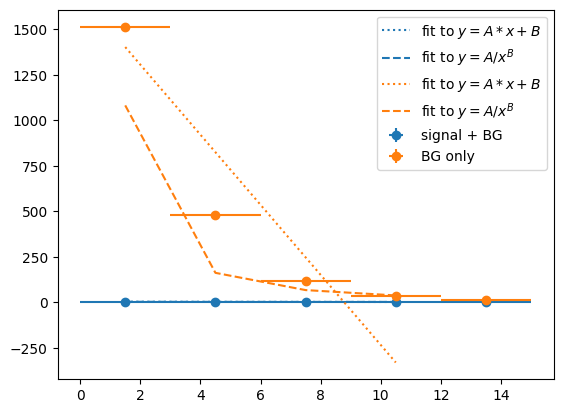

In [120]:
# PERFORM FITS

# background

bin_points = (returned_bins[:-1]+returned_bins[1:])/2.
print(bin_points)
myxerr = (returned_bins[1]-returned_bins[0])/2.
plt.errorbar(bin_points, bg_mc, fmt='o', yerr=bg_mc_err, xerr=myxerr, label='signal + BG')
data = RealData(bin_points[:-1], bg_mc[:-1], sx=myxerr, sy=bg_mc_err[:-1])

myodr = ODR(data, Model(poly_bg_model), beta0=[0., 3.])
myoutput = myodr.run()
print('\nBG Only Fit to $$A*x+B$$:')
print(f"Fitted parameters: {myoutput.beta}")
print(f"Parameter errors: {myoutput.sd_beta}")
plt.plot(bin_points[:-1], poly_bg_model(myoutput.beta, bin_points)[:-1], color='C0', linestyle=':', label='fit to $y=A*x+B$')

myodr = ODR(data, Model(poly_sigPLUSbg_model), beta0=[1., 0.])
myoutput = myodr.run()
#print(f"\nFitted parameters: {myoutput.beta}")
#print(f"Parameter errors: {myoutput.sd_beta}")
plt.plot(bin_points[:-1], poly_sigPLUSbg_model(myoutput.beta, bin_points)[:-1], color='C0', linestyle='--', label='fit to $y=A/x^B$')


# signal + background

plt.errorbar(bin_points, combined_sig_bg, fmt='o', yerr=combined_mc_err, xerr=myxerr, label='BG only')
data = RealData(bin_points[:-1], combined_sig_bg[:-1], sx=myxerr, sy=combined_mc_err[:-1])

myodr = ODR(data, Model(poly_bg_model), beta0=[-500, 2000.])
myoutput = myodr.run()
#print(f"\nFitted parameters: {myoutput.beta}")
#print(f"Parameter errors: {myoutput.sd_beta}")
plt.plot(bin_points[:-1], poly_bg_model(myoutput.beta, bin_points)[:-1], color='C1', linestyle=':', label='fit to $y=A*x+B$')

myodr = ODR(data, Model(poly_sigPLUSbg_model), beta0=[1000., 1.])
myoutput = myodr.run()
#myoutput.pprint()
#fitted_params = myoutput.beta
#param_errors = myoutput.sd_beta
print('\nSignal + BG Fit to $$A/x^B$$:')
print(f"Fitted parameters: {myoutput.beta}")
print(f"Parameter errors: {myoutput.sd_beta}")
plt.plot(bin_points[:-1], poly_sigPLUSbg_model(myoutput.beta, bin_points)[:-1], color='C1', linestyle='--', label='fit to $y=A/x^B$')

plt.legend()
plt.show()

brainstorming ideas to hone in on CC Coh:
- pion PID score
- slices with a contained track (tested this by requiring ndaughters_per_conTrk < 0. Result: too much signal, and still not enough CC Coh Pi)
- (would require a different preselection:) shorter contained tracks.
- kink in pion track
- difference in PID scores between the two tracks. (doubt this would work)
- study events with 1mu1pi1p(stub). Assume that if those are well reconstructed and modeled, then so are the 1mu1pi events.

[-1  0  1  2  3  4  5]


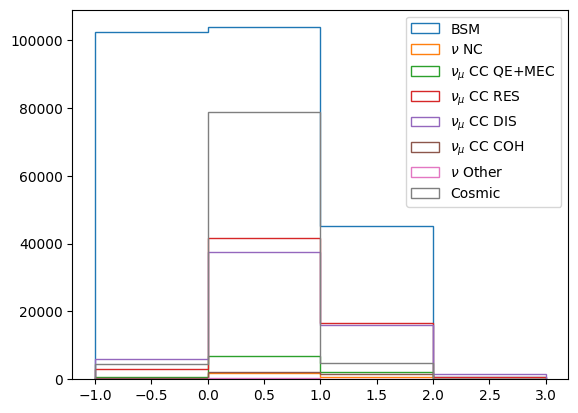

In [98]:
for c in make_categories(evtdf, detailed_bsm=False, detailed_nu='int_type'):
    plt.hist(evtdf[c].conTrk_nDaughters, bins=4, range=(-1,3), label=c.name, histtype='step')#, density=True)
plt.legend()
plt.show
print(np.unique(evtdf.conTrk_nDaughters))

/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results

/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results

/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results

VERIFY THAT THIS NUMBER IS TWO (1 cohlike sample + 1 nominal sample, for two different POT scalings):  2


/tmp/ipykernel_4091925/3186042509.py:274: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  weights = df[bsm_cat].scale*df[bsm_cat].wgt.cv,
/tmp/ipykernel_4091925/3186042509.py:280: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  mc_stat_err = float(df[bsm_cat].iloc[[0]].scale)*np.sqrt(mc_bin_nevents)


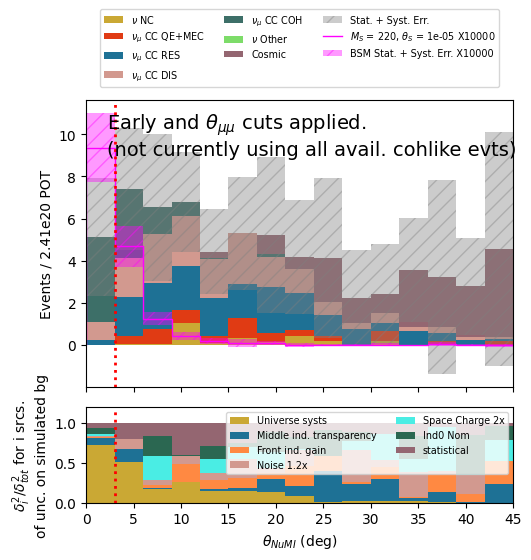

Total number of (POT-normalized) simulated background events in plot: '67.9'
Total uncertainty on simulated background events in plot: ±'46'
Total number of (POT-normalized) simulated signal events in plot: '0.00163'
Total uncertainty on simulated signal events in plot: ±'0.000395'


In [45]:
# Explore Sideband Defined as Flipped theta_NuMI

bsm_detector_varis_vars = []
for bsm_sample in bsm_detector_varis_dfs:
    this_samples_vars = []
    for detect_variation_df in bsm_sample:
        this_samples_vars.append(detect_variation_df.Snumi_angle_wgtByLen*180./math.pi)
    bsm_detector_varis_vars.append(this_samples_vars)
        
makeplot(evtdf, evtdf.Snumi_angle_wgtByLen*180./math.pi,
         mccoh_syst_evtdfs, [sdf.Snumi_angle_wgtByLen*180./math.pi for sdf in mccoh_syst_evtdfs],
         (0,45.), bins=15, vline=[3.], xlabel = "$\\theta_{NuMI}$ (deg)", detailed_nu="int_type",
         ratio_bounds=[0.,2.], plotname='theta_NuMI',
         textOnPlot = 'Early and $\\theta_{\mu\mu}$ cuts applied. \n(not currently using all avail. cohlike evts)',
         bsm_index=0,
         bsm_detector_varis_vars=bsm_detector_varis_vars,
         bsm_magnifier = 10000,
         evtSel_key='J'
        )

/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results

/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results

/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results

VERIFY THAT THIS NUMBER IS TWO (1 cohlike sample + 1 nominal sample, for two different POT scalings):  2


/tmp/ipykernel_4091925/3186042509.py:274: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  weights = df[bsm_cat].scale*df[bsm_cat].wgt.cv,
/tmp/ipykernel_4091925/3186042509.py:280: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  mc_stat_err = float(df[bsm_cat].iloc[[0]].scale)*np.sqrt(mc_bin_nevents)


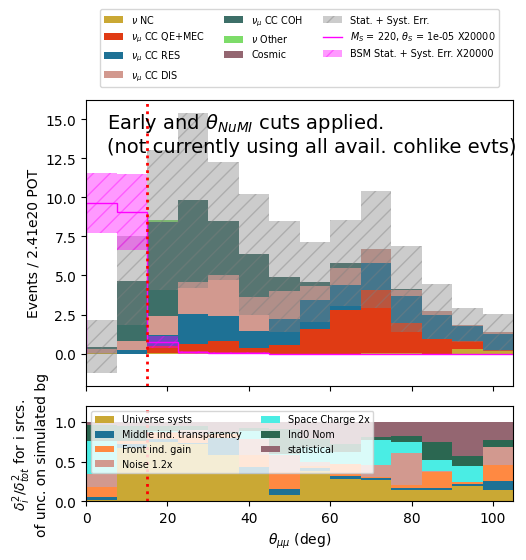

Total number of (POT-normalized) simulated background events in plot: '70.3'
Total uncertainty on simulated background events in plot: ±'41.7'
Total number of (POT-normalized) simulated signal events in plot: '0.00098'
Total uncertainty on simulated signal events in plot: ±'0.00025'


In [44]:
# Explore Sideband Defined as Flipped theta_mumu

bsm_detector_varis_vars = []
for bsm_sample in bsm_detector_varis_dfs:
    this_samples_vars = []
    for detect_variation_df in bsm_sample:
        this_samples_vars.append(detect_variation_df.opening_angle*180./math.pi)
    bsm_detector_varis_vars.append(this_samples_vars)
        
makeplot(evtdf, evtdf.opening_angle*180./math.pi,
         mccoh_syst_evtdfs, [sdf.opening_angle*180./math.pi for sdf in mccoh_syst_evtdfs],
         (0,105.), bins=14, vline=[15.], xlabel = "$\\theta_{\mu\mu}$ (deg)", detailed_nu="int_type",
         ratio_bounds=[0.,2.], plotname='theta_mumu',
         textOnPlot = 'Early and $\\theta_{NuMI}$ cuts applied. \n(not currently using all avail. cohlike evts)',
         bsm_index=0,
         bsm_detector_varis_vars=bsm_detector_varis_vars,
         bsm_magnifier = 20000,
         evtSel_key='K'
        )


/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results

/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results

/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
/tmp/ipykernel_4091925/255388292.py:52: RuntimeWarning: invalid value encountered in divide
  cut_results

VERIFY THAT THIS NUMBER IS TWO (1 cohlike sample + 1 nominal sample, for two different POT scalings):  2


/tmp/ipykernel_4091925/3186042509.py:160: RuntimeWarning: invalid value encountered in divide
  frac_cohlike_bybin = np.array(cohlike_hist[0]/mc)
/tmp/ipykernel_4091925/3186042509.py:274: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  weights = df[bsm_cat].scale*df[bsm_cat].wgt.cv,
/tmp/ipykernel_4091925/3186042509.py:280: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  mc_stat_err = float(df[bsm_cat].iloc[[0]].scale)*np.sqrt(mc_bin_nevents)


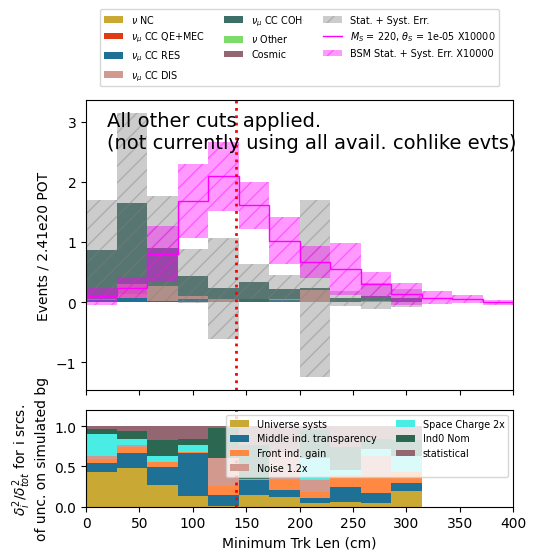

Total number of (POT-normalized) simulated background events in plot: '5.11'
Total uncertainty on simulated background events in plot: ±'6.96'
Total number of (POT-normalized) simulated signal events in plot: '0.000934'
Total uncertainty on simulated signal events in plot: ±'0.000403'


In [52]:
# Explore Sideband wrt Track Length

bsm_detector_varis_vars = []
for bsm_sample in bsm_detector_varis_dfs:
    this_samples_vars = []
    for detect_variation_df in bsm_sample:
        this_samples_vars.append(detect_variation_df.shorter_track_length)
    bsm_detector_varis_vars.append(this_samples_vars)
        
makeplot(evtdf, evtdf.shorter_track_length,
         mccoh_syst_evtdfs, [sdf.shorter_track_length for sdf in mccoh_syst_evtdfs],
         (0,400.), bins=14, vline=[140.0], xlabel = "Minimum Trk Len (cm)", detailed_nu="int_type",
         ratio_bounds=[0.,2.], plotname='trkLen',
         textOnPlot = 'All other cuts applied. \n(not currently using all avail. cohlike evts)',
         bsm_index=0,
         bsm_detector_varis_vars=bsm_detector_varis_vars,
         bsm_magnifier = 10000,
         evtSel_key='L'
        )

VERIFY THAT THIS NUMBER IS TWO (1 cohlike sample + 1 nominal sample, for two different POT scalings):  2
[0.49176854 0.8075605  0.74406262 0.84588782 0.89228598 0.69068775
 0.92026143 0.85284937 0.76131278 0.927426   0.76602507 0.78192853
 0.77062276 0.50531138 0.60504579 0.32509903 0.31621652 0.2829482
 0.17605485 0.13559829 0.17334051 0.0534051  0.03923725 0.00585867
 0.0040233 ]
running sum:
[0.49176854 0.8075605  0.74406262 0.84588782 0.89228598 0.69068775
 0.92026143 0.85284937 0.76131278 0.927426   0.76602507 0.78192853
 0.77062276 0.50531138 0.60504579 0.32509903 0.31621652 0.2829482
 0.17605485 0.13559829 0.17334051 0.0534051  0.03923725 0.00585867
 0.0040233 ]
[0.00934477 0.04964293 0.02496197 0.0448164  0.03448711 0.0116307
 0.01161154 0.03940166 0.03179028 0.01441734 0.07084711 0.03851696
 0.08997049 0.056914   0.09368903 0.05640642 0.15994491 0.18646117
 0.07195568 0.27802487 0.35141691 0.24085815 0.18425634 0.21809734
 0.31742622]
running sum:
[0.50111331 0.85720344 0.7690

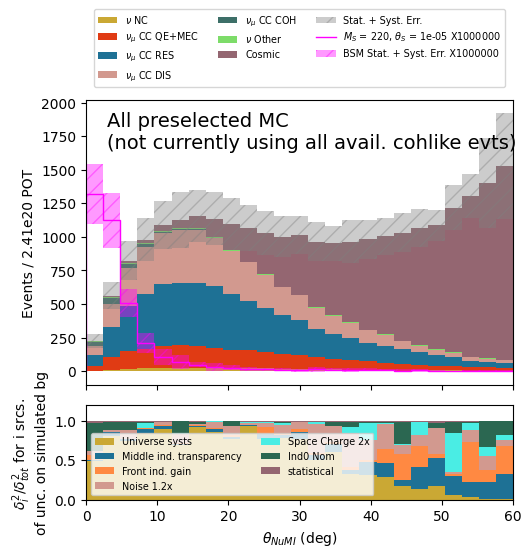

Total number of (POT-normalized) simulated background events in plot: '2.58e+04'
Total uncertainty on simulated background events in plot: ±'4.23e+03'
Total number of (POT-normalized) simulated signal events in plot: '0.00356'
Total uncertainty on simulated signal events in plot: ±'0.000935'


In [66]:
bsm_detector_varis_vars = []
for bsm_sample in bsm_detector_varis_dfs:
    this_samples_vars = []
    for detect_variation_df in bsm_sample:
        this_samples_vars.append(detect_variation_df.Snumi_angle_wgtByLen*180./math.pi)
    bsm_detector_varis_vars.append(this_samples_vars)
        
makeplot(evtdf, evtdf.Snumi_angle_wgtByLen*180./math.pi,
         mccoh_syst_evtdfs, [sdf.Snumi_angle_wgtByLen*180./math.pi for sdf in mccoh_syst_evtdfs],
         (0,60.), xlabel = "$\\theta_{NuMI}$ (deg)", detailed_nu="int_type",
         ratio_bounds=[0.,2.], plotname='theta_NuMI',
         textOnPlot = 'All preselected MC \n(not currently using all avail. cohlike evts)',
         bsm_index=0,
         bsm_detector_varis_vars=bsm_detector_varis_vars,
         bsm_magnifier = 1000000
        )

VERIFY THAT THIS NUMBER IS TWO (1 cohlike sample + 1 nominal sample, for two different POT scalings):  2


UnboundLocalError: local variable 'middle_ind_cov' referenced before assignment

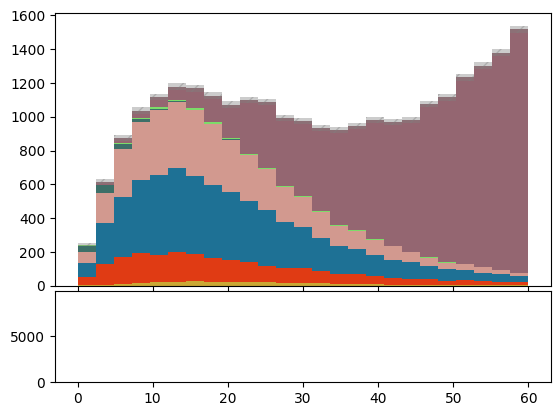

In [22]:
makeplot(evtdf, evtdf.Snumi_angle_mcs*180./math.pi,
         mccoh_syst_evtdfs, [sdf.Snumi_angle_mcs*180./math.pi for sdf in mccoh_syst_evtdfs],
         (0,60.), xlabel = "MCS $\\theta_{NuMI}$ (deg)", detailed_nu="int_type",
         ratio_bounds=[0.,2.], plotname='theta_NuMI', 
         textOnPlot = 'All preselected MC \n(not currently using all avail. cohlike evts)',
        do_systs=False)

In [ ]:
# TODO: bottom panel: show uncert. squared (then I can show breakdown of contributing types.)
# To get model systematics: 

# what's my goal? Make a plot that shows:
# DONE - neutrinos, stacked by type, with total uncertainty
# - bsm benchmark(s) that are given (single or a list), plotted as line hist, with total uncertainty
# - (to be added later: ) data as data points, with statistical error
# - bottom panel shows breakdown of fractional uncertainty for each type of uncertainty, in each bin, as stacked hist.

# plot inputs:
# - nu_evtdf (concatenated from nominal nu df and cohlike dfs)
# - cohlike_evtdfs
# - bsm_df (one df per benchmark mass you want to plot)
# - list of sets (list of lists) of bsm detector variations 